# Lymphoid

In [14]:
import scanpy as sc
adata = sc.read_h5ad('/home/Data_Drive_8TB_2/CRC_2026/KRAS_project/4.h5ad/CRC_36_rm_doublet_global_Tsubtype_annotated_260601.h5ad')

In [7]:
list(adata.obs['cell_type'].unique())

['Plasma',
 'Tumor/Epithelial',
 'Mesenchymal',
 'Endothelial',
 'Monocyte/Macrophage/DC',
 'T',
 'B',
 'Glial',
 'Neutrophil',
 'Mast']

In [15]:
adata

AnnData object with n_obs × n_vars = 138686 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'is_doublet', 'logit_scores', 'softmax_scores', 'sample', 'is_doublet_plot', 'leiden', 'leiden_unintegrated_2', 'softmax_score_stage', 'majority_voting', 'majority_voting_large', 'leiden_subcluster_merged', 'cell_type', 'T_subtype_large', 'T_NK_substate', 'T_NK_major_state', 'sample_base', 'Sex', 'Age', 'Tumor location', 'Stage', 'TN Stage', 'Histology', 'Differentiation', 'MSI', 'APC', 'TP53', 'KRAS', 'NRAS', 'BRAF', 'PIK3CA', 'TMB (/Mb)'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'T_NK_major_state_colors', 'T_subtype_large_colors', '_s

In [18]:
list(adata.obs['NRAS'].unique())

['-', 'p.G12D', nan]

In [22]:
list(adata.obs['sample'].unique())

['H1',
 'H11',
 'H12',
 'H13',
 'H14',
 'H15',
 'H16',
 'H17',
 'H18',
 'H19',
 'H2',
 'H20',
 'H21',
 'H22',
 'H23',
 'H24',
 'H25',
 'H26',
 'H27',
 'H28',
 'H29N',
 'H29T',
 'H3',
 'H30N',
 'H30T',
 'H31N',
 'H31T',
 'H32N',
 'H32T',
 'H33N',
 'H33T',
 'H34N',
 'H34T',
 'H35N',
 'H35T',
 'H36N',
 'H36T',
 'H37N',
 'H37T',
 'H4',
 'H5',
 'H6',
 'H7',
 'H8',
 'H9']

In [167]:
import numpy as np

sample = adata.obs["sample"].astype(str)
tp53_raw = adata.obs["TP53"].astype(str)

adata.obs["TP53_mutation"] = np.where(
    sample.str.contains("N", na=False),
    "Normal",
    np.where(
        tp53_raw == "-",
        "TP53 WT",
        "TP53 Mutation"
    )
)

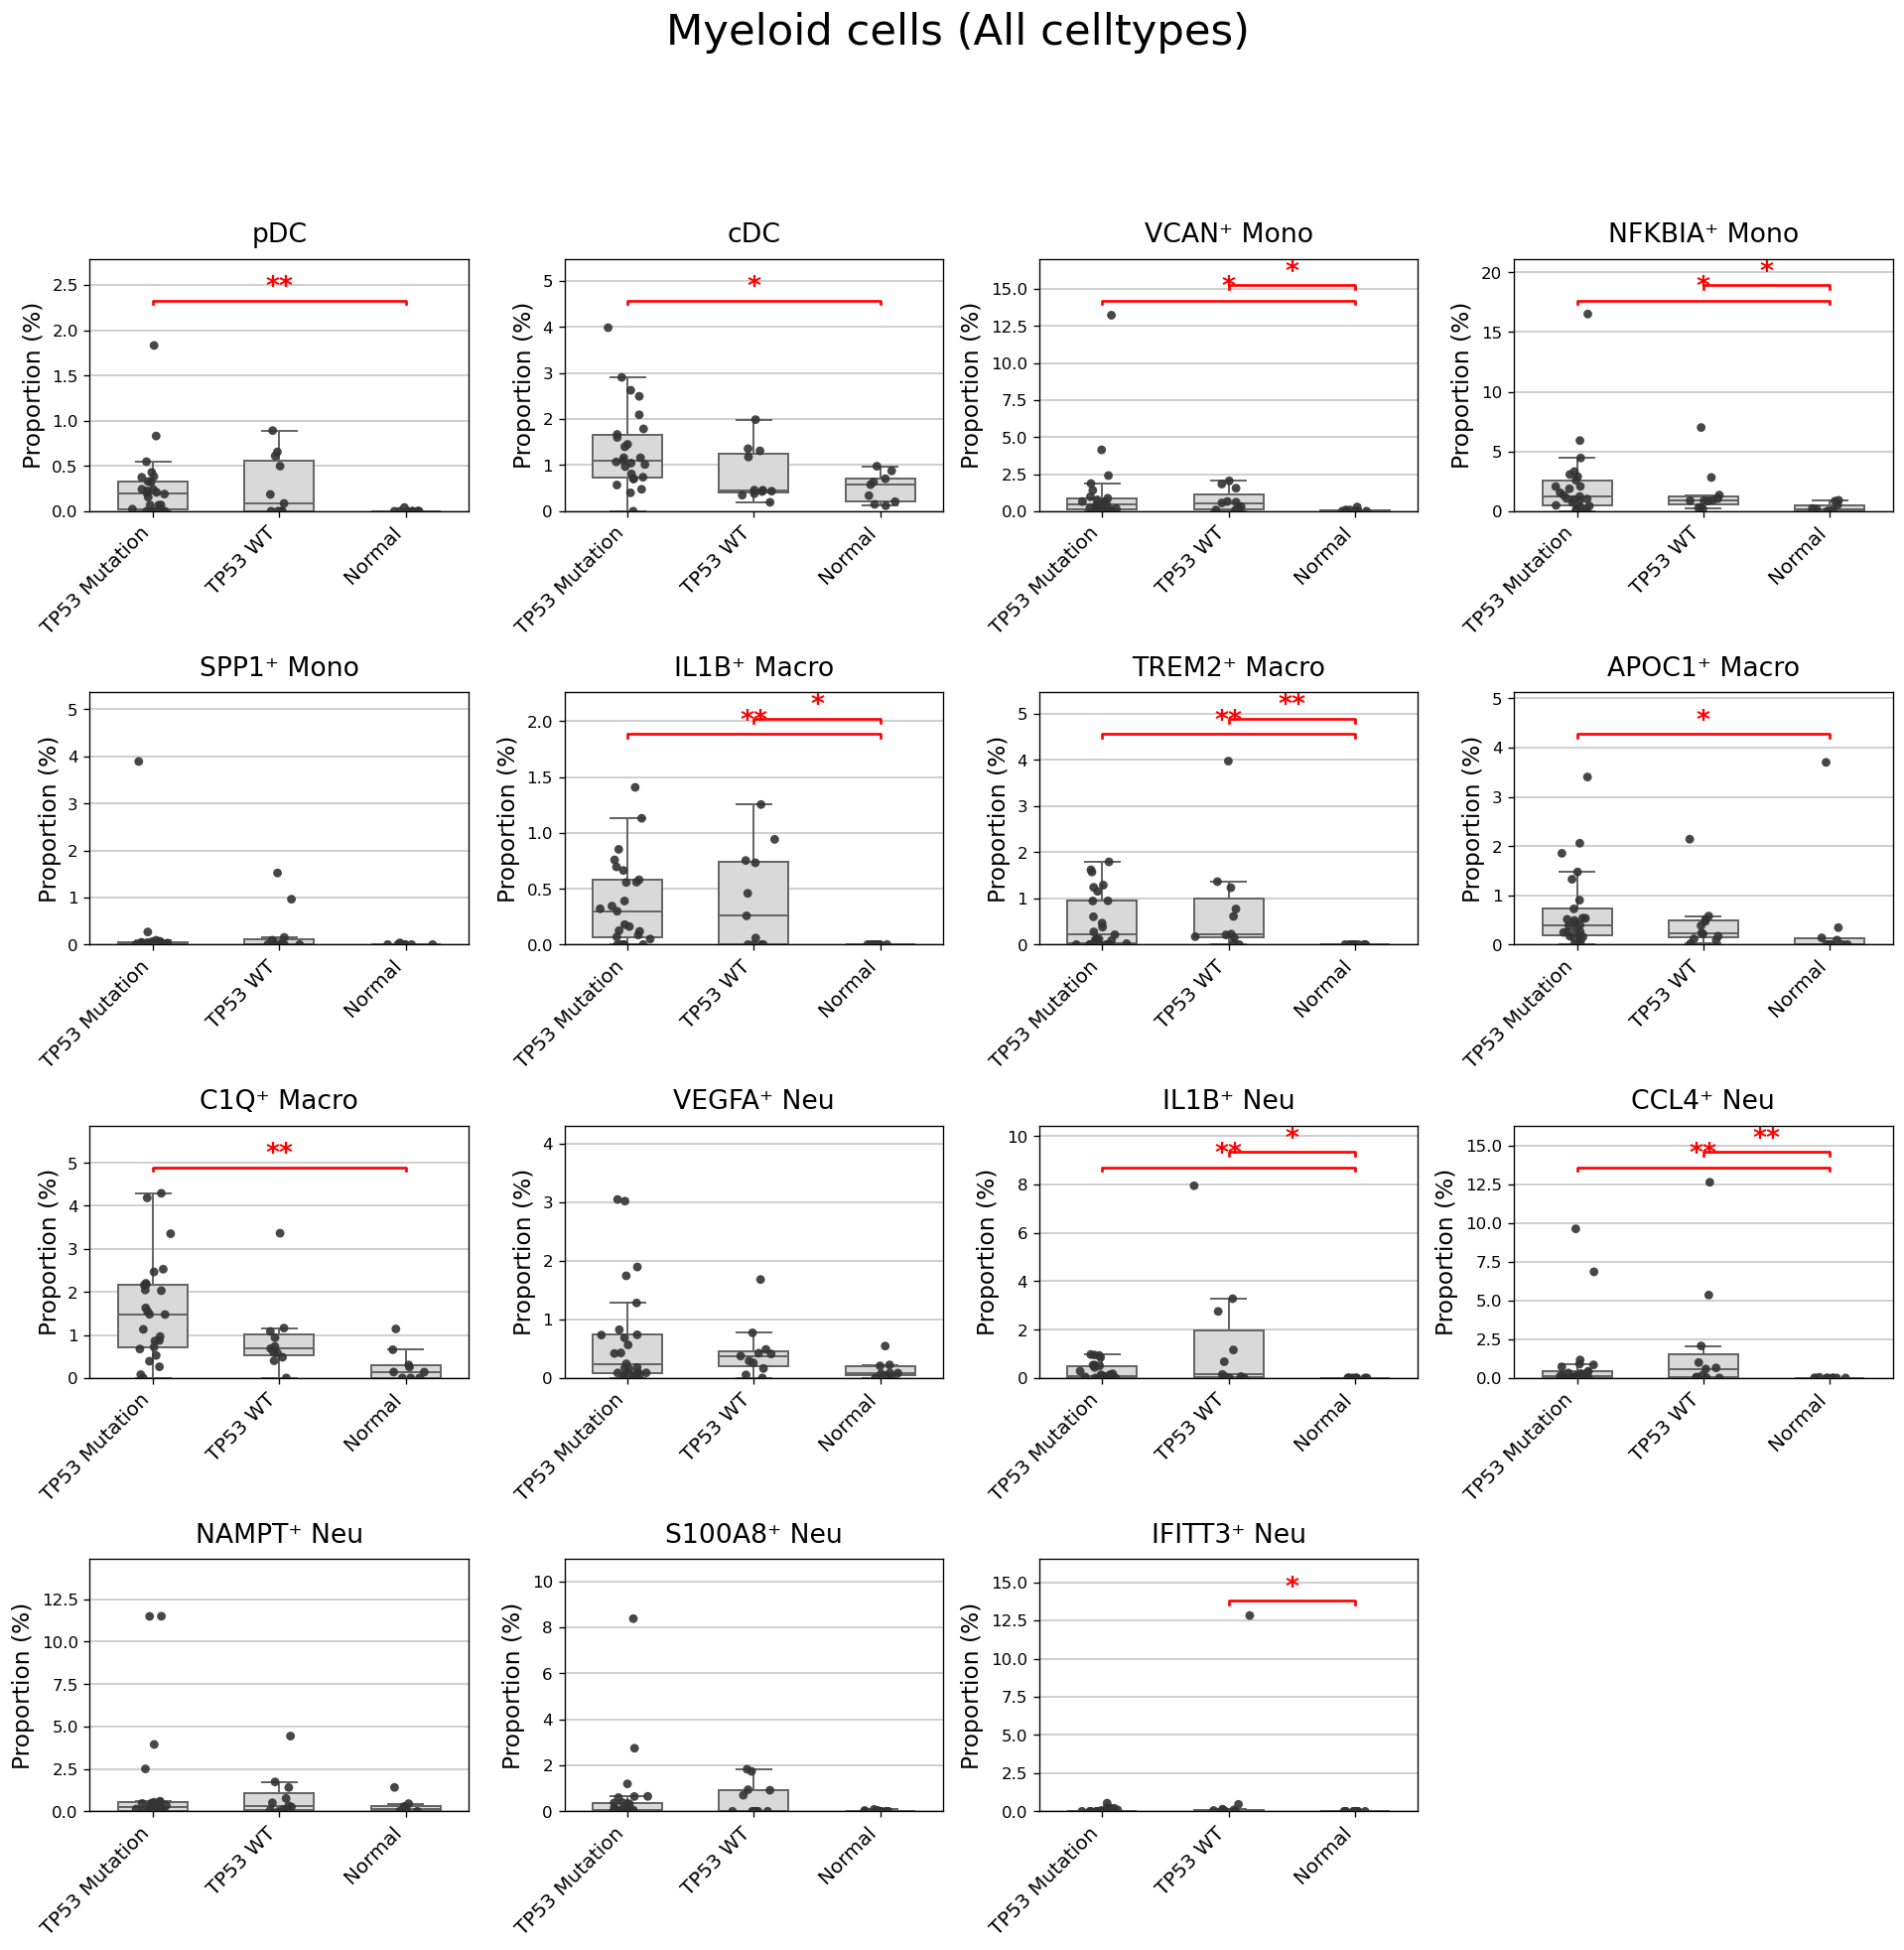

In [168]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

sample_col  = "sample"
group_col   = "TP53_mutation"
subtype_col = "Total celltype"

target_subtypes = ['pDC', 'cDC',
 'VCAN⁺ Mono', 'NFKBIA⁺ Mono','SPP1⁺ Mono', 
 'IL1B⁺ Macro', 'TREM2⁺ Macro','APOC1⁺ Macro', 'C1Q⁺ Macro',
 'VEGFA⁺ Neu', 'IL1B⁺ Neu','CCL4⁺ Neu','NAMPT⁺ Neu','S100A8⁺ Neu','IFITT3⁺ Neu']

group_order = ["TP53 Mutation", "TP53 WT", "Normal"]
show_only_sig = True

SUBPLOT_W = 4
SUBPLOT_H = 4
DPI = 120

FS_SUPTITLE = 26
FS_TITLE    = 16
FS_LABEL    = 14
FS_TICK     = 12
FS_STAR     = 16

def bh_adjust(pvals):
    pvals = np.array(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adj, 0, 1)
    return out.tolist()

def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, y, h, text, color="red", lw=1.6, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=color)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom",
            color=color, fontsize=fs, fontweight="bold")

obs = adata.obs[[sample_col, group_col, subtype_col]].copy()
ct = (
    obs.groupby([sample_col, group_col, subtype_col], observed=True)
       .size()
       .unstack(fill_value=0)
)

ct_target = ct.reindex(columns=target_subtypes, fill_value=0)
denom_all = obs.groupby([sample_col, group_col], observed=True).size()
prop = ct_target.div(denom_all, axis=0) * 100
prop = prop.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

df = (
    prop.reset_index()
        .melt(
            id_vars=[sample_col, group_col],
            var_name="CD8_target_subtype",
            value_name="percent"
        )
)

df["percent"] = df["percent"].astype(float)
group_order = [g for g in group_order if g in df[group_col].unique()]

subtypes = target_subtypes
n_sub = len(subtypes)

ncols = min(4, n_sub)
nrows = math.ceil(n_sub / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(SUBPLOT_W * ncols, SUBPLOT_H * nrows),
    dpi=DPI,
    squeeze=False
)

rng = np.random.default_rng(0)

_global_pvals = []
_global_keys = []
_stats_cache = {}

for idx, subtype in enumerate(subtypes):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]

    d = df[df["CD8_target_subtype"] == subtype].copy()
    groups = [d.loc[d[group_col] == g, "percent"].dropna().values for g in group_order]
    positions = np.arange(1, len(group_order) + 1)

    bp = ax.boxplot(
        groups, positions=positions, widths=0.55,
        showfliers=False, patch_artist=True
    )
    for box in bp["boxes"]:
        box.set_facecolor("#d9d9d9")
        box.set_edgecolor("#666666")
        box.set_linewidth(1.2)
    for k in ["whiskers", "caps", "medians"]:
        for item in bp[k]:
            item.set_color("#666666")
            item.set_linewidth(1.2)

    for i, vals in enumerate(groups, start=1):
        x = rng.normal(loc=i, scale=0.07, size=len(vals))
        ax.scatter(x, vals, s=28, alpha=0.9, color="0.2",
                   edgecolors="none", zorder=3)

    ax.set_title(subtype, fontsize=FS_TITLE, pad=10, loc="center")
    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, rotation=45, ha="right", fontsize=FS_TICK)
    ax.set_ylabel("Proportion (%)", fontsize=FS_LABEL)

    ax.yaxis.grid(True, color="#c7c7c7", linewidth=1.0)
    ax.xaxis.grid(False)

    all_vals = np.concatenate([v for v in groups if len(v) > 0]) if any(len(v)>0 for v in groups) else np.array([0.0])
    y_max = float(np.nanmax(all_vals)) if np.isfinite(np.nanmax(all_vals)) else 0.0
    ax.set_ylim(0, max(1.0, y_max * 1.25 + 0.5))

    pairs = [(a, b) for a in range(len(group_order)) for b in range(a+1, len(group_order))]

    raw_p, ok_mask = [], []
    for a, b in pairs:
        A, B = groups[a], groups[b]
        A = A[np.isfinite(A)]
        B = B[np.isfinite(B)]
        if len(A) < 2 or len(B) < 2:
            raw_p.append(np.nan); ok_mask.append(False)
        else:
            p = stats.mannwhitneyu(A, B, alternative="two-sided").pvalue
            raw_p.append(p); ok_mask.append(True)

    _stats_cache[subtype] = {"ax": ax, "pairs": pairs, "raw_p": raw_p, "ok_mask": ok_mask}
    for pi, p in enumerate(raw_p):
        if np.isfinite(p) and ok_mask[pi]:
            _global_pvals.append(float(p))
            _global_keys.append((subtype, pi))

_global_adj_map = {}
if len(_global_pvals) > 0:
    _global_adj = bh_adjust(_global_pvals)
    _global_adj_map = {k: _global_adj[i] for i, k in enumerate(_global_keys)}

for subtype in subtypes:
    ax = _stats_cache[subtype]["ax"]
    pairs = _stats_cache[subtype]["pairs"]
    raw_p = _stats_cache[subtype]["raw_p"]
    ok_mask = _stats_cache[subtype]["ok_mask"]

    base = ax.get_ylim()[1] * 0.82
    step = ax.get_ylim()[1] * 0.06
    bar_i = 0

    for pi, (a, b) in enumerate(pairs):
        if not ok_mask[pi]:
            continue

        p_adj = _global_adj_map.get((subtype, pi), np.nan)
        star = p_to_star(p_adj)
        if show_only_sig and star == "ns":
            continue

        y = base + bar_i * step
        add_sig_bar(ax, a+1, b+1, y=y, h=step*0.25, text=star, color="red", fs=FS_STAR)
        bar_i += 1

for j in range(n_sub, nrows * ncols):
    rr, cc = divmod(j, ncols)
    fig.delaxes(axes[rr][cc])

fig.suptitle("Myeloid cells (All celltypes)", fontsize=FS_SUPTITLE,
             x=0.5, ha="center", y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [169]:
selected = ['Myeloid', 'NK/T', 'Neutrophil']

adata = adata[adata.obs['cell_type'].isin(selected)].copy()

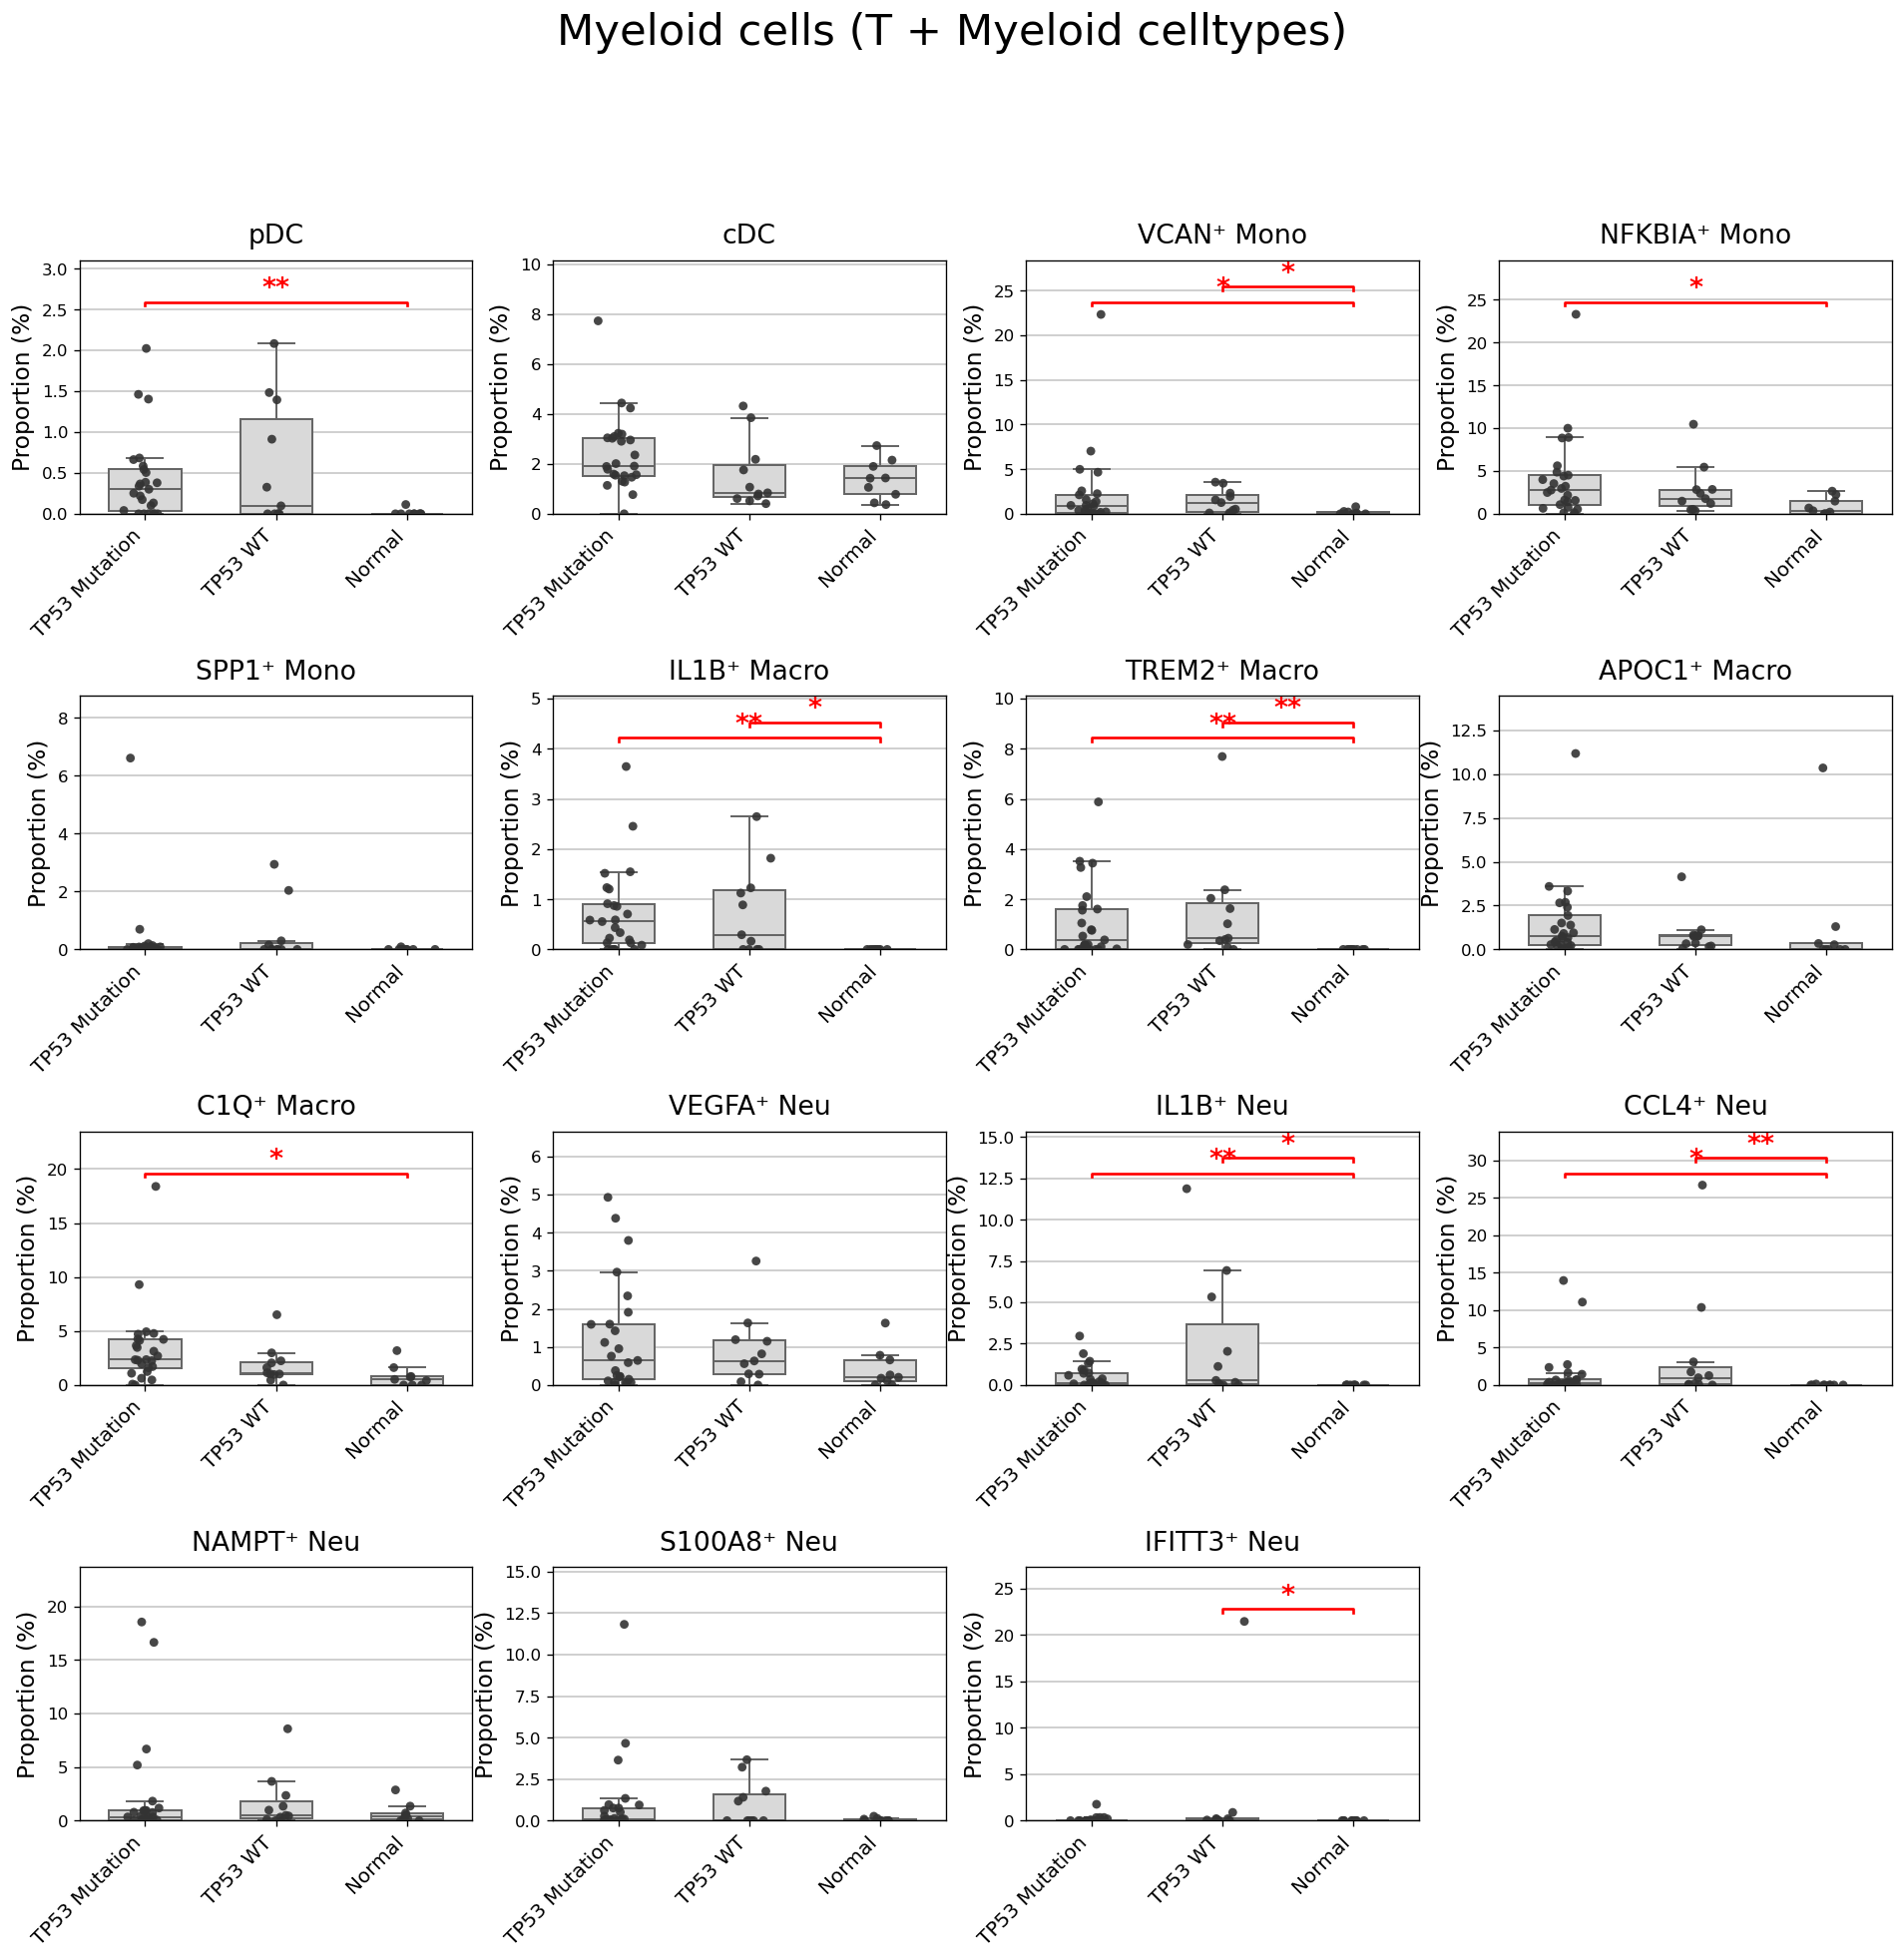

In [170]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

sample_col  = "sample"
group_col   = "TP53_mutation"
subtype_col = "Total celltype"

target_subtypes = ['pDC', 'cDC',
 'VCAN⁺ Mono', 'NFKBIA⁺ Mono','SPP1⁺ Mono', 
 'IL1B⁺ Macro', 'TREM2⁺ Macro','APOC1⁺ Macro', 'C1Q⁺ Macro',
 'VEGFA⁺ Neu', 'IL1B⁺ Neu','CCL4⁺ Neu','NAMPT⁺ Neu','S100A8⁺ Neu','IFITT3⁺ Neu']

group_order = ["TP53 Mutation", "TP53 WT", "Normal"]
show_only_sig = True

SUBPLOT_W = 4
SUBPLOT_H = 4
DPI = 120

FS_SUPTITLE = 26
FS_TITLE    = 16
FS_LABEL    = 14
FS_TICK     = 12
FS_STAR     = 16

def bh_adjust(pvals):
    pvals = np.array(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adj, 0, 1)
    return out.tolist()

def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, y, h, text, color="red", lw=1.6, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=color)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom",
            color=color, fontsize=fs, fontweight="bold")

obs = adata.obs[[sample_col, group_col, subtype_col]].copy()
ct = (
    obs.groupby([sample_col, group_col, subtype_col], observed=True)
       .size()
       .unstack(fill_value=0)
)

ct_target = ct.reindex(columns=target_subtypes, fill_value=0)
denom_all = obs.groupby([sample_col, group_col], observed=True).size()
prop = ct_target.div(denom_all, axis=0) * 100
prop = prop.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

df = (
    prop.reset_index()
        .melt(
            id_vars=[sample_col, group_col],
            var_name="CD8_target_subtype",
            value_name="percent"
        )
)

df["percent"] = df["percent"].astype(float)
group_order = [g for g in group_order if g in df[group_col].unique()]

subtypes = target_subtypes
n_sub = len(subtypes)

ncols = min(4, n_sub)
nrows = math.ceil(n_sub / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(SUBPLOT_W * ncols, SUBPLOT_H * nrows),
    dpi=DPI,
    squeeze=False
)

rng = np.random.default_rng(0)

_global_pvals = []
_global_keys = []
_stats_cache = {}

for idx, subtype in enumerate(subtypes):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]

    d = df[df["CD8_target_subtype"] == subtype].copy()
    groups = [d.loc[d[group_col] == g, "percent"].dropna().values for g in group_order]
    positions = np.arange(1, len(group_order) + 1)

    bp = ax.boxplot(
        groups, positions=positions, widths=0.55,
        showfliers=False, patch_artist=True
    )
    for box in bp["boxes"]:
        box.set_facecolor("#d9d9d9")
        box.set_edgecolor("#666666")
        box.set_linewidth(1.2)
    for k in ["whiskers", "caps", "medians"]:
        for item in bp[k]:
            item.set_color("#666666")
            item.set_linewidth(1.2)

    for i, vals in enumerate(groups, start=1):
        x = rng.normal(loc=i, scale=0.07, size=len(vals))
        ax.scatter(x, vals, s=28, alpha=0.9, color="0.2",
                   edgecolors="none", zorder=3)

    ax.set_title(subtype, fontsize=FS_TITLE, pad=10, loc="center")
    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, rotation=45, ha="right", fontsize=FS_TICK)
    ax.set_ylabel("Proportion (%)", fontsize=FS_LABEL)

    ax.yaxis.grid(True, color="#c7c7c7", linewidth=1.0)
    ax.xaxis.grid(False)

    all_vals = np.concatenate([v for v in groups if len(v) > 0]) if any(len(v)>0 for v in groups) else np.array([0.0])
    y_max = float(np.nanmax(all_vals)) if np.isfinite(np.nanmax(all_vals)) else 0.0
    ax.set_ylim(0, max(1.0, y_max * 1.25 + 0.5))

    pairs = [(a, b) for a in range(len(group_order)) for b in range(a+1, len(group_order))]

    raw_p, ok_mask = [], []
    for a, b in pairs:
        A, B = groups[a], groups[b]
        A = A[np.isfinite(A)]
        B = B[np.isfinite(B)]
        if len(A) < 2 or len(B) < 2:
            raw_p.append(np.nan); ok_mask.append(False)
        else:
            p = stats.mannwhitneyu(A, B, alternative="two-sided").pvalue
            raw_p.append(p); ok_mask.append(True)

    _stats_cache[subtype] = {"ax": ax, "pairs": pairs, "raw_p": raw_p, "ok_mask": ok_mask}
    for pi, p in enumerate(raw_p):
        if np.isfinite(p) and ok_mask[pi]:
            _global_pvals.append(float(p))
            _global_keys.append((subtype, pi))

_global_adj_map = {}
if len(_global_pvals) > 0:
    _global_adj = bh_adjust(_global_pvals)
    _global_adj_map = {k: _global_adj[i] for i, k in enumerate(_global_keys)}

for subtype in subtypes:
    ax = _stats_cache[subtype]["ax"]
    pairs = _stats_cache[subtype]["pairs"]
    raw_p = _stats_cache[subtype]["raw_p"]
    ok_mask = _stats_cache[subtype]["ok_mask"]

    base = ax.get_ylim()[1] * 0.82
    step = ax.get_ylim()[1] * 0.06
    bar_i = 0

    for pi, (a, b) in enumerate(pairs):
        if not ok_mask[pi]:
            continue

        p_adj = _global_adj_map.get((subtype, pi), np.nan)
        star = p_to_star(p_adj)
        if show_only_sig and star == "ns":
            continue

        y = base + bar_i * step
        add_sig_bar(ax, a+1, b+1, y=y, h=step*0.25, text=star, color="red", fs=FS_STAR)
        bar_i += 1

for j in range(n_sub, nrows * ncols):
    rr, cc = divmod(j, ncols)
    fig.delaxes(axes[rr][cc])

fig.suptitle("Myeloid cells (T + Myeloid celltypes)", fontsize=FS_SUPTITLE,
             x=0.5, ha="center", y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [171]:
selected = ['Myeloid','Neutrophil']

adata = adata[adata.obs['cell_type'].isin(selected)].copy()

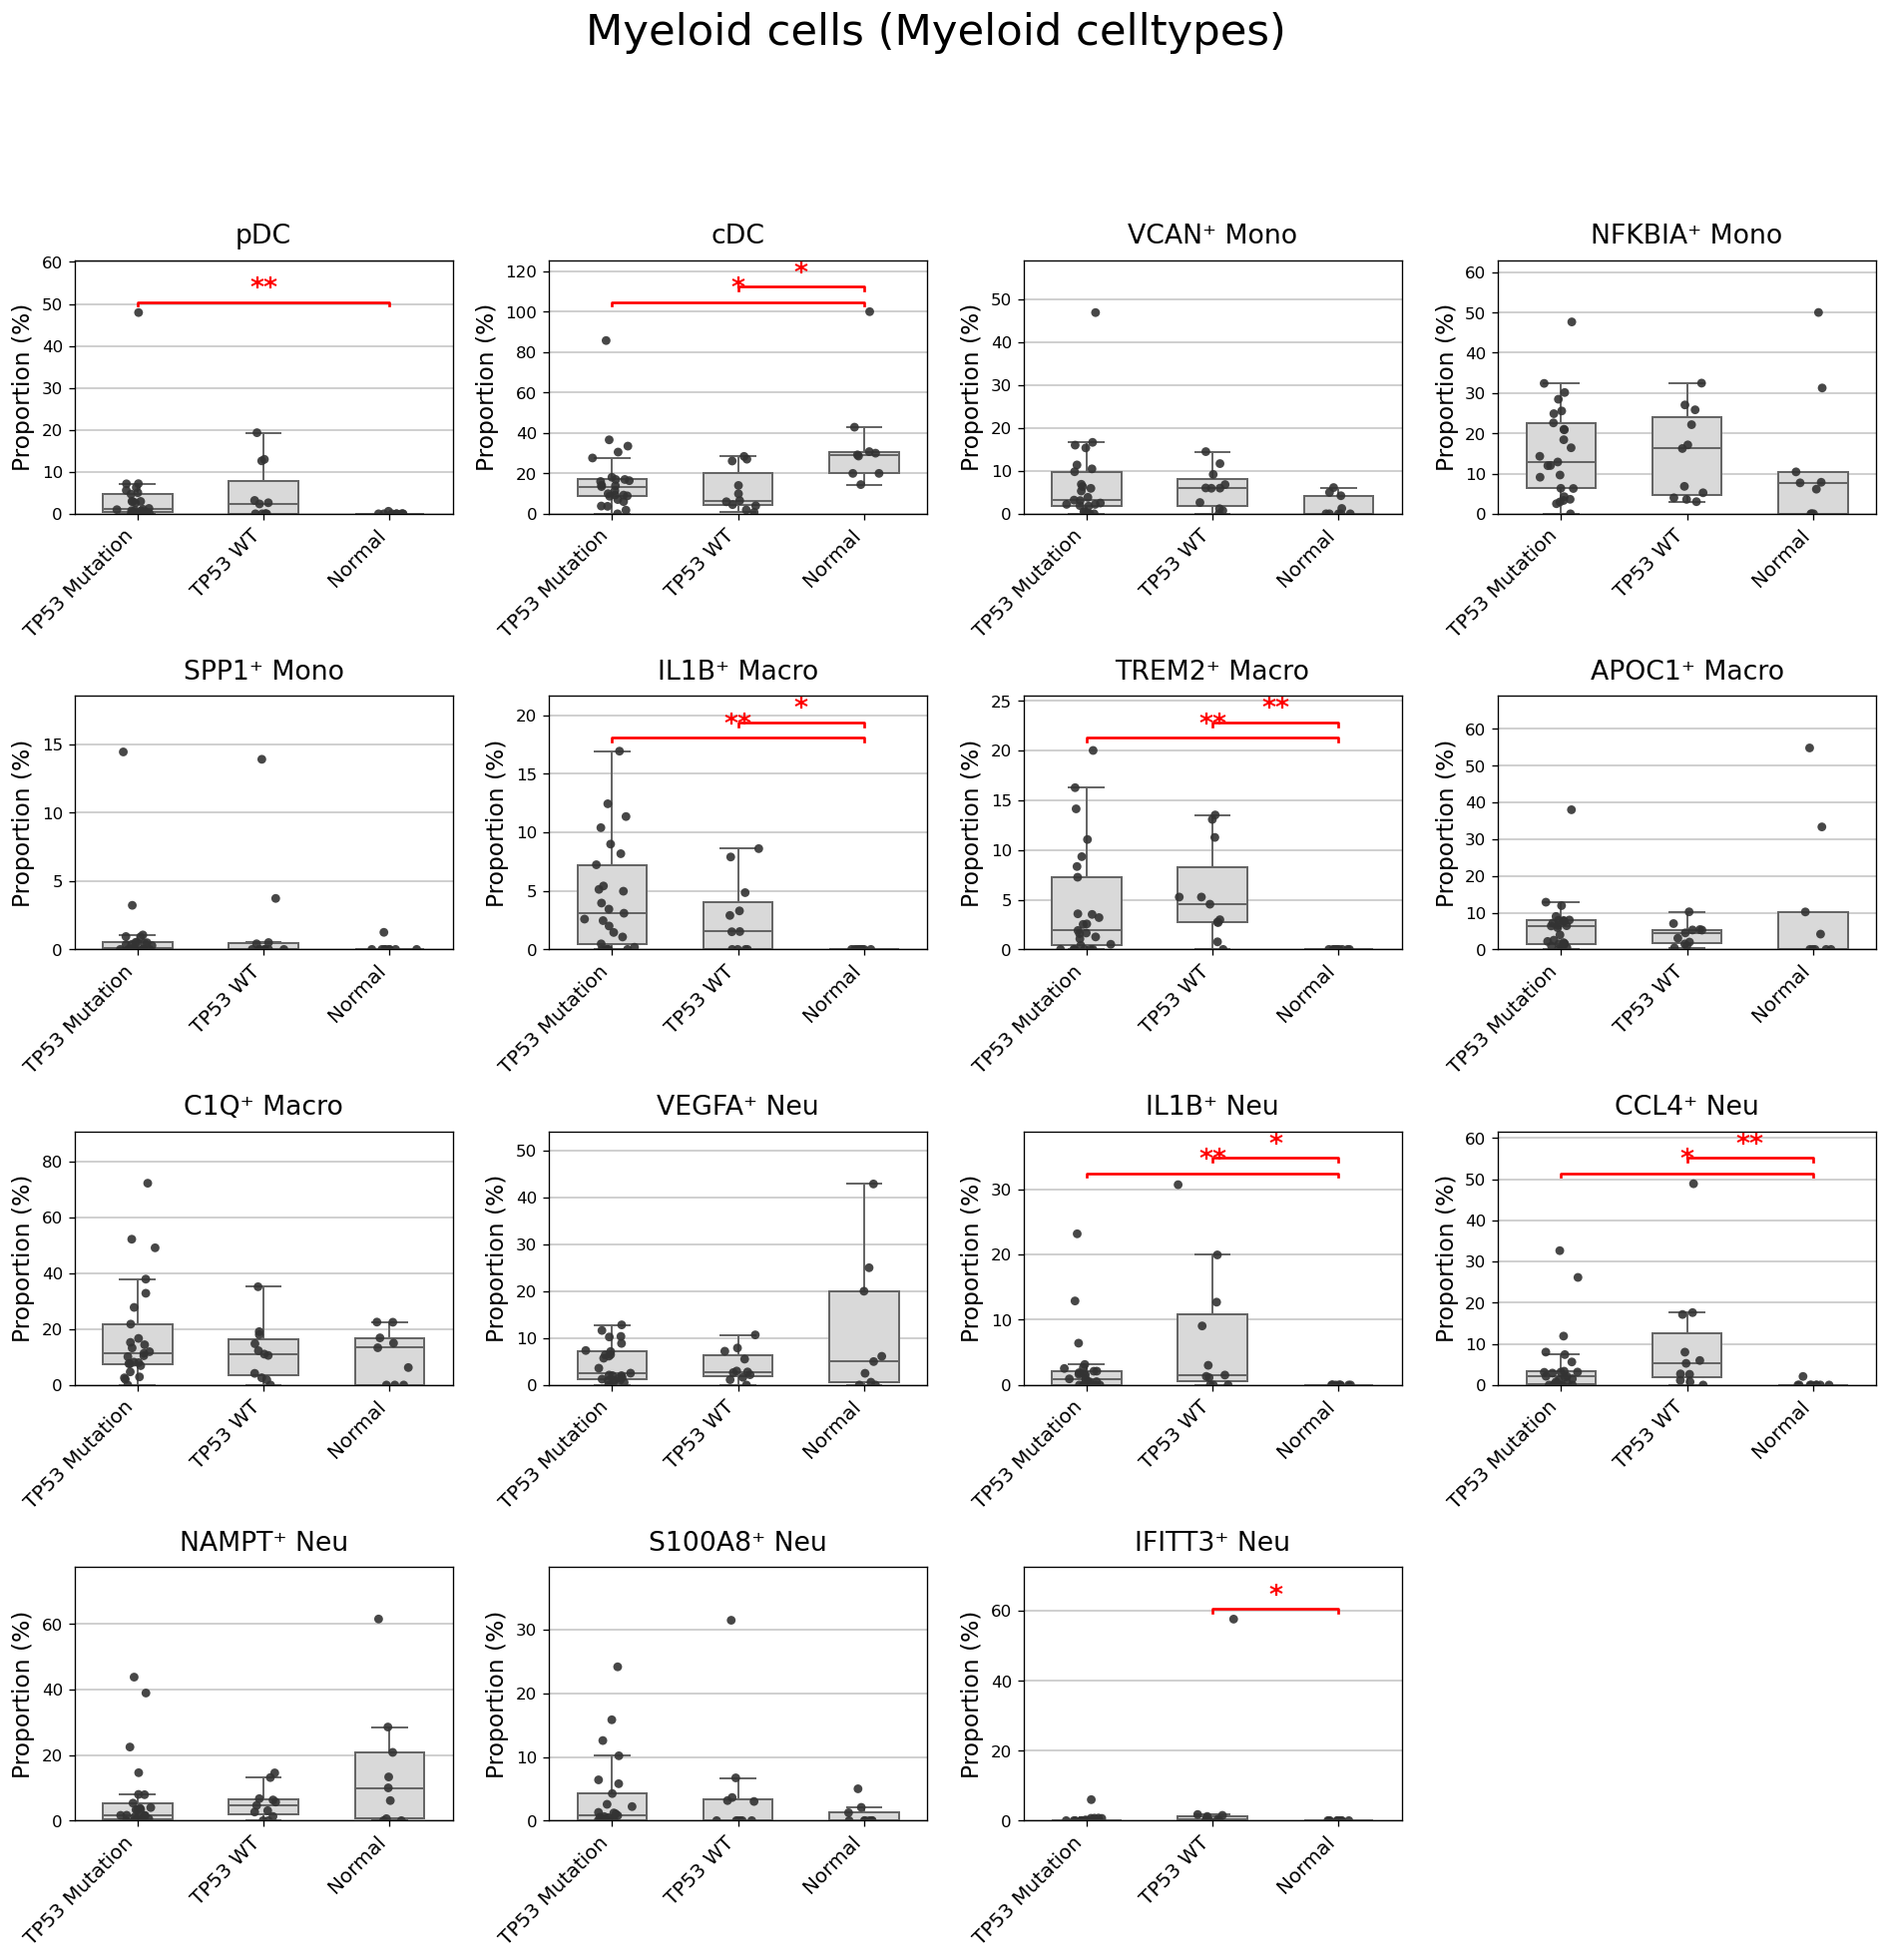

In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

sample_col  = "sample"
group_col   = "TP53_mutation"
subtype_col = "Total celltype"

target_subtypes = ['pDC', 'cDC',
 'VCAN⁺ Mono', 'NFKBIA⁺ Mono','SPP1⁺ Mono', 
 'IL1B⁺ Macro', 'TREM2⁺ Macro','APOC1⁺ Macro', 'C1Q⁺ Macro',
 'VEGFA⁺ Neu', 'IL1B⁺ Neu','CCL4⁺ Neu','NAMPT⁺ Neu','S100A8⁺ Neu','IFITT3⁺ Neu']

group_order = ["TP53 Mutation", "TP53 WT", "Normal"]
show_only_sig = True

SUBPLOT_W = 4
SUBPLOT_H = 4
DPI = 120

FS_SUPTITLE = 26
FS_TITLE    = 16
FS_LABEL    = 14
FS_TICK     = 12
FS_STAR     = 16

def bh_adjust(pvals):
    pvals = np.array(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adj, 0, 1)
    return out.tolist()

def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, y, h, text, color="red", lw=1.6, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=color)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom",
            color=color, fontsize=fs, fontweight="bold")

obs = adata.obs[[sample_col, group_col, subtype_col]].copy()
ct = (
    obs.groupby([sample_col, group_col, subtype_col], observed=True)
       .size()
       .unstack(fill_value=0)
)

ct_target = ct.reindex(columns=target_subtypes, fill_value=0)
denom_all = obs.groupby([sample_col, group_col], observed=True).size()
prop = ct_target.div(denom_all, axis=0) * 100
prop = prop.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

df = (
    prop.reset_index()
        .melt(
            id_vars=[sample_col, group_col],
            var_name="CD8_target_subtype",
            value_name="percent"
        )
)

df["percent"] = df["percent"].astype(float)
group_order = [g for g in group_order if g in df[group_col].unique()]

subtypes = target_subtypes
n_sub = len(subtypes)

ncols = min(4, n_sub)
nrows = math.ceil(n_sub / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(SUBPLOT_W * ncols, SUBPLOT_H * nrows),
    dpi=DPI,
    squeeze=False
)

rng = np.random.default_rng(0)

_global_pvals = []
_global_keys = []
_stats_cache = {}

for idx, subtype in enumerate(subtypes):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]

    d = df[df["CD8_target_subtype"] == subtype].copy()
    groups = [d.loc[d[group_col] == g, "percent"].dropna().values for g in group_order]
    positions = np.arange(1, len(group_order) + 1)

    bp = ax.boxplot(
        groups, positions=positions, widths=0.55,
        showfliers=False, patch_artist=True
    )
    for box in bp["boxes"]:
        box.set_facecolor("#d9d9d9")
        box.set_edgecolor("#666666")
        box.set_linewidth(1.2)
    for k in ["whiskers", "caps", "medians"]:
        for item in bp[k]:
            item.set_color("#666666")
            item.set_linewidth(1.2)

    for i, vals in enumerate(groups, start=1):
        x = rng.normal(loc=i, scale=0.07, size=len(vals))
        ax.scatter(x, vals, s=28, alpha=0.9, color="0.2",
                   edgecolors="none", zorder=3)

    ax.set_title(subtype, fontsize=FS_TITLE, pad=10, loc="center")
    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, rotation=45, ha="right", fontsize=FS_TICK)
    ax.set_ylabel("Proportion (%)", fontsize=FS_LABEL)

    ax.yaxis.grid(True, color="#c7c7c7", linewidth=1.0)
    ax.xaxis.grid(False)

    all_vals = np.concatenate([v for v in groups if len(v) > 0]) if any(len(v)>0 for v in groups) else np.array([0.0])
    y_max = float(np.nanmax(all_vals)) if np.isfinite(np.nanmax(all_vals)) else 0.0
    ax.set_ylim(0, max(1.0, y_max * 1.25 + 0.5))

    pairs = [(a, b) for a in range(len(group_order)) for b in range(a+1, len(group_order))]

    raw_p, ok_mask = [], []
    for a, b in pairs:
        A, B = groups[a], groups[b]
        A = A[np.isfinite(A)]
        B = B[np.isfinite(B)]
        if len(A) < 2 or len(B) < 2:
            raw_p.append(np.nan); ok_mask.append(False)
        else:
            p = stats.mannwhitneyu(A, B, alternative="two-sided").pvalue
            raw_p.append(p); ok_mask.append(True)

    _stats_cache[subtype] = {"ax": ax, "pairs": pairs, "raw_p": raw_p, "ok_mask": ok_mask}
    for pi, p in enumerate(raw_p):
        if np.isfinite(p) and ok_mask[pi]:
            _global_pvals.append(float(p))
            _global_keys.append((subtype, pi))

_global_adj_map = {}
if len(_global_pvals) > 0:
    _global_adj = bh_adjust(_global_pvals)
    _global_adj_map = {k: _global_adj[i] for i, k in enumerate(_global_keys)}

for subtype in subtypes:
    ax = _stats_cache[subtype]["ax"]
    pairs = _stats_cache[subtype]["pairs"]
    raw_p = _stats_cache[subtype]["raw_p"]
    ok_mask = _stats_cache[subtype]["ok_mask"]

    base = ax.get_ylim()[1] * 0.82
    step = ax.get_ylim()[1] * 0.06
    bar_i = 0

    for pi, (a, b) in enumerate(pairs):
        if not ok_mask[pi]:
            continue

        p_adj = _global_adj_map.get((subtype, pi), np.nan)
        star = p_to_star(p_adj)
        if show_only_sig and star == "ns":
            continue

        y = base + bar_i * step
        add_sig_bar(ax, a+1, b+1, y=y, h=step*0.25, text=star, color="red", fs=FS_STAR)
        bar_i += 1

for j in range(n_sub, nrows * ncols):
    rr, cc = divmod(j, ncols)
    fig.delaxes(axes[rr][cc])

fig.suptitle("Myeloid cells (Myeloid celltypes)", fontsize=FS_SUPTITLE,
             x=0.5, ha="center", y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [173]:
selected1 = ['Myeloid']
selected2 = ['Neutrophil']
selected3 = ['pDC','cDC']

adata1 = adata[adata.obs['cell_type'].isin(selected1)].copy()
adata2 = adata[adata.obs['cell_type'].isin(selected2)].copy()
adata3 = adata[adata.obs['Total celltype'].isin(selected3)].copy()

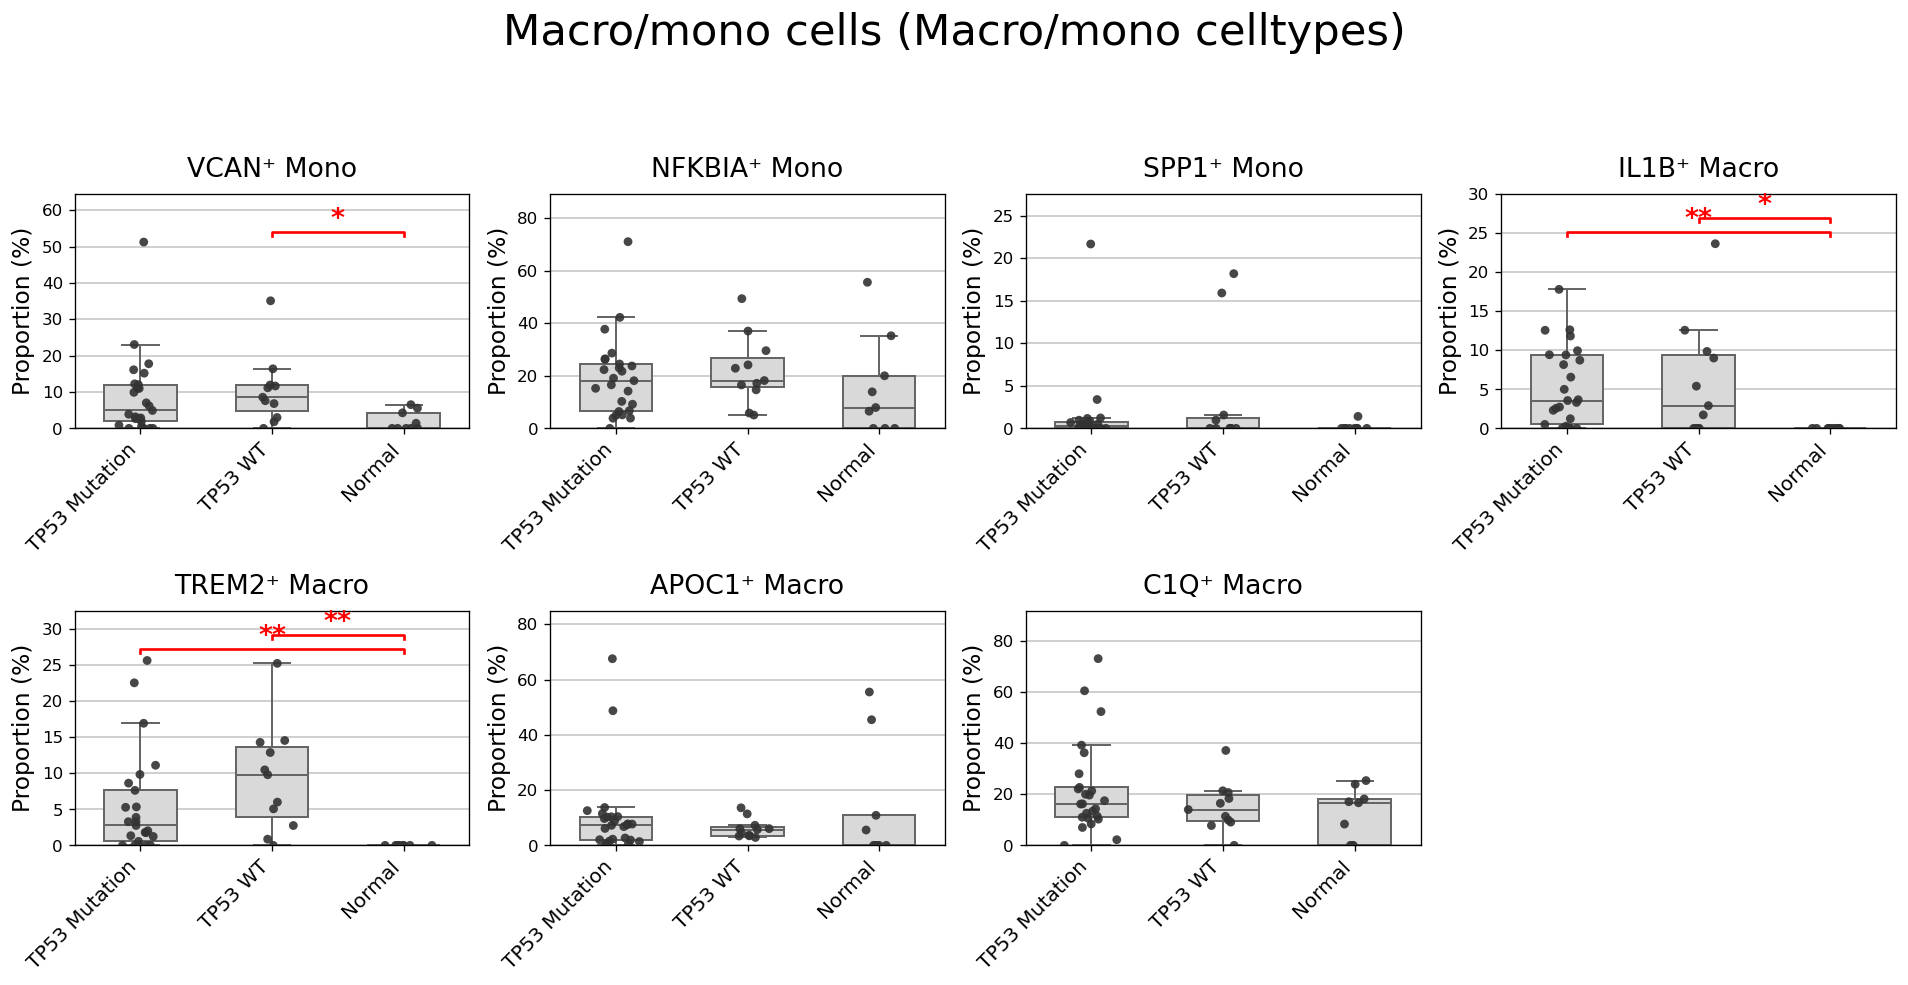

In [174]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

sample_col  = "sample"
group_col   = "TP53_mutation"
subtype_col = "Total celltype"

target_subtypes = [
 'VCAN⁺ Mono', 'NFKBIA⁺ Mono','SPP1⁺ Mono', 
 'IL1B⁺ Macro', 'TREM2⁺ Macro','APOC1⁺ Macro', 'C1Q⁺ Macro']

group_order = ["TP53 Mutation", "TP53 WT", "Normal"]
show_only_sig = True

SUBPLOT_W = 4
SUBPLOT_H = 4
DPI = 120

FS_SUPTITLE = 26
FS_TITLE    = 16
FS_LABEL    = 14
FS_TICK     = 12
FS_STAR     = 16

def bh_adjust(pvals):
    pvals = np.array(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adj, 0, 1)
    return out.tolist()

def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, y, h, text, color="red", lw=1.6, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=color)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom",
            color=color, fontsize=fs, fontweight="bold")

obs = adata1.obs[[sample_col, group_col, subtype_col]].copy()
ct = (
    obs.groupby([sample_col, group_col, subtype_col], observed=True)
       .size()
       .unstack(fill_value=0)
)

ct_target = ct.reindex(columns=target_subtypes, fill_value=0)
denom_all = obs.groupby([sample_col, group_col], observed=True).size()
prop = ct_target.div(denom_all, axis=0) * 100
prop = prop.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

df = (
    prop.reset_index()
        .melt(
            id_vars=[sample_col, group_col],
            var_name="CD8_target_subtype",
            value_name="percent"
        )
)

df["percent"] = df["percent"].astype(float)
group_order = [g for g in group_order if g in df[group_col].unique()]

subtypes = target_subtypes
n_sub = len(subtypes)

ncols = min(4, n_sub)
nrows = math.ceil(n_sub / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(SUBPLOT_W * ncols, SUBPLOT_H * nrows),
    dpi=DPI,
    squeeze=False
)

rng = np.random.default_rng(0)

_global_pvals = []
_global_keys = []
_stats_cache = {}

for idx, subtype in enumerate(subtypes):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]

    d = df[df["CD8_target_subtype"] == subtype].copy()
    groups = [d.loc[d[group_col] == g, "percent"].dropna().values for g in group_order]
    positions = np.arange(1, len(group_order) + 1)

    bp = ax.boxplot(
        groups, positions=positions, widths=0.55,
        showfliers=False, patch_artist=True
    )
    for box in bp["boxes"]:
        box.set_facecolor("#d9d9d9")
        box.set_edgecolor("#666666")
        box.set_linewidth(1.2)
    for k in ["whiskers", "caps", "medians"]:
        for item in bp[k]:
            item.set_color("#666666")
            item.set_linewidth(1.2)

    for i, vals in enumerate(groups, start=1):
        x = rng.normal(loc=i, scale=0.07, size=len(vals))
        ax.scatter(x, vals, s=28, alpha=0.9, color="0.2",
                   edgecolors="none", zorder=3)

    ax.set_title(subtype, fontsize=FS_TITLE, pad=10, loc="center")
    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, rotation=45, ha="right", fontsize=FS_TICK)
    ax.set_ylabel("Proportion (%)", fontsize=FS_LABEL)

    ax.yaxis.grid(True, color="#c7c7c7", linewidth=1.0)
    ax.xaxis.grid(False)

    all_vals = np.concatenate([v for v in groups if len(v) > 0]) if any(len(v)>0 for v in groups) else np.array([0.0])
    y_max = float(np.nanmax(all_vals)) if np.isfinite(np.nanmax(all_vals)) else 0.0
    ax.set_ylim(0, max(1.0, y_max * 1.25 + 0.5))

    pairs = [(a, b) for a in range(len(group_order)) for b in range(a+1, len(group_order))]

    raw_p, ok_mask = [], []
    for a, b in pairs:
        A, B = groups[a], groups[b]
        A = A[np.isfinite(A)]
        B = B[np.isfinite(B)]
        if len(A) < 2 or len(B) < 2:
            raw_p.append(np.nan); ok_mask.append(False)
        else:
            p = stats.mannwhitneyu(A, B, alternative="two-sided").pvalue
            raw_p.append(p); ok_mask.append(True)

    _stats_cache[subtype] = {"ax": ax, "pairs": pairs, "raw_p": raw_p, "ok_mask": ok_mask}
    for pi, p in enumerate(raw_p):
        if np.isfinite(p) and ok_mask[pi]:
            _global_pvals.append(float(p))
            _global_keys.append((subtype, pi))

_global_adj_map = {}
if len(_global_pvals) > 0:
    _global_adj = bh_adjust(_global_pvals)
    _global_adj_map = {k: _global_adj[i] for i, k in enumerate(_global_keys)}

for subtype in subtypes:
    ax = _stats_cache[subtype]["ax"]
    pairs = _stats_cache[subtype]["pairs"]
    raw_p = _stats_cache[subtype]["raw_p"]
    ok_mask = _stats_cache[subtype]["ok_mask"]

    base = ax.get_ylim()[1] * 0.82
    step = ax.get_ylim()[1] * 0.06
    bar_i = 0

    for pi, (a, b) in enumerate(pairs):
        if not ok_mask[pi]:
            continue

        p_adj = _global_adj_map.get((subtype, pi), np.nan)
        star = p_to_star(p_adj)
        if show_only_sig and star == "ns":
            continue

        y = base + bar_i * step
        add_sig_bar(ax, a+1, b+1, y=y, h=step*0.25, text=star, color="red", fs=FS_STAR)
        bar_i += 1

for j in range(n_sub, nrows * ncols):
    rr, cc = divmod(j, ncols)
    fig.delaxes(axes[rr][cc])

fig.suptitle("Macro/mono cells (Macro/mono celltypes)", fontsize=FS_SUPTITLE,
             x=0.5, ha="center", y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

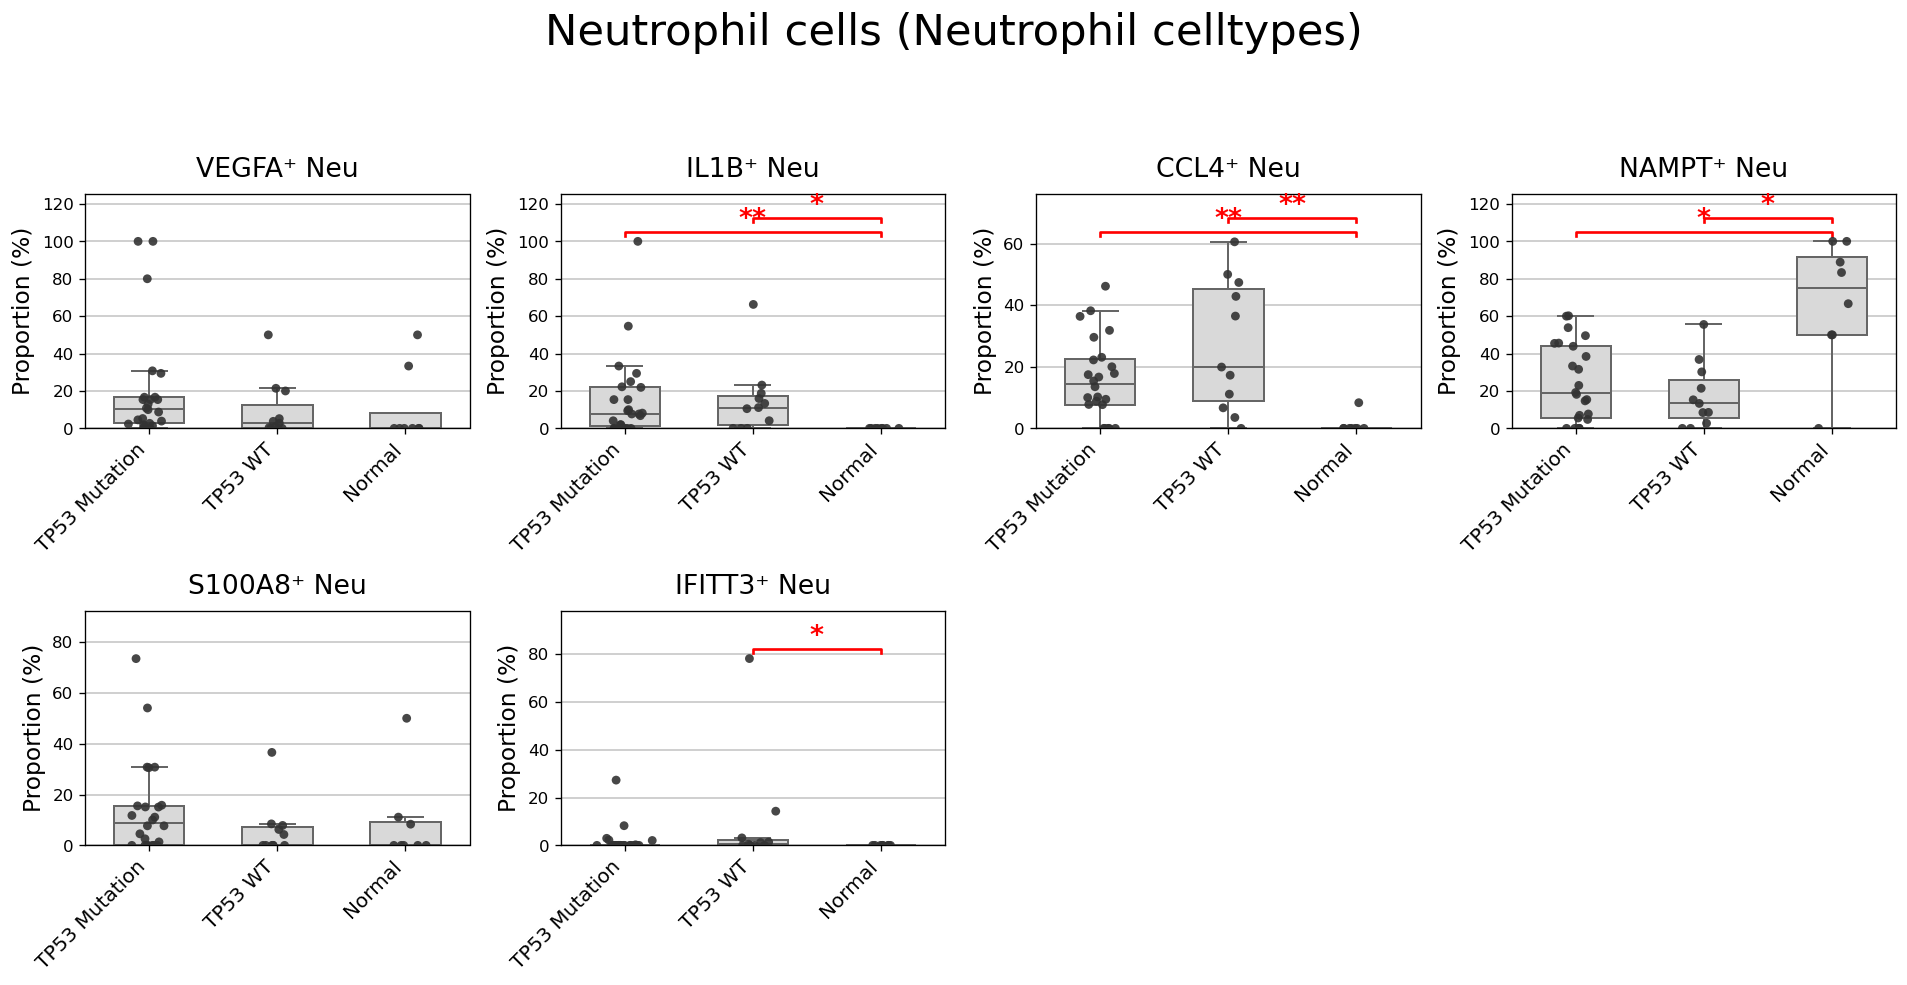

In [175]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

sample_col  = "sample"
group_col   = "TP53_mutation"
subtype_col = "Total celltype"

target_subtypes = [ 'VEGFA⁺ Neu', 'IL1B⁺ Neu','CCL4⁺ Neu','NAMPT⁺ Neu','S100A8⁺ Neu','IFITT3⁺ Neu']

group_order = ["TP53 Mutation", "TP53 WT", "Normal"]
show_only_sig = True

SUBPLOT_W = 4
SUBPLOT_H = 4
DPI = 120

FS_SUPTITLE = 26
FS_TITLE    = 16
FS_LABEL    = 14
FS_TICK     = 12
FS_STAR     = 16

def bh_adjust(pvals):
    pvals = np.array(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adj, 0, 1)
    return out.tolist()

def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, y, h, text, color="red", lw=1.6, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=color)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom",
            color=color, fontsize=fs, fontweight="bold")

obs = adata2.obs[[sample_col, group_col, subtype_col]].copy()
ct = (
    obs.groupby([sample_col, group_col, subtype_col], observed=True)
       .size()
       .unstack(fill_value=0)
)

ct_target = ct.reindex(columns=target_subtypes, fill_value=0)
denom_all = obs.groupby([sample_col, group_col], observed=True).size()
prop = ct_target.div(denom_all, axis=0) * 100
prop = prop.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

df = (
    prop.reset_index()
        .melt(
            id_vars=[sample_col, group_col],
            var_name="CD8_target_subtype",
            value_name="percent"
        )
)

df["percent"] = df["percent"].astype(float)
group_order = [g for g in group_order if g in df[group_col].unique()]

subtypes = target_subtypes
n_sub = len(subtypes)

ncols = min(4, n_sub)
nrows = math.ceil(n_sub / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(SUBPLOT_W * ncols, SUBPLOT_H * nrows),
    dpi=DPI,
    squeeze=False
)

rng = np.random.default_rng(0)

_global_pvals = []
_global_keys = []
_stats_cache = {}

for idx, subtype in enumerate(subtypes):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]

    d = df[df["CD8_target_subtype"] == subtype].copy()
    groups = [d.loc[d[group_col] == g, "percent"].dropna().values for g in group_order]
    positions = np.arange(1, len(group_order) + 1)

    bp = ax.boxplot(
        groups, positions=positions, widths=0.55,
        showfliers=False, patch_artist=True
    )
    for box in bp["boxes"]:
        box.set_facecolor("#d9d9d9")
        box.set_edgecolor("#666666")
        box.set_linewidth(1.2)
    for k in ["whiskers", "caps", "medians"]:
        for item in bp[k]:
            item.set_color("#666666")
            item.set_linewidth(1.2)

    for i, vals in enumerate(groups, start=1):
        x = rng.normal(loc=i, scale=0.07, size=len(vals))
        ax.scatter(x, vals, s=28, alpha=0.9, color="0.2",
                   edgecolors="none", zorder=3)

    ax.set_title(subtype, fontsize=FS_TITLE, pad=10, loc="center")
    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, rotation=45, ha="right", fontsize=FS_TICK)
    ax.set_ylabel("Proportion (%)", fontsize=FS_LABEL)

    ax.yaxis.grid(True, color="#c7c7c7", linewidth=1.0)
    ax.xaxis.grid(False)

    all_vals = np.concatenate([v for v in groups if len(v) > 0]) if any(len(v)>0 for v in groups) else np.array([0.0])
    y_max = float(np.nanmax(all_vals)) if np.isfinite(np.nanmax(all_vals)) else 0.0
    ax.set_ylim(0, max(1.0, y_max * 1.25 + 0.5))

    pairs = [(a, b) for a in range(len(group_order)) for b in range(a+1, len(group_order))]

    raw_p, ok_mask = [], []
    for a, b in pairs:
        A, B = groups[a], groups[b]
        A = A[np.isfinite(A)]
        B = B[np.isfinite(B)]
        if len(A) < 2 or len(B) < 2:
            raw_p.append(np.nan); ok_mask.append(False)
        else:
            p = stats.mannwhitneyu(A, B, alternative="two-sided").pvalue
            raw_p.append(p); ok_mask.append(True)

    _stats_cache[subtype] = {"ax": ax, "pairs": pairs, "raw_p": raw_p, "ok_mask": ok_mask}
    for pi, p in enumerate(raw_p):
        if np.isfinite(p) and ok_mask[pi]:
            _global_pvals.append(float(p))
            _global_keys.append((subtype, pi))

_global_adj_map = {}
if len(_global_pvals) > 0:
    _global_adj = bh_adjust(_global_pvals)
    _global_adj_map = {k: _global_adj[i] for i, k in enumerate(_global_keys)}

for subtype in subtypes:
    ax = _stats_cache[subtype]["ax"]
    pairs = _stats_cache[subtype]["pairs"]
    raw_p = _stats_cache[subtype]["raw_p"]
    ok_mask = _stats_cache[subtype]["ok_mask"]

    base = ax.get_ylim()[1] * 0.82
    step = ax.get_ylim()[1] * 0.06
    bar_i = 0

    for pi, (a, b) in enumerate(pairs):
        if not ok_mask[pi]:
            continue

        p_adj = _global_adj_map.get((subtype, pi), np.nan)
        star = p_to_star(p_adj)
        if show_only_sig and star == "ns":
            continue

        y = base + bar_i * step
        add_sig_bar(ax, a+1, b+1, y=y, h=step*0.25, text=star, color="red", fs=FS_STAR)
        bar_i += 1

for j in range(n_sub, nrows * ncols):
    rr, cc = divmod(j, ncols)
    fig.delaxes(axes[rr][cc])

fig.suptitle("Neutrophil cells (Neutrophil celltypes)", fontsize=FS_SUPTITLE,
             x=0.5, ha="center", y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

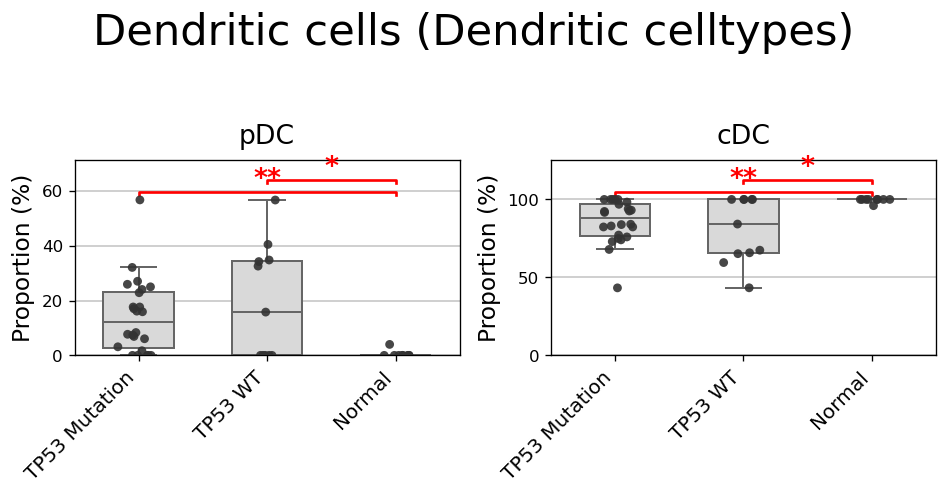

In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

sample_col  = "sample"
group_col   = "TP53_mutation"
subtype_col = "Total celltype"

target_subtypes = ['pDC','cDC']

group_order = ["TP53 Mutation", "TP53 WT", "Normal"]
show_only_sig = True

SUBPLOT_W = 4
SUBPLOT_H = 4
DPI = 120

FS_SUPTITLE = 26
FS_TITLE    = 16
FS_LABEL    = 14
FS_TICK     = 12
FS_STAR     = 16

def bh_adjust(pvals):
    pvals = np.array(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adj, 0, 1)
    return out.tolist()

def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, y, h, text, color="red", lw=1.6, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=color)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom",
            color=color, fontsize=fs, fontweight="bold")

obs = adata3.obs[[sample_col, group_col, subtype_col]].copy()
ct = (
    obs.groupby([sample_col, group_col, subtype_col], observed=True)
       .size()
       .unstack(fill_value=0)
)

ct_target = ct.reindex(columns=target_subtypes, fill_value=0)
denom_all = obs.groupby([sample_col, group_col], observed=True).size()
prop = ct_target.div(denom_all, axis=0) * 100
prop = prop.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

df = (
    prop.reset_index()
        .melt(
            id_vars=[sample_col, group_col],
            var_name="CD8_target_subtype",
            value_name="percent"
        )
)

df["percent"] = df["percent"].astype(float)
group_order = [g for g in group_order if g in df[group_col].unique()]

subtypes = target_subtypes
n_sub = len(subtypes)

ncols = min(4, n_sub)
nrows = math.ceil(n_sub / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(SUBPLOT_W * ncols, SUBPLOT_H * nrows),
    dpi=DPI,
    squeeze=False
)

rng = np.random.default_rng(0)

_global_pvals = []
_global_keys = []
_stats_cache = {}

for idx, subtype in enumerate(subtypes):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]

    d = df[df["CD8_target_subtype"] == subtype].copy()
    groups = [d.loc[d[group_col] == g, "percent"].dropna().values for g in group_order]
    positions = np.arange(1, len(group_order) + 1)

    bp = ax.boxplot(
        groups, positions=positions, widths=0.55,
        showfliers=False, patch_artist=True
    )
    for box in bp["boxes"]:
        box.set_facecolor("#d9d9d9")
        box.set_edgecolor("#666666")
        box.set_linewidth(1.2)
    for k in ["whiskers", "caps", "medians"]:
        for item in bp[k]:
            item.set_color("#666666")
            item.set_linewidth(1.2)

    for i, vals in enumerate(groups, start=1):
        x = rng.normal(loc=i, scale=0.07, size=len(vals))
        ax.scatter(x, vals, s=28, alpha=0.9, color="0.2",
                   edgecolors="none", zorder=3)

    ax.set_title(subtype, fontsize=FS_TITLE, pad=10, loc="center")
    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, rotation=45, ha="right", fontsize=FS_TICK)
    ax.set_ylabel("Proportion (%)", fontsize=FS_LABEL)

    ax.yaxis.grid(True, color="#c7c7c7", linewidth=1.0)
    ax.xaxis.grid(False)

    all_vals = np.concatenate([v for v in groups if len(v) > 0]) if any(len(v)>0 for v in groups) else np.array([0.0])
    y_max = float(np.nanmax(all_vals)) if np.isfinite(np.nanmax(all_vals)) else 0.0
    ax.set_ylim(0, max(1.0, y_max * 1.25 + 0.5))

    pairs = [(a, b) for a in range(len(group_order)) for b in range(a+1, len(group_order))]

    raw_p, ok_mask = [], []
    for a, b in pairs:
        A, B = groups[a], groups[b]
        A = A[np.isfinite(A)]
        B = B[np.isfinite(B)]
        if len(A) < 2 or len(B) < 2:
            raw_p.append(np.nan); ok_mask.append(False)
        else:
            p = stats.mannwhitneyu(A, B, alternative="two-sided").pvalue
            raw_p.append(p); ok_mask.append(True)

    _stats_cache[subtype] = {"ax": ax, "pairs": pairs, "raw_p": raw_p, "ok_mask": ok_mask}
    for pi, p in enumerate(raw_p):
        if np.isfinite(p) and ok_mask[pi]:
            _global_pvals.append(float(p))
            _global_keys.append((subtype, pi))

_global_adj_map = {}
if len(_global_pvals) > 0:
    _global_adj = bh_adjust(_global_pvals)
    _global_adj_map = {k: _global_adj[i] for i, k in enumerate(_global_keys)}

for subtype in subtypes:
    ax = _stats_cache[subtype]["ax"]
    pairs = _stats_cache[subtype]["pairs"]
    raw_p = _stats_cache[subtype]["raw_p"]
    ok_mask = _stats_cache[subtype]["ok_mask"]

    base = ax.get_ylim()[1] * 0.82
    step = ax.get_ylim()[1] * 0.06
    bar_i = 0

    for pi, (a, b) in enumerate(pairs):
        if not ok_mask[pi]:
            continue

        p_adj = _global_adj_map.get((subtype, pi), np.nan)
        star = p_to_star(p_adj)
        if show_only_sig and star == "ns":
            continue

        y = base + bar_i * step
        add_sig_bar(ax, a+1, b+1, y=y, h=step*0.25, text=star, color="red", fs=FS_STAR)
        bar_i += 1

for j in range(n_sub, nrows * ncols):
    rr, cc = divmod(j, ncols)
    fig.delaxes(axes[rr][cc])

fig.suptitle("Dendritic cells (Dendritic celltypes)", fontsize=FS_SUPTITLE,
             x=0.5, ha="center", y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# KRAS proportion

In [146]:
import scanpy as sc
adata = sc.read_h5ad("/home/Data_Drive_8TB_2/CRC_2026/KRAS_project/Cellbender_KRAS_RE/h5ad/crc_36_patients_celltype_annotation_260121.h5ad")

In [153]:
adata.obs['KRAS_mutation']

CCTTCGAGTACACCGC-1-H1    KRAS Mutation
ACGCCAGTCTTGTTTG-1-H1    KRAS Mutation
AGCTCTCGTCTAGTCA-1-H1    KRAS Mutation
GTCGTAACACGCGAAA-1-H1    KRAS Mutation
TCATTACAGAGAGCTC-1-H1    KRAS Mutation
                             ...      
CTCGTACGTAGGAGTC-1-H9    KRAS Mutation
TAAACCGAGAGGTAGA-1-H9    KRAS Mutation
CAGAATCCACCATCCT-1-H9    KRAS Mutation
CTTAGGATCTGTTGAG-1-H9    KRAS Mutation
GGTGCGTTCTTTAGGG-1-H9    KRAS Mutation
Name: KRAS_mutation, Length: 112182, dtype: category
Categories (3, object): ['KRAS Mutation', 'KRAS WT', 'Normal']

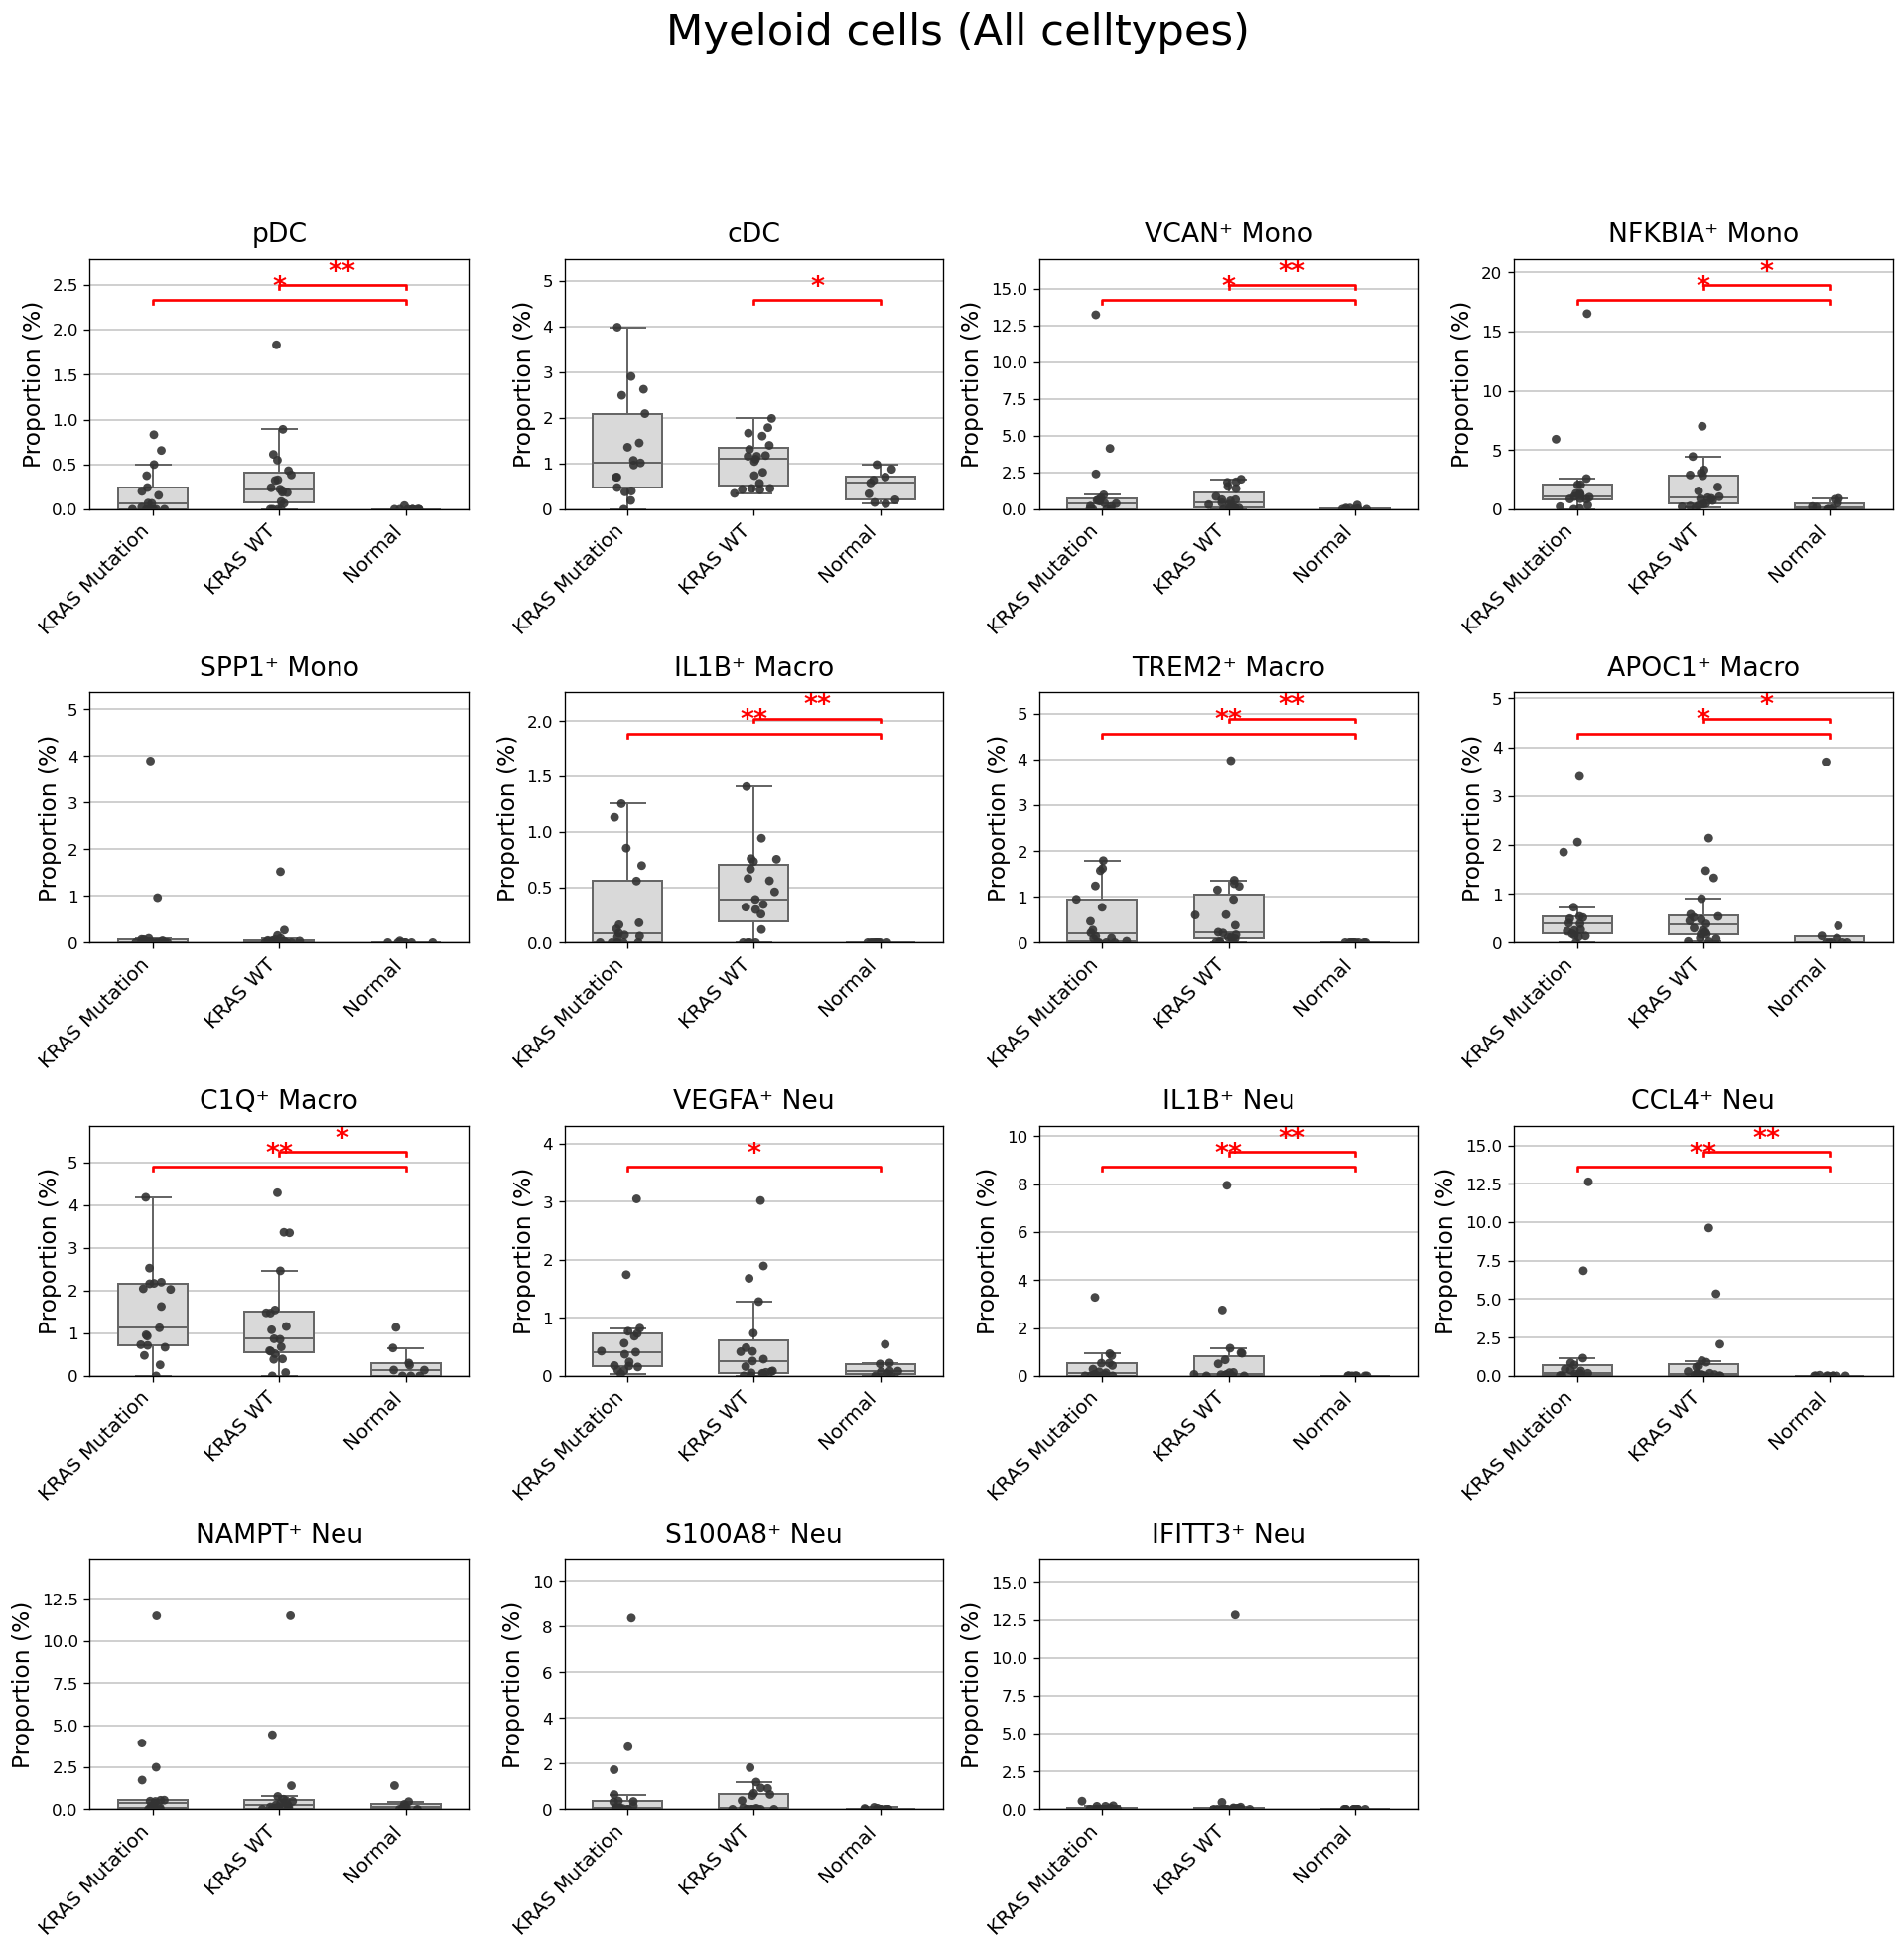

In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

sample_col  = "sample"
group_col   = "KRAS_mutation"
subtype_col = "Total celltype"

target_subtypes = ['pDC', 'cDC',
 'VCAN⁺ Mono', 'NFKBIA⁺ Mono','SPP1⁺ Mono', 
 'IL1B⁺ Macro', 'TREM2⁺ Macro','APOC1⁺ Macro', 'C1Q⁺ Macro',
 'VEGFA⁺ Neu', 'IL1B⁺ Neu','CCL4⁺ Neu','NAMPT⁺ Neu','S100A8⁺ Neu','IFITT3⁺ Neu']

group_order = ["KRAS Mutation", "KRAS WT", "Normal"]
show_only_sig = True

SUBPLOT_W = 4
SUBPLOT_H = 4
DPI = 120

FS_SUPTITLE = 26
FS_TITLE    = 16
FS_LABEL    = 14
FS_TICK     = 12
FS_STAR     = 16

def bh_adjust(pvals):
    pvals = np.array(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adj, 0, 1)
    return out.tolist()

def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, y, h, text, color="red", lw=1.6, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=color)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom",
            color=color, fontsize=fs, fontweight="bold")

obs = adata.obs[[sample_col, group_col, subtype_col]].copy()
ct = (
    obs.groupby([sample_col, group_col, subtype_col], observed=True)
       .size()
       .unstack(fill_value=0)
)

ct_target = ct.reindex(columns=target_subtypes, fill_value=0)
denom_all = obs.groupby([sample_col, group_col], observed=True).size()
prop = ct_target.div(denom_all, axis=0) * 100
prop = prop.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

df = (
    prop.reset_index()
        .melt(
            id_vars=[sample_col, group_col],
            var_name="CD8_target_subtype",
            value_name="percent"
        )
)

df["percent"] = df["percent"].astype(float)
group_order = [g for g in group_order if g in df[group_col].unique()]

subtypes = target_subtypes
n_sub = len(subtypes)

ncols = min(4, n_sub)
nrows = math.ceil(n_sub / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(SUBPLOT_W * ncols, SUBPLOT_H * nrows),
    dpi=DPI,
    squeeze=False
)

rng = np.random.default_rng(0)

_global_pvals = []
_global_keys = []
_stats_cache = {}

for idx, subtype in enumerate(subtypes):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]

    d = df[df["CD8_target_subtype"] == subtype].copy()
    groups = [d.loc[d[group_col] == g, "percent"].dropna().values for g in group_order]
    positions = np.arange(1, len(group_order) + 1)

    bp = ax.boxplot(
        groups, positions=positions, widths=0.55,
        showfliers=False, patch_artist=True
    )
    for box in bp["boxes"]:
        box.set_facecolor("#d9d9d9")
        box.set_edgecolor("#666666")
        box.set_linewidth(1.2)
    for k in ["whiskers", "caps", "medians"]:
        for item in bp[k]:
            item.set_color("#666666")
            item.set_linewidth(1.2)

    for i, vals in enumerate(groups, start=1):
        x = rng.normal(loc=i, scale=0.07, size=len(vals))
        ax.scatter(x, vals, s=28, alpha=0.9, color="0.2",
                   edgecolors="none", zorder=3)

    ax.set_title(subtype, fontsize=FS_TITLE, pad=10, loc="center")
    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, rotation=45, ha="right", fontsize=FS_TICK)
    ax.set_ylabel("Proportion (%)", fontsize=FS_LABEL)

    ax.yaxis.grid(True, color="#c7c7c7", linewidth=1.0)
    ax.xaxis.grid(False)

    all_vals = np.concatenate([v for v in groups if len(v) > 0]) if any(len(v)>0 for v in groups) else np.array([0.0])
    y_max = float(np.nanmax(all_vals)) if np.isfinite(np.nanmax(all_vals)) else 0.0
    ax.set_ylim(0, max(1.0, y_max * 1.25 + 0.5))

    pairs = [(a, b) for a in range(len(group_order)) for b in range(a+1, len(group_order))]

    raw_p, ok_mask = [], []
    for a, b in pairs:
        A, B = groups[a], groups[b]
        A = A[np.isfinite(A)]
        B = B[np.isfinite(B)]
        if len(A) < 2 or len(B) < 2:
            raw_p.append(np.nan); ok_mask.append(False)
        else:
            p = stats.mannwhitneyu(A, B, alternative="two-sided").pvalue
            raw_p.append(p); ok_mask.append(True)

    _stats_cache[subtype] = {"ax": ax, "pairs": pairs, "raw_p": raw_p, "ok_mask": ok_mask}
    for pi, p in enumerate(raw_p):
        if np.isfinite(p) and ok_mask[pi]:
            _global_pvals.append(float(p))
            _global_keys.append((subtype, pi))

_global_adj_map = {}
if len(_global_pvals) > 0:
    _global_adj = bh_adjust(_global_pvals)
    _global_adj_map = {k: _global_adj[i] for i, k in enumerate(_global_keys)}

for subtype in subtypes:
    ax = _stats_cache[subtype]["ax"]
    pairs = _stats_cache[subtype]["pairs"]
    raw_p = _stats_cache[subtype]["raw_p"]
    ok_mask = _stats_cache[subtype]["ok_mask"]

    base = ax.get_ylim()[1] * 0.82
    step = ax.get_ylim()[1] * 0.06
    bar_i = 0

    for pi, (a, b) in enumerate(pairs):
        if not ok_mask[pi]:
            continue

        p_adj = _global_adj_map.get((subtype, pi), np.nan)
        star = p_to_star(p_adj)
        if show_only_sig and star == "ns":
            continue

        y = base + bar_i * step
        add_sig_bar(ax, a+1, b+1, y=y, h=step*0.25, text=star, color="red", fs=FS_STAR)
        bar_i += 1

for j in range(n_sub, nrows * ncols):
    rr, cc = divmod(j, ncols)
    fig.delaxes(axes[rr][cc])

fig.suptitle("Myeloid cells (All celltypes)", fontsize=FS_SUPTITLE,
             x=0.5, ha="center", y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [155]:
selected = ['Myeloid', 'NK/T', 'Neutrophil']

adata = adata[adata.obs['cell_type'].isin(selected)].copy()

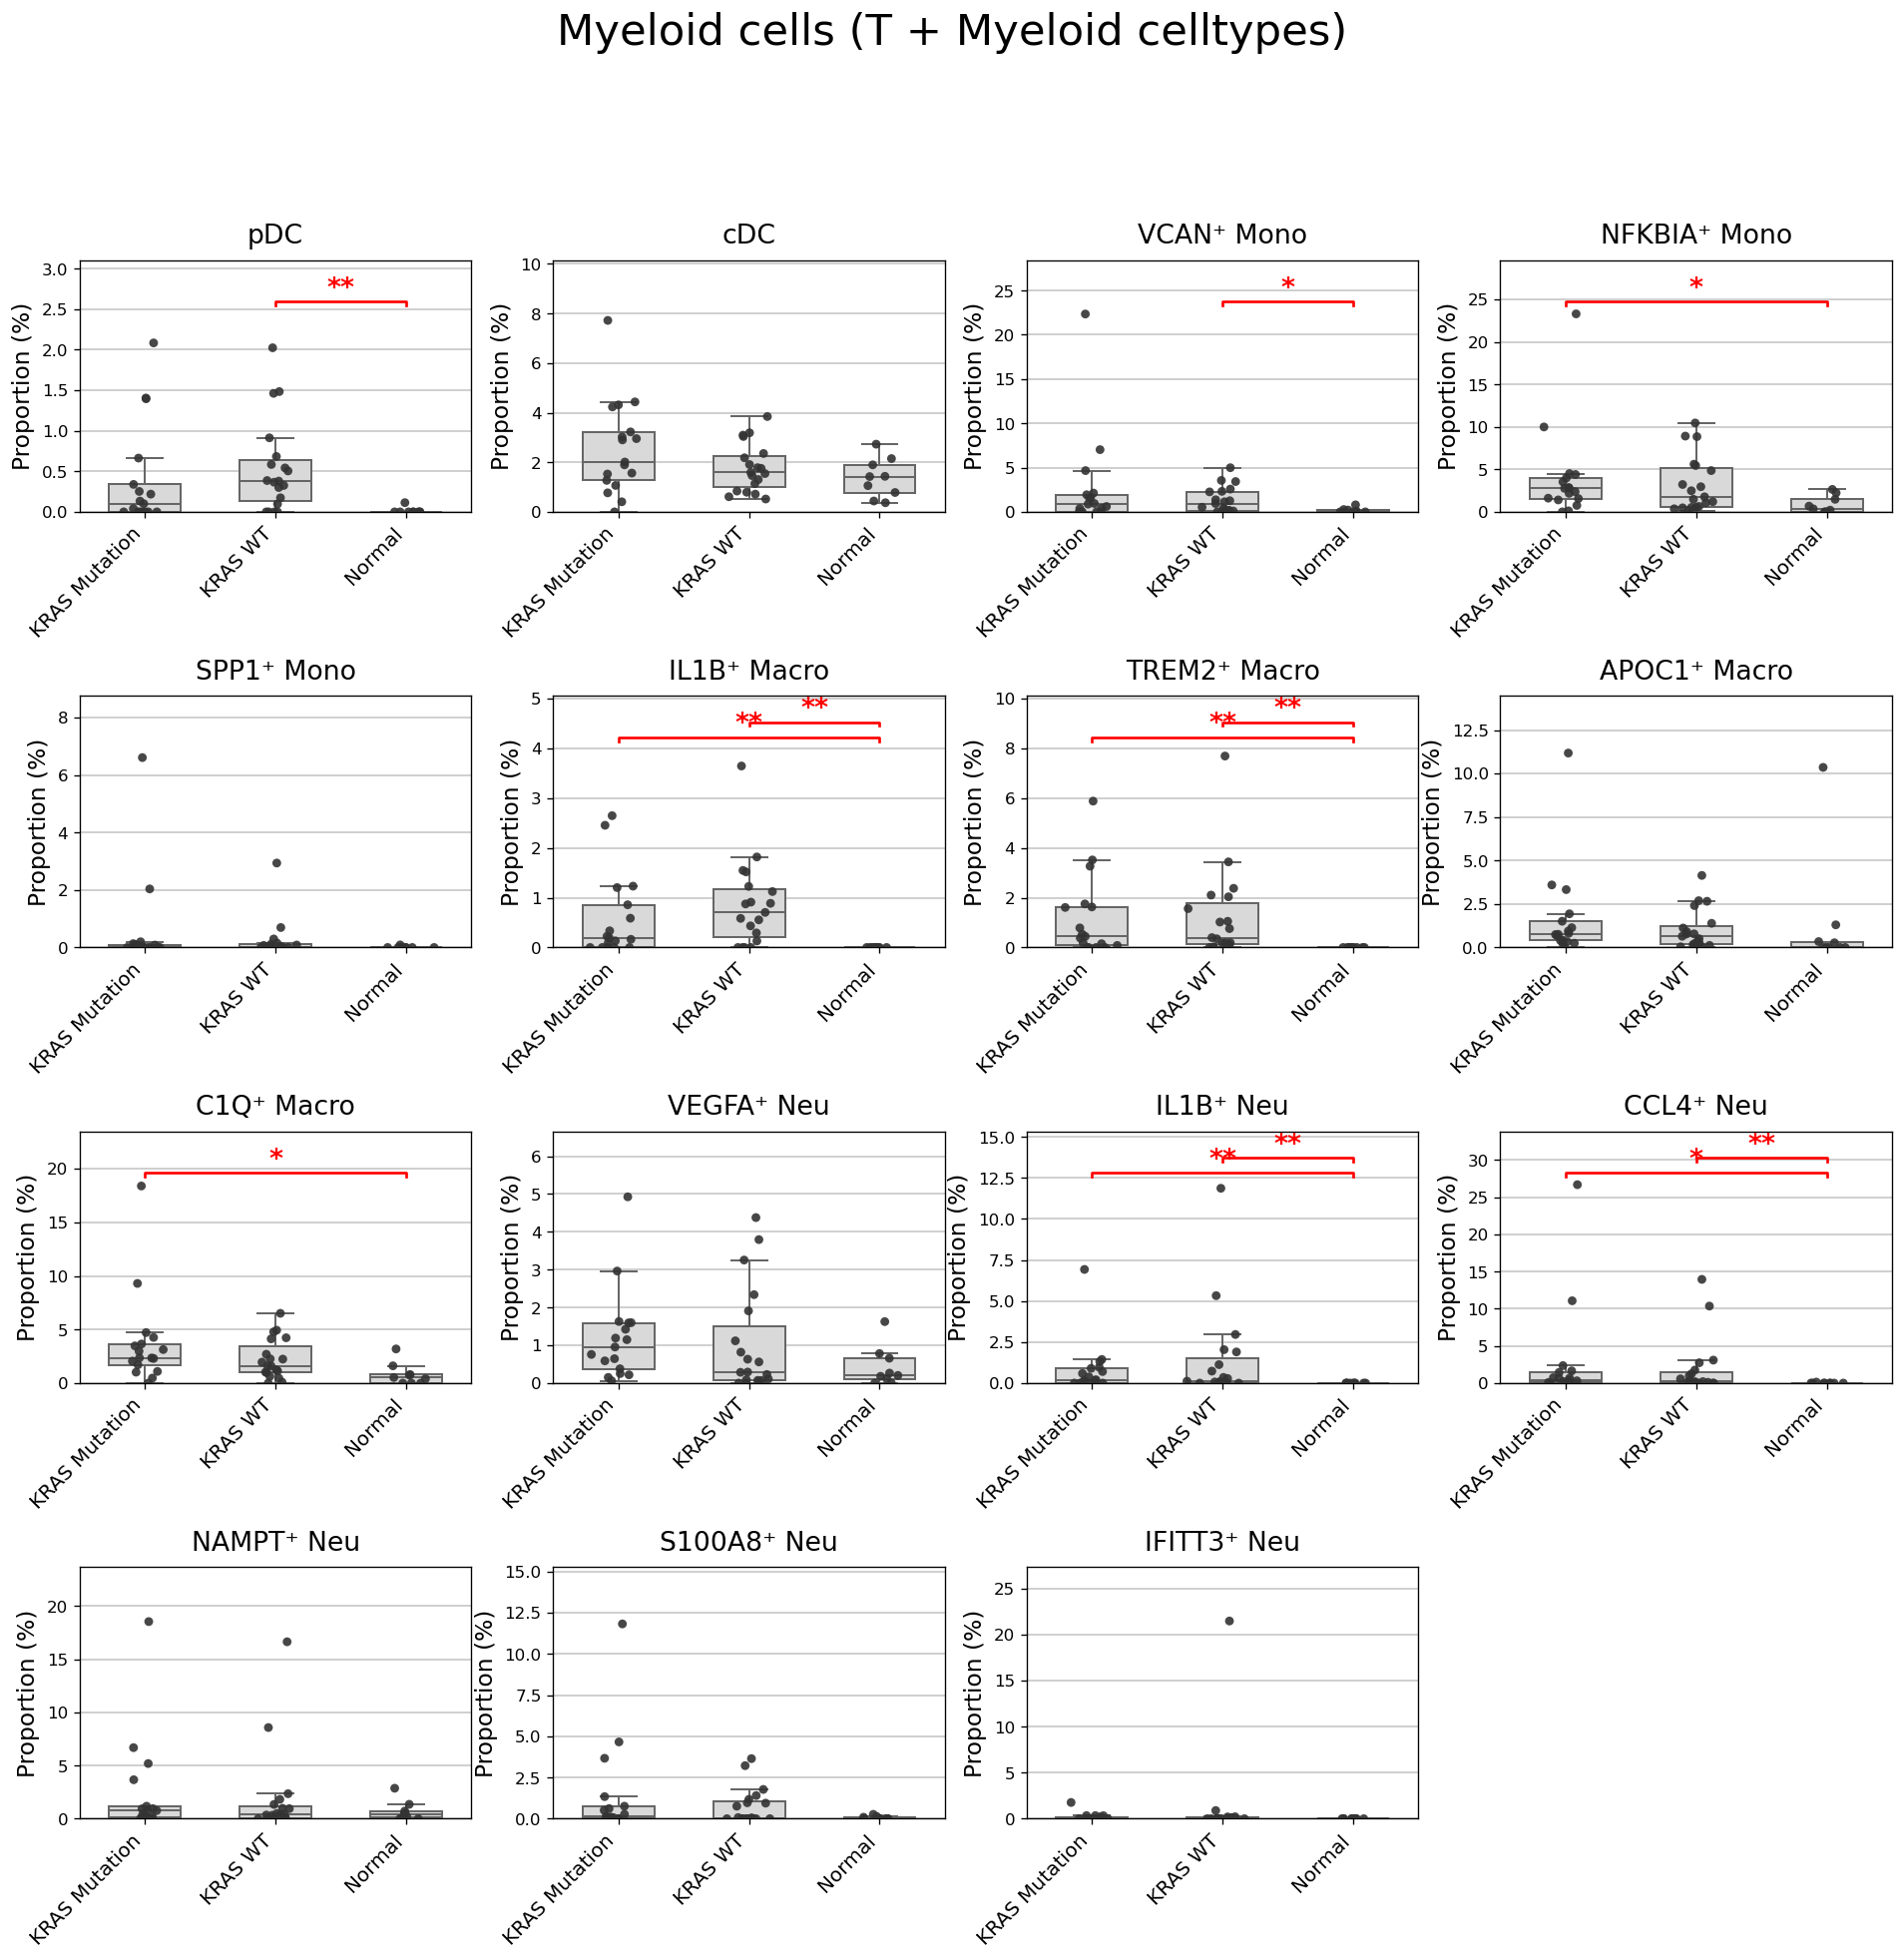

In [156]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

sample_col  = "sample"
group_col   = "KRAS_mutation"
subtype_col = "Total celltype"

target_subtypes = ['pDC', 'cDC',
 'VCAN⁺ Mono', 'NFKBIA⁺ Mono','SPP1⁺ Mono', 
 'IL1B⁺ Macro', 'TREM2⁺ Macro','APOC1⁺ Macro', 'C1Q⁺ Macro',
 'VEGFA⁺ Neu', 'IL1B⁺ Neu','CCL4⁺ Neu','NAMPT⁺ Neu','S100A8⁺ Neu','IFITT3⁺ Neu']

group_order = ["KRAS Mutation", "KRAS WT", "Normal"]
show_only_sig = True

SUBPLOT_W = 4
SUBPLOT_H = 4
DPI = 120

FS_SUPTITLE = 26
FS_TITLE    = 16
FS_LABEL    = 14
FS_TICK     = 12
FS_STAR     = 16

def bh_adjust(pvals):
    pvals = np.array(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adj, 0, 1)
    return out.tolist()

def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, y, h, text, color="red", lw=1.6, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=color)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom",
            color=color, fontsize=fs, fontweight="bold")

obs = adata.obs[[sample_col, group_col, subtype_col]].copy()
ct = (
    obs.groupby([sample_col, group_col, subtype_col], observed=True)
       .size()
       .unstack(fill_value=0)
)

ct_target = ct.reindex(columns=target_subtypes, fill_value=0)
denom_all = obs.groupby([sample_col, group_col], observed=True).size()
prop = ct_target.div(denom_all, axis=0) * 100
prop = prop.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

df = (
    prop.reset_index()
        .melt(
            id_vars=[sample_col, group_col],
            var_name="CD8_target_subtype",
            value_name="percent"
        )
)

df["percent"] = df["percent"].astype(float)
group_order = [g for g in group_order if g in df[group_col].unique()]

subtypes = target_subtypes
n_sub = len(subtypes)

ncols = min(4, n_sub)
nrows = math.ceil(n_sub / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(SUBPLOT_W * ncols, SUBPLOT_H * nrows),
    dpi=DPI,
    squeeze=False
)

rng = np.random.default_rng(0)

_global_pvals = []
_global_keys = []
_stats_cache = {}

for idx, subtype in enumerate(subtypes):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]

    d = df[df["CD8_target_subtype"] == subtype].copy()
    groups = [d.loc[d[group_col] == g, "percent"].dropna().values for g in group_order]
    positions = np.arange(1, len(group_order) + 1)

    bp = ax.boxplot(
        groups, positions=positions, widths=0.55,
        showfliers=False, patch_artist=True
    )
    for box in bp["boxes"]:
        box.set_facecolor("#d9d9d9")
        box.set_edgecolor("#666666")
        box.set_linewidth(1.2)
    for k in ["whiskers", "caps", "medians"]:
        for item in bp[k]:
            item.set_color("#666666")
            item.set_linewidth(1.2)

    for i, vals in enumerate(groups, start=1):
        x = rng.normal(loc=i, scale=0.07, size=len(vals))
        ax.scatter(x, vals, s=28, alpha=0.9, color="0.2",
                   edgecolors="none", zorder=3)

    ax.set_title(subtype, fontsize=FS_TITLE, pad=10, loc="center")
    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, rotation=45, ha="right", fontsize=FS_TICK)
    ax.set_ylabel("Proportion (%)", fontsize=FS_LABEL)

    ax.yaxis.grid(True, color="#c7c7c7", linewidth=1.0)
    ax.xaxis.grid(False)

    all_vals = np.concatenate([v for v in groups if len(v) > 0]) if any(len(v)>0 for v in groups) else np.array([0.0])
    y_max = float(np.nanmax(all_vals)) if np.isfinite(np.nanmax(all_vals)) else 0.0
    ax.set_ylim(0, max(1.0, y_max * 1.25 + 0.5))

    pairs = [(a, b) for a in range(len(group_order)) for b in range(a+1, len(group_order))]

    raw_p, ok_mask = [], []
    for a, b in pairs:
        A, B = groups[a], groups[b]
        A = A[np.isfinite(A)]
        B = B[np.isfinite(B)]
        if len(A) < 2 or len(B) < 2:
            raw_p.append(np.nan); ok_mask.append(False)
        else:
            p = stats.mannwhitneyu(A, B, alternative="two-sided").pvalue
            raw_p.append(p); ok_mask.append(True)

    _stats_cache[subtype] = {"ax": ax, "pairs": pairs, "raw_p": raw_p, "ok_mask": ok_mask}
    for pi, p in enumerate(raw_p):
        if np.isfinite(p) and ok_mask[pi]:
            _global_pvals.append(float(p))
            _global_keys.append((subtype, pi))

_global_adj_map = {}
if len(_global_pvals) > 0:
    _global_adj = bh_adjust(_global_pvals)
    _global_adj_map = {k: _global_adj[i] for i, k in enumerate(_global_keys)}

for subtype in subtypes:
    ax = _stats_cache[subtype]["ax"]
    pairs = _stats_cache[subtype]["pairs"]
    raw_p = _stats_cache[subtype]["raw_p"]
    ok_mask = _stats_cache[subtype]["ok_mask"]

    base = ax.get_ylim()[1] * 0.82
    step = ax.get_ylim()[1] * 0.06
    bar_i = 0

    for pi, (a, b) in enumerate(pairs):
        if not ok_mask[pi]:
            continue

        p_adj = _global_adj_map.get((subtype, pi), np.nan)
        star = p_to_star(p_adj)
        if show_only_sig and star == "ns":
            continue

        y = base + bar_i * step
        add_sig_bar(ax, a+1, b+1, y=y, h=step*0.25, text=star, color="red", fs=FS_STAR)
        bar_i += 1

for j in range(n_sub, nrows * ncols):
    rr, cc = divmod(j, ncols)
    fig.delaxes(axes[rr][cc])

fig.suptitle("Myeloid cells (T + Myeloid celltypes)", fontsize=FS_SUPTITLE,
             x=0.5, ha="center", y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [157]:
selected = ['Myeloid','Neutrophil']

adata = adata[adata.obs['cell_type'].isin(selected)].copy()

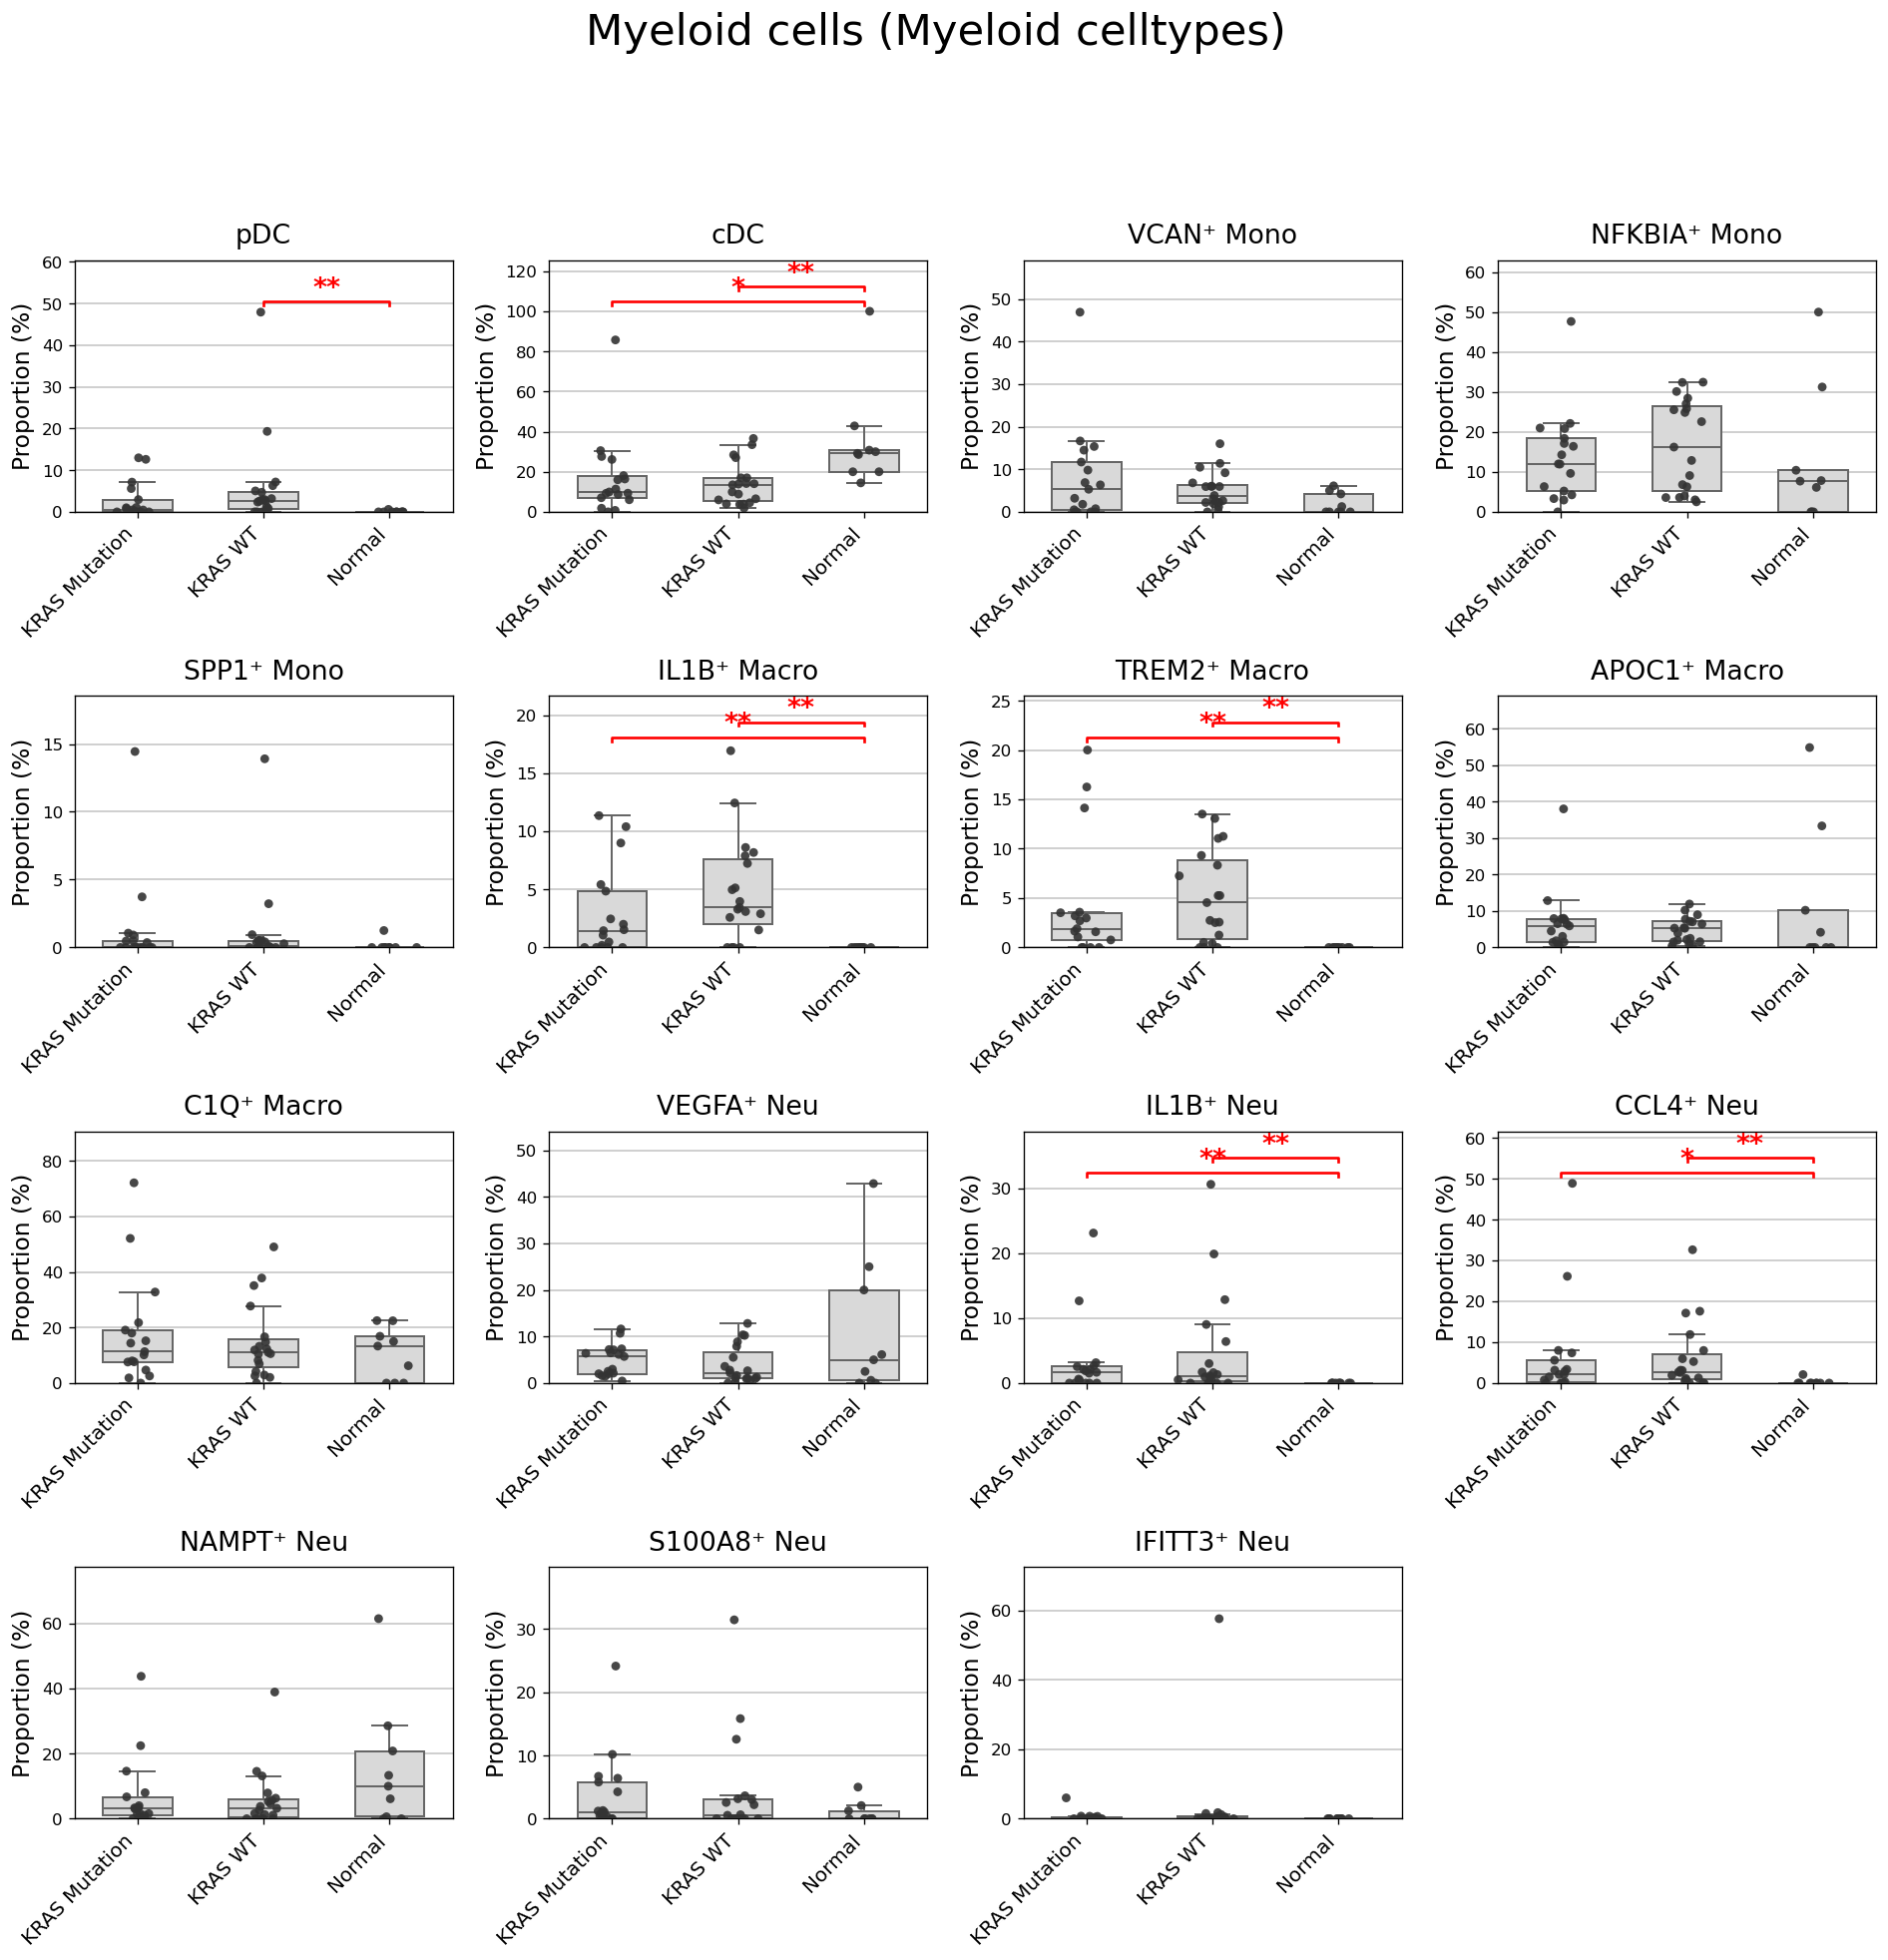

In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

sample_col  = "sample"
group_col   = "KRAS_mutation"
subtype_col = "Total celltype"

target_subtypes = ['pDC', 'cDC',
 'VCAN⁺ Mono', 'NFKBIA⁺ Mono','SPP1⁺ Mono', 
 'IL1B⁺ Macro', 'TREM2⁺ Macro','APOC1⁺ Macro', 'C1Q⁺ Macro',
 'VEGFA⁺ Neu', 'IL1B⁺ Neu','CCL4⁺ Neu','NAMPT⁺ Neu','S100A8⁺ Neu','IFITT3⁺ Neu']

group_order = ["KRAS Mutation", "KRAS WT", "Normal"]
show_only_sig = True

SUBPLOT_W = 4
SUBPLOT_H = 4
DPI = 120

FS_SUPTITLE = 26
FS_TITLE    = 16
FS_LABEL    = 14
FS_TICK     = 12
FS_STAR     = 16

def bh_adjust(pvals):
    pvals = np.array(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adj, 0, 1)
    return out.tolist()

def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, y, h, text, color="red", lw=1.6, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=color)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom",
            color=color, fontsize=fs, fontweight="bold")

obs = adata.obs[[sample_col, group_col, subtype_col]].copy()
ct = (
    obs.groupby([sample_col, group_col, subtype_col], observed=True)
       .size()
       .unstack(fill_value=0)
)

ct_target = ct.reindex(columns=target_subtypes, fill_value=0)
denom_all = obs.groupby([sample_col, group_col], observed=True).size()
prop = ct_target.div(denom_all, axis=0) * 100
prop = prop.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

df = (
    prop.reset_index()
        .melt(
            id_vars=[sample_col, group_col],
            var_name="CD8_target_subtype",
            value_name="percent"
        )
)

df["percent"] = df["percent"].astype(float)
group_order = [g for g in group_order if g in df[group_col].unique()]

subtypes = target_subtypes
n_sub = len(subtypes)

ncols = min(4, n_sub)
nrows = math.ceil(n_sub / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(SUBPLOT_W * ncols, SUBPLOT_H * nrows),
    dpi=DPI,
    squeeze=False
)

rng = np.random.default_rng(0)

_global_pvals = []
_global_keys = []
_stats_cache = {}

for idx, subtype in enumerate(subtypes):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]

    d = df[df["CD8_target_subtype"] == subtype].copy()
    groups = [d.loc[d[group_col] == g, "percent"].dropna().values for g in group_order]
    positions = np.arange(1, len(group_order) + 1)

    bp = ax.boxplot(
        groups, positions=positions, widths=0.55,
        showfliers=False, patch_artist=True
    )
    for box in bp["boxes"]:
        box.set_facecolor("#d9d9d9")
        box.set_edgecolor("#666666")
        box.set_linewidth(1.2)
    for k in ["whiskers", "caps", "medians"]:
        for item in bp[k]:
            item.set_color("#666666")
            item.set_linewidth(1.2)

    for i, vals in enumerate(groups, start=1):
        x = rng.normal(loc=i, scale=0.07, size=len(vals))
        ax.scatter(x, vals, s=28, alpha=0.9, color="0.2",
                   edgecolors="none", zorder=3)

    ax.set_title(subtype, fontsize=FS_TITLE, pad=10, loc="center")
    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, rotation=45, ha="right", fontsize=FS_TICK)
    ax.set_ylabel("Proportion (%)", fontsize=FS_LABEL)

    ax.yaxis.grid(True, color="#c7c7c7", linewidth=1.0)
    ax.xaxis.grid(False)

    all_vals = np.concatenate([v for v in groups if len(v) > 0]) if any(len(v)>0 for v in groups) else np.array([0.0])
    y_max = float(np.nanmax(all_vals)) if np.isfinite(np.nanmax(all_vals)) else 0.0
    ax.set_ylim(0, max(1.0, y_max * 1.25 + 0.5))

    pairs = [(a, b) for a in range(len(group_order)) for b in range(a+1, len(group_order))]

    raw_p, ok_mask = [], []
    for a, b in pairs:
        A, B = groups[a], groups[b]
        A = A[np.isfinite(A)]
        B = B[np.isfinite(B)]
        if len(A) < 2 or len(B) < 2:
            raw_p.append(np.nan); ok_mask.append(False)
        else:
            p = stats.mannwhitneyu(A, B, alternative="two-sided").pvalue
            raw_p.append(p); ok_mask.append(True)

    _stats_cache[subtype] = {"ax": ax, "pairs": pairs, "raw_p": raw_p, "ok_mask": ok_mask}
    for pi, p in enumerate(raw_p):
        if np.isfinite(p) and ok_mask[pi]:
            _global_pvals.append(float(p))
            _global_keys.append((subtype, pi))

_global_adj_map = {}
if len(_global_pvals) > 0:
    _global_adj = bh_adjust(_global_pvals)
    _global_adj_map = {k: _global_adj[i] for i, k in enumerate(_global_keys)}

for subtype in subtypes:
    ax = _stats_cache[subtype]["ax"]
    pairs = _stats_cache[subtype]["pairs"]
    raw_p = _stats_cache[subtype]["raw_p"]
    ok_mask = _stats_cache[subtype]["ok_mask"]

    base = ax.get_ylim()[1] * 0.82
    step = ax.get_ylim()[1] * 0.06
    bar_i = 0

    for pi, (a, b) in enumerate(pairs):
        if not ok_mask[pi]:
            continue

        p_adj = _global_adj_map.get((subtype, pi), np.nan)
        star = p_to_star(p_adj)
        if show_only_sig and star == "ns":
            continue

        y = base + bar_i * step
        add_sig_bar(ax, a+1, b+1, y=y, h=step*0.25, text=star, color="red", fs=FS_STAR)
        bar_i += 1

for j in range(n_sub, nrows * ncols):
    rr, cc = divmod(j, ncols)
    fig.delaxes(axes[rr][cc])

fig.suptitle("Myeloid cells (Myeloid celltypes)", fontsize=FS_SUPTITLE,
             x=0.5, ha="center", y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [159]:
selected1 = ['Myeloid']
selected2 = ['Neutrophil']
selected3 = ['pDC','cDC']

adata1 = adata[adata.obs['cell_type'].isin(selected1)].copy()
adata2 = adata[adata.obs['cell_type'].isin(selected2)].copy()
adata3 = adata[adata.obs['Total celltype'].isin(selected3)].copy()

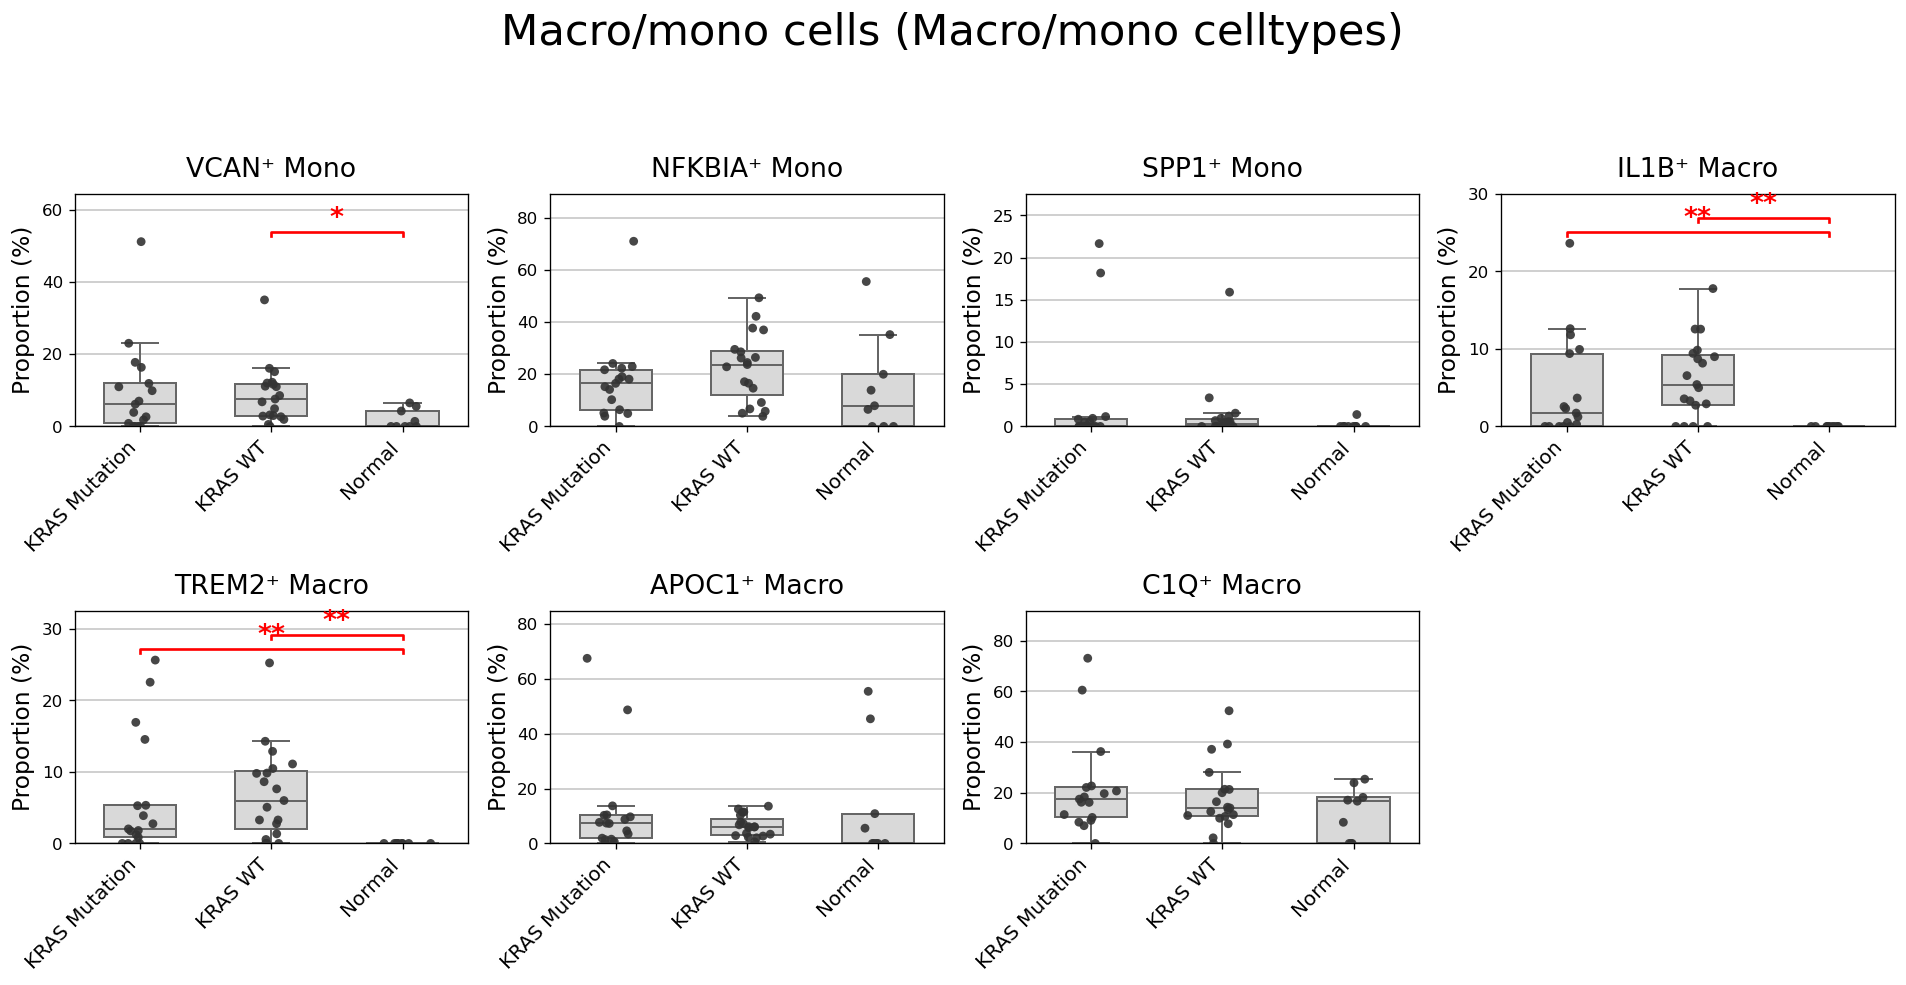

In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

sample_col  = "sample"
group_col   = "KRAS_mutation"
subtype_col = "Total celltype"

target_subtypes = [
 'VCAN⁺ Mono', 'NFKBIA⁺ Mono','SPP1⁺ Mono', 
 'IL1B⁺ Macro', 'TREM2⁺ Macro','APOC1⁺ Macro', 'C1Q⁺ Macro']

group_order = ["KRAS Mutation", "KRAS WT", "Normal"]
show_only_sig = True

SUBPLOT_W = 4
SUBPLOT_H = 4
DPI = 120

FS_SUPTITLE = 26
FS_TITLE    = 16
FS_LABEL    = 14
FS_TICK     = 12
FS_STAR     = 16

def bh_adjust(pvals):
    pvals = np.array(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adj, 0, 1)
    return out.tolist()

def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, y, h, text, color="red", lw=1.6, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=color)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom",
            color=color, fontsize=fs, fontweight="bold")

obs = adata1.obs[[sample_col, group_col, subtype_col]].copy()
ct = (
    obs.groupby([sample_col, group_col, subtype_col], observed=True)
       .size()
       .unstack(fill_value=0)
)

ct_target = ct.reindex(columns=target_subtypes, fill_value=0)
denom_all = obs.groupby([sample_col, group_col], observed=True).size()
prop = ct_target.div(denom_all, axis=0) * 100
prop = prop.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

df = (
    prop.reset_index()
        .melt(
            id_vars=[sample_col, group_col],
            var_name="CD8_target_subtype",
            value_name="percent"
        )
)

df["percent"] = df["percent"].astype(float)
group_order = [g for g in group_order if g in df[group_col].unique()]

subtypes = target_subtypes
n_sub = len(subtypes)

ncols = min(4, n_sub)
nrows = math.ceil(n_sub / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(SUBPLOT_W * ncols, SUBPLOT_H * nrows),
    dpi=DPI,
    squeeze=False
)

rng = np.random.default_rng(0)

_global_pvals = []
_global_keys = []
_stats_cache = {}

for idx, subtype in enumerate(subtypes):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]

    d = df[df["CD8_target_subtype"] == subtype].copy()
    groups = [d.loc[d[group_col] == g, "percent"].dropna().values for g in group_order]
    positions = np.arange(1, len(group_order) + 1)

    bp = ax.boxplot(
        groups, positions=positions, widths=0.55,
        showfliers=False, patch_artist=True
    )
    for box in bp["boxes"]:
        box.set_facecolor("#d9d9d9")
        box.set_edgecolor("#666666")
        box.set_linewidth(1.2)
    for k in ["whiskers", "caps", "medians"]:
        for item in bp[k]:
            item.set_color("#666666")
            item.set_linewidth(1.2)

    for i, vals in enumerate(groups, start=1):
        x = rng.normal(loc=i, scale=0.07, size=len(vals))
        ax.scatter(x, vals, s=28, alpha=0.9, color="0.2",
                   edgecolors="none", zorder=3)

    ax.set_title(subtype, fontsize=FS_TITLE, pad=10, loc="center")
    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, rotation=45, ha="right", fontsize=FS_TICK)
    ax.set_ylabel("Proportion (%)", fontsize=FS_LABEL)

    ax.yaxis.grid(True, color="#c7c7c7", linewidth=1.0)
    ax.xaxis.grid(False)

    all_vals = np.concatenate([v for v in groups if len(v) > 0]) if any(len(v)>0 for v in groups) else np.array([0.0])
    y_max = float(np.nanmax(all_vals)) if np.isfinite(np.nanmax(all_vals)) else 0.0
    ax.set_ylim(0, max(1.0, y_max * 1.25 + 0.5))

    pairs = [(a, b) for a in range(len(group_order)) for b in range(a+1, len(group_order))]

    raw_p, ok_mask = [], []
    for a, b in pairs:
        A, B = groups[a], groups[b]
        A = A[np.isfinite(A)]
        B = B[np.isfinite(B)]
        if len(A) < 2 or len(B) < 2:
            raw_p.append(np.nan); ok_mask.append(False)
        else:
            p = stats.mannwhitneyu(A, B, alternative="two-sided").pvalue
            raw_p.append(p); ok_mask.append(True)

    _stats_cache[subtype] = {"ax": ax, "pairs": pairs, "raw_p": raw_p, "ok_mask": ok_mask}
    for pi, p in enumerate(raw_p):
        if np.isfinite(p) and ok_mask[pi]:
            _global_pvals.append(float(p))
            _global_keys.append((subtype, pi))

_global_adj_map = {}
if len(_global_pvals) > 0:
    _global_adj = bh_adjust(_global_pvals)
    _global_adj_map = {k: _global_adj[i] for i, k in enumerate(_global_keys)}

for subtype in subtypes:
    ax = _stats_cache[subtype]["ax"]
    pairs = _stats_cache[subtype]["pairs"]
    raw_p = _stats_cache[subtype]["raw_p"]
    ok_mask = _stats_cache[subtype]["ok_mask"]

    base = ax.get_ylim()[1] * 0.82
    step = ax.get_ylim()[1] * 0.06
    bar_i = 0

    for pi, (a, b) in enumerate(pairs):
        if not ok_mask[pi]:
            continue

        p_adj = _global_adj_map.get((subtype, pi), np.nan)
        star = p_to_star(p_adj)
        if show_only_sig and star == "ns":
            continue

        y = base + bar_i * step
        add_sig_bar(ax, a+1, b+1, y=y, h=step*0.25, text=star, color="red", fs=FS_STAR)
        bar_i += 1

for j in range(n_sub, nrows * ncols):
    rr, cc = divmod(j, ncols)
    fig.delaxes(axes[rr][cc])

fig.suptitle("Macro/mono cells (Macro/mono celltypes)", fontsize=FS_SUPTITLE,
             x=0.5, ha="center", y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


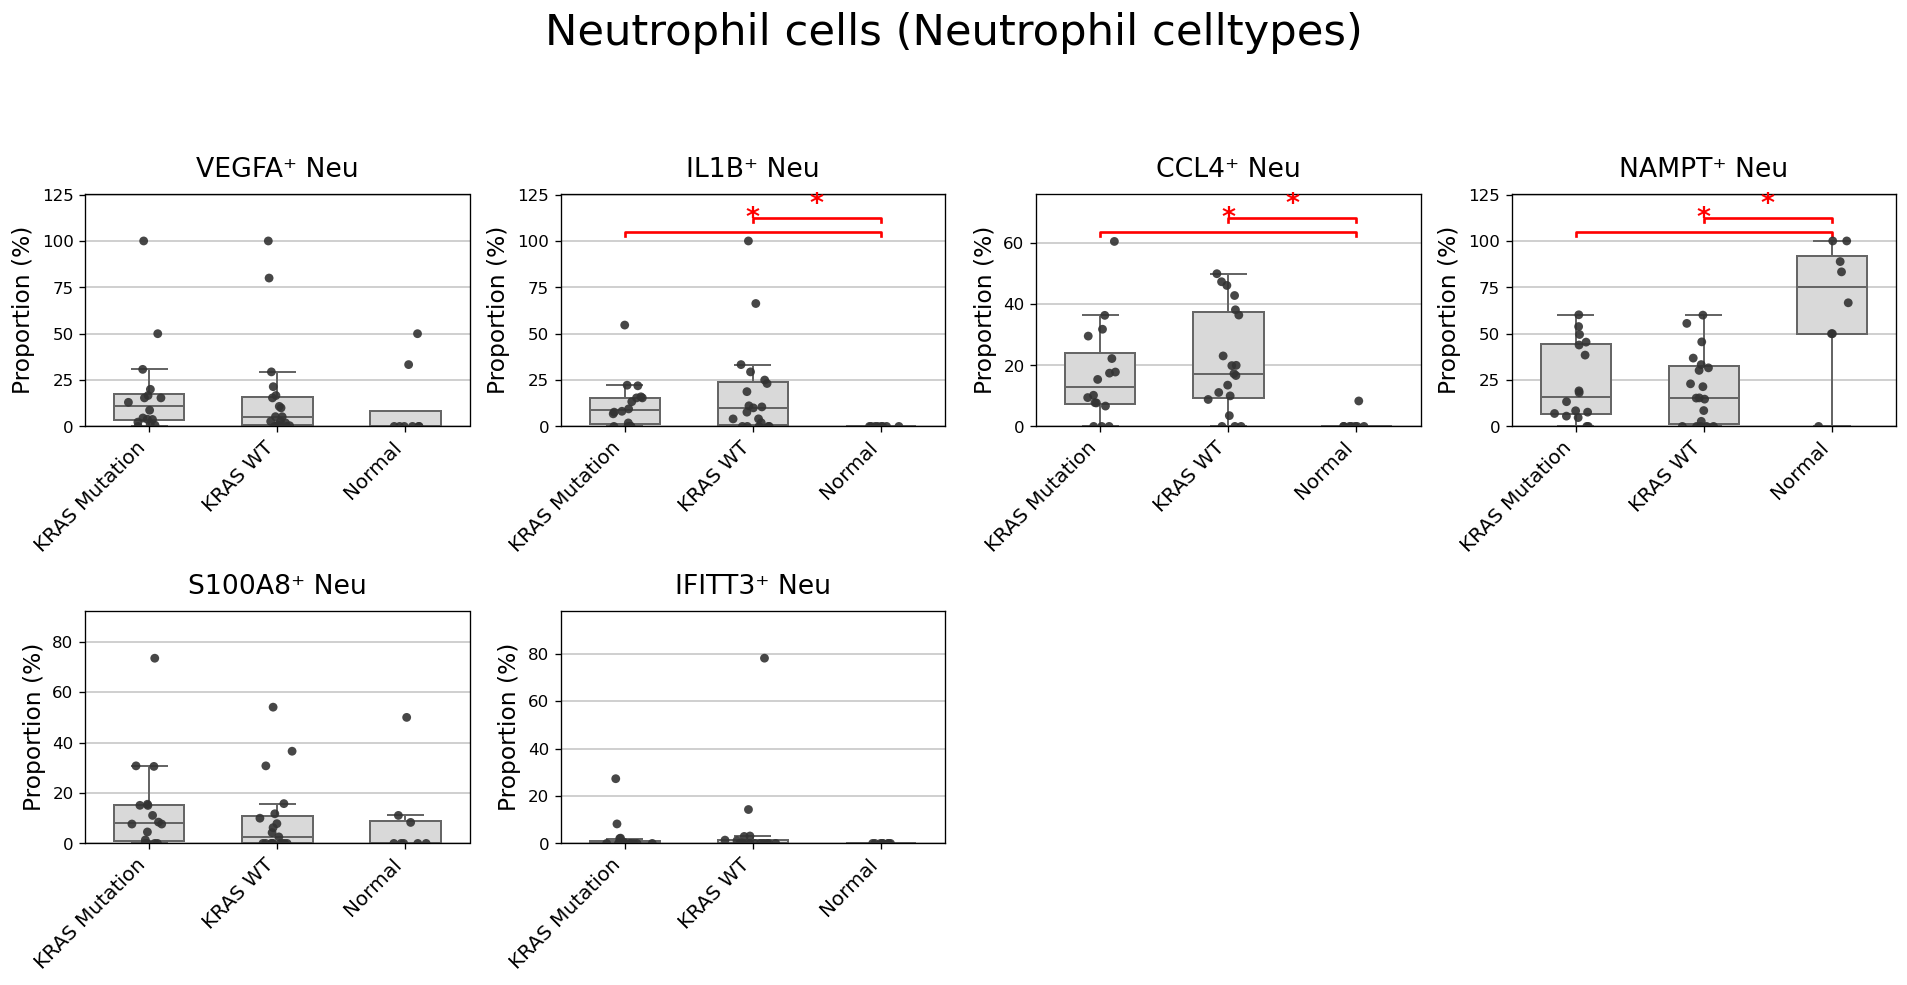

In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

sample_col  = "sample"
group_col   = "KRAS_mutation"
subtype_col = "Total celltype"

target_subtypes = ['VEGFA⁺ Neu', 'IL1B⁺ Neu','CCL4⁺ Neu','NAMPT⁺ Neu','S100A8⁺ Neu','IFITT3⁺ Neu']

group_order = ["KRAS Mutation", "KRAS WT", "Normal"]
show_only_sig = True

SUBPLOT_W = 4
SUBPLOT_H = 4
DPI = 120

FS_SUPTITLE = 26
FS_TITLE    = 16
FS_LABEL    = 14
FS_TICK     = 12
FS_STAR     = 16

def bh_adjust(pvals):
    pvals = np.array(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adj, 0, 1)
    return out.tolist()

def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, y, h, text, color="red", lw=1.6, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=color)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom",
            color=color, fontsize=fs, fontweight="bold")

obs = adata2.obs[[sample_col, group_col, subtype_col]].copy()
ct = (
    obs.groupby([sample_col, group_col, subtype_col], observed=True)
       .size()
       .unstack(fill_value=0)
)

ct_target = ct.reindex(columns=target_subtypes, fill_value=0)
denom_all = obs.groupby([sample_col, group_col], observed=True).size()
prop = ct_target.div(denom_all, axis=0) * 100
prop = prop.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

df = (
    prop.reset_index()
        .melt(
            id_vars=[sample_col, group_col],
            var_name="CD8_target_subtype",
            value_name="percent"
        )
)

df["percent"] = df["percent"].astype(float)
group_order = [g for g in group_order if g in df[group_col].unique()]

subtypes = target_subtypes
n_sub = len(subtypes)

ncols = min(4, n_sub)
nrows = math.ceil(n_sub / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(SUBPLOT_W * ncols, SUBPLOT_H * nrows),
    dpi=DPI,
    squeeze=False
)

rng = np.random.default_rng(0)

_global_pvals = []
_global_keys = []
_stats_cache = {}

for idx, subtype in enumerate(subtypes):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]

    d = df[df["CD8_target_subtype"] == subtype].copy()
    groups = [d.loc[d[group_col] == g, "percent"].dropna().values for g in group_order]
    positions = np.arange(1, len(group_order) + 1)

    bp = ax.boxplot(
        groups, positions=positions, widths=0.55,
        showfliers=False, patch_artist=True
    )
    for box in bp["boxes"]:
        box.set_facecolor("#d9d9d9")
        box.set_edgecolor("#666666")
        box.set_linewidth(1.2)
    for k in ["whiskers", "caps", "medians"]:
        for item in bp[k]:
            item.set_color("#666666")
            item.set_linewidth(1.2)

    for i, vals in enumerate(groups, start=1):
        x = rng.normal(loc=i, scale=0.07, size=len(vals))
        ax.scatter(x, vals, s=28, alpha=0.9, color="0.2",
                   edgecolors="none", zorder=3)

    ax.set_title(subtype, fontsize=FS_TITLE, pad=10, loc="center")
    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, rotation=45, ha="right", fontsize=FS_TICK)
    ax.set_ylabel("Proportion (%)", fontsize=FS_LABEL)

    ax.yaxis.grid(True, color="#c7c7c7", linewidth=1.0)
    ax.xaxis.grid(False)

    all_vals = np.concatenate([v for v in groups if len(v) > 0]) if any(len(v)>0 for v in groups) else np.array([0.0])
    y_max = float(np.nanmax(all_vals)) if np.isfinite(np.nanmax(all_vals)) else 0.0
    ax.set_ylim(0, max(1.0, y_max * 1.25 + 0.5))

    pairs = [(a, b) for a in range(len(group_order)) for b in range(a+1, len(group_order))]

    raw_p, ok_mask = [], []
    for a, b in pairs:
        A, B = groups[a], groups[b]
        A = A[np.isfinite(A)]
        B = B[np.isfinite(B)]
        if len(A) < 2 or len(B) < 2:
            raw_p.append(np.nan); ok_mask.append(False)
        else:
            p = stats.mannwhitneyu(A, B, alternative="two-sided").pvalue
            raw_p.append(p); ok_mask.append(True)

    _stats_cache[subtype] = {"ax": ax, "pairs": pairs, "raw_p": raw_p, "ok_mask": ok_mask}
    for pi, p in enumerate(raw_p):
        if np.isfinite(p) and ok_mask[pi]:
            _global_pvals.append(float(p))
            _global_keys.append((subtype, pi))

_global_adj_map = {}
if len(_global_pvals) > 0:
    _global_adj = bh_adjust(_global_pvals)
    _global_adj_map = {k: _global_adj[i] for i, k in enumerate(_global_keys)}

for subtype in subtypes:
    ax = _stats_cache[subtype]["ax"]
    pairs = _stats_cache[subtype]["pairs"]
    raw_p = _stats_cache[subtype]["raw_p"]
    ok_mask = _stats_cache[subtype]["ok_mask"]

    base = ax.get_ylim()[1] * 0.82
    step = ax.get_ylim()[1] * 0.06
    bar_i = 0

    for pi, (a, b) in enumerate(pairs):
        if not ok_mask[pi]:
            continue

        p_adj = _global_adj_map.get((subtype, pi), np.nan)
        star = p_to_star(p_adj)
        if show_only_sig and star == "ns":
            continue

        y = base + bar_i * step
        add_sig_bar(ax, a+1, b+1, y=y, h=step*0.25, text=star, color="red", fs=FS_STAR)
        bar_i += 1

for j in range(n_sub, nrows * ncols):
    rr, cc = divmod(j, ncols)
    fig.delaxes(axes[rr][cc])

fig.suptitle("Neutrophil cells (Neutrophil celltypes)", fontsize=FS_SUPTITLE,
             x=0.5, ha="center", y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

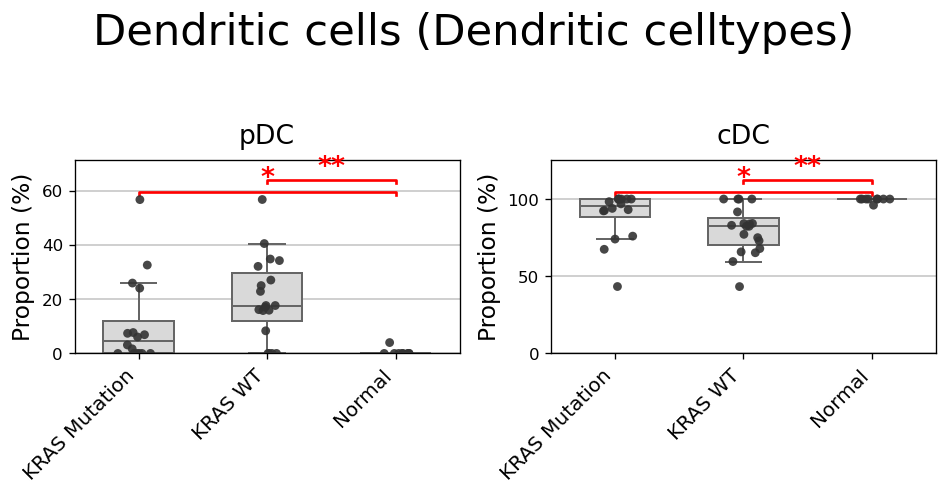

In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

sample_col  = "sample"
group_col   = "KRAS_mutation"
subtype_col = "Total celltype"

target_subtypes = ['pDC','cDC']

group_order = ["KRAS Mutation", "KRAS WT", "Normal"]
show_only_sig = True

SUBPLOT_W = 4
SUBPLOT_H = 4
DPI = 120

FS_SUPTITLE = 26
FS_TITLE    = 16
FS_LABEL    = 14
FS_TICK     = 12
FS_STAR     = 16

def bh_adjust(pvals):
    pvals = np.array(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adj, 0, 1)
    return out.tolist()

def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, y, h, text, color="red", lw=1.6, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=color)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom",
            color=color, fontsize=fs, fontweight="bold")

obs = adata3.obs[[sample_col, group_col, subtype_col]].copy()
ct = (
    obs.groupby([sample_col, group_col, subtype_col], observed=True)
       .size()
       .unstack(fill_value=0)
)

ct_target = ct.reindex(columns=target_subtypes, fill_value=0)
denom_all = obs.groupby([sample_col, group_col], observed=True).size()
prop = ct_target.div(denom_all, axis=0) * 100
prop = prop.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

df = (
    prop.reset_index()
        .melt(
            id_vars=[sample_col, group_col],
            var_name="CD8_target_subtype",
            value_name="percent"
        )
)

df["percent"] = df["percent"].astype(float)
group_order = [g for g in group_order if g in df[group_col].unique()]

subtypes = target_subtypes
n_sub = len(subtypes)

ncols = min(4, n_sub)
nrows = math.ceil(n_sub / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(SUBPLOT_W * ncols, SUBPLOT_H * nrows),
    dpi=DPI,
    squeeze=False
)

rng = np.random.default_rng(0)

_global_pvals = []
_global_keys = []
_stats_cache = {}

for idx, subtype in enumerate(subtypes):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]

    d = df[df["CD8_target_subtype"] == subtype].copy()
    groups = [d.loc[d[group_col] == g, "percent"].dropna().values for g in group_order]
    positions = np.arange(1, len(group_order) + 1)

    bp = ax.boxplot(
        groups, positions=positions, widths=0.55,
        showfliers=False, patch_artist=True
    )
    for box in bp["boxes"]:
        box.set_facecolor("#d9d9d9")
        box.set_edgecolor("#666666")
        box.set_linewidth(1.2)
    for k in ["whiskers", "caps", "medians"]:
        for item in bp[k]:
            item.set_color("#666666")
            item.set_linewidth(1.2)

    for i, vals in enumerate(groups, start=1):
        x = rng.normal(loc=i, scale=0.07, size=len(vals))
        ax.scatter(x, vals, s=28, alpha=0.9, color="0.2",
                   edgecolors="none", zorder=3)

    ax.set_title(subtype, fontsize=FS_TITLE, pad=10, loc="center")
    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, rotation=45, ha="right", fontsize=FS_TICK)
    ax.set_ylabel("Proportion (%)", fontsize=FS_LABEL)

    ax.yaxis.grid(True, color="#c7c7c7", linewidth=1.0)
    ax.xaxis.grid(False)

    all_vals = np.concatenate([v for v in groups if len(v) > 0]) if any(len(v)>0 for v in groups) else np.array([0.0])
    y_max = float(np.nanmax(all_vals)) if np.isfinite(np.nanmax(all_vals)) else 0.0
    ax.set_ylim(0, max(1.0, y_max * 1.25 + 0.5))

    pairs = [(a, b) for a in range(len(group_order)) for b in range(a+1, len(group_order))]

    raw_p, ok_mask = [], []
    for a, b in pairs:
        A, B = groups[a], groups[b]
        A = A[np.isfinite(A)]
        B = B[np.isfinite(B)]
        if len(A) < 2 or len(B) < 2:
            raw_p.append(np.nan); ok_mask.append(False)
        else:
            p = stats.mannwhitneyu(A, B, alternative="two-sided").pvalue
            raw_p.append(p); ok_mask.append(True)

    _stats_cache[subtype] = {"ax": ax, "pairs": pairs, "raw_p": raw_p, "ok_mask": ok_mask}
    for pi, p in enumerate(raw_p):
        if np.isfinite(p) and ok_mask[pi]:
            _global_pvals.append(float(p))
            _global_keys.append((subtype, pi))

_global_adj_map = {}
if len(_global_pvals) > 0:
    _global_adj = bh_adjust(_global_pvals)
    _global_adj_map = {k: _global_adj[i] for i, k in enumerate(_global_keys)}

for subtype in subtypes:
    ax = _stats_cache[subtype]["ax"]
    pairs = _stats_cache[subtype]["pairs"]
    raw_p = _stats_cache[subtype]["raw_p"]
    ok_mask = _stats_cache[subtype]["ok_mask"]

    base = ax.get_ylim()[1] * 0.82
    step = ax.get_ylim()[1] * 0.06
    bar_i = 0

    for pi, (a, b) in enumerate(pairs):
        if not ok_mask[pi]:
            continue

        p_adj = _global_adj_map.get((subtype, pi), np.nan)
        star = p_to_star(p_adj)
        if show_only_sig and star == "ns":
            continue

        y = base + bar_i * step
        add_sig_bar(ax, a+1, b+1, y=y, h=step*0.25, text=star, color="red", fs=FS_STAR)
        bar_i += 1

for j in range(n_sub, nrows * ncols):
    rr, cc = divmod(j, ncols)
    fig.delaxes(axes[rr][cc])

fig.suptitle("Dendritic cells (Dendritic celltypes)", fontsize=FS_SUPTITLE,
             x=0.5, ha="center", y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# RAS (KRAS + NRAS) proportion

In [177]:
import scanpy as sc
adata = sc.read_h5ad("/home/Data_Drive_8TB_2/CRC_2026/KRAS_project/Cellbender_KRAS_RE/h5ad/crc_36_patients_celltype_annotation_260121.h5ad")

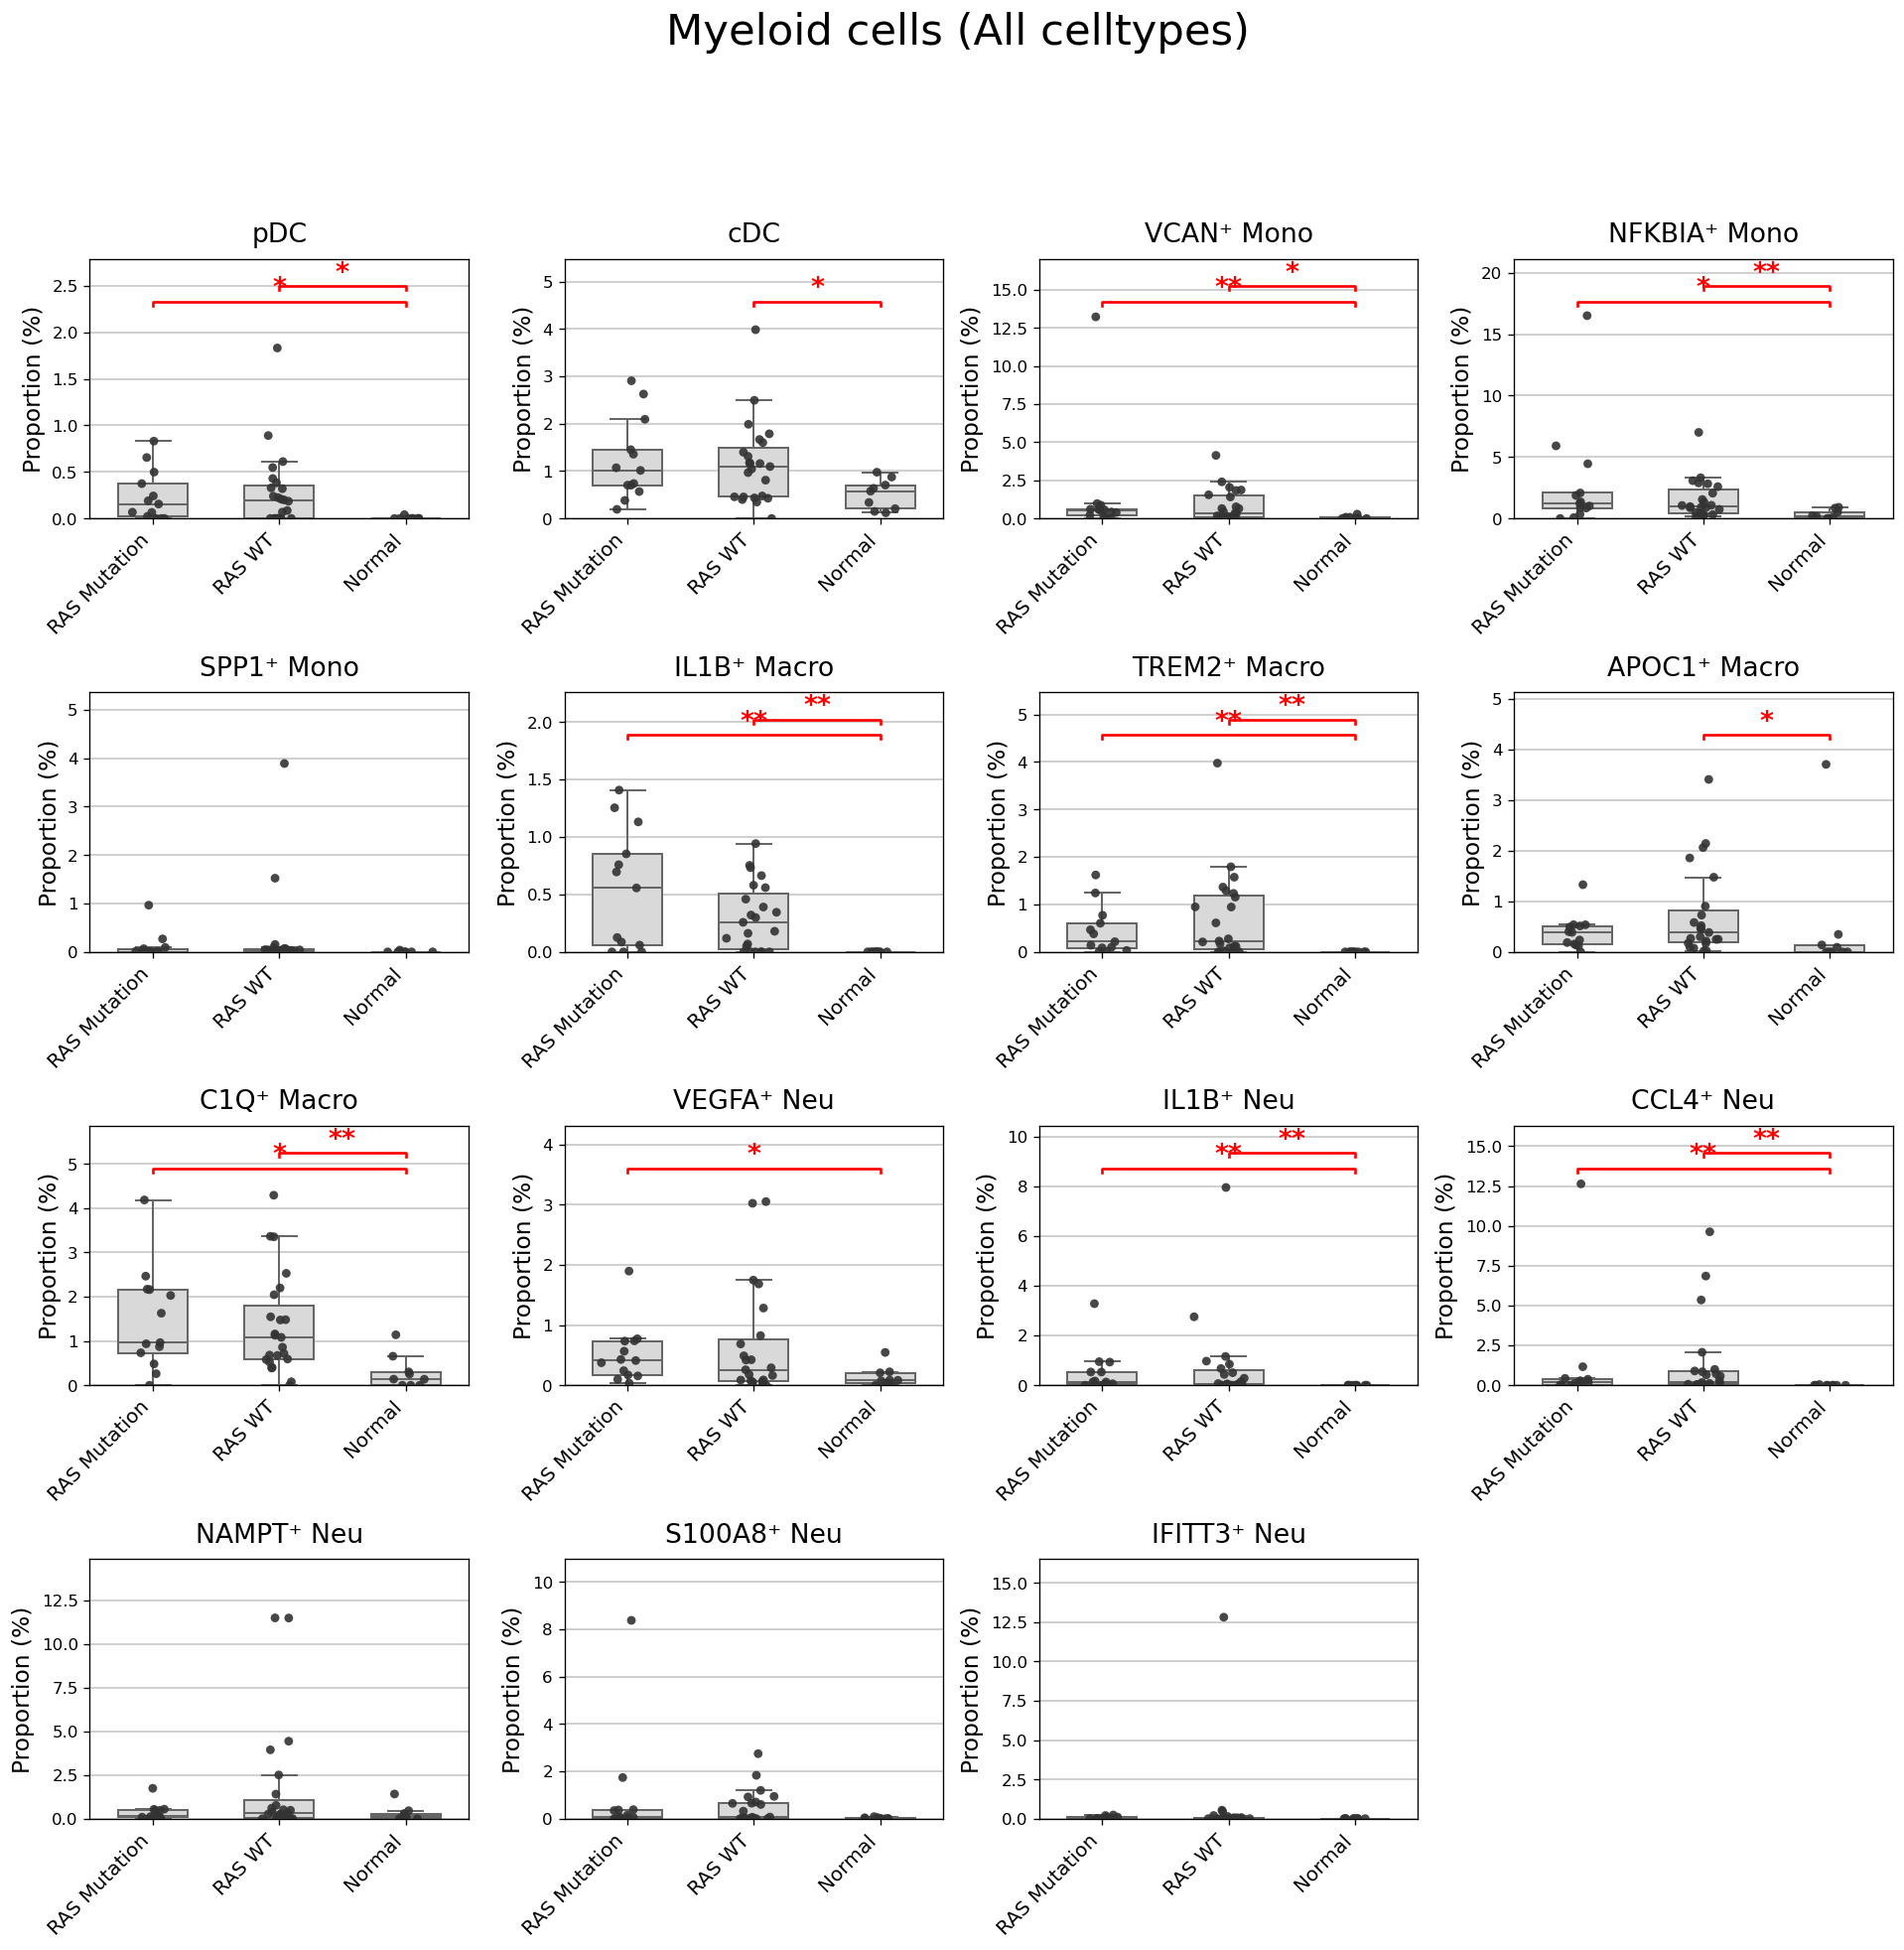

In [181]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

sample_col  = "sample"
group_col   = "RAS_mutation"
subtype_col = "Total celltype"

target_subtypes = ['pDC', 'cDC',
 'VCAN⁺ Mono', 'NFKBIA⁺ Mono','SPP1⁺ Mono', 
 'IL1B⁺ Macro', 'TREM2⁺ Macro','APOC1⁺ Macro', 'C1Q⁺ Macro',
 'VEGFA⁺ Neu', 'IL1B⁺ Neu','CCL4⁺ Neu','NAMPT⁺ Neu','S100A8⁺ Neu','IFITT3⁺ Neu']

group_order = ["RAS Mutation", "RAS WT", "Normal"]
show_only_sig = True

SUBPLOT_W = 4
SUBPLOT_H = 4
DPI = 120

FS_SUPTITLE = 26
FS_TITLE    = 16
FS_LABEL    = 14
FS_TICK     = 12
FS_STAR     = 16

def bh_adjust(pvals):
    pvals = np.array(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adj, 0, 1)
    return out.tolist()

def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, y, h, text, color="red", lw=1.6, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=color)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom",
            color=color, fontsize=fs, fontweight="bold")

obs = adata.obs[[sample_col, group_col, subtype_col]].copy()
ct = (
    obs.groupby([sample_col, group_col, subtype_col], observed=True)
       .size()
       .unstack(fill_value=0)
)

ct_target = ct.reindex(columns=target_subtypes, fill_value=0)
denom_all = obs.groupby([sample_col, group_col], observed=True).size()
prop = ct_target.div(denom_all, axis=0) * 100
prop = prop.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

df = (
    prop.reset_index()
        .melt(
            id_vars=[sample_col, group_col],
            var_name="CD8_target_subtype",
            value_name="percent"
        )
)

df["percent"] = df["percent"].astype(float)
group_order = [g for g in group_order if g in df[group_col].unique()]

subtypes = target_subtypes
n_sub = len(subtypes)

ncols = min(4, n_sub)
nrows = math.ceil(n_sub / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(SUBPLOT_W * ncols, SUBPLOT_H * nrows),
    dpi=DPI,
    squeeze=False
)

rng = np.random.default_rng(0)

_global_pvals = []
_global_keys = []
_stats_cache = {}

for idx, subtype in enumerate(subtypes):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]

    d = df[df["CD8_target_subtype"] == subtype].copy()
    groups = [d.loc[d[group_col] == g, "percent"].dropna().values for g in group_order]
    positions = np.arange(1, len(group_order) + 1)

    bp = ax.boxplot(
        groups, positions=positions, widths=0.55,
        showfliers=False, patch_artist=True
    )
    for box in bp["boxes"]:
        box.set_facecolor("#d9d9d9")
        box.set_edgecolor("#666666")
        box.set_linewidth(1.2)
    for k in ["whiskers", "caps", "medians"]:
        for item in bp[k]:
            item.set_color("#666666")
            item.set_linewidth(1.2)

    for i, vals in enumerate(groups, start=1):
        x = rng.normal(loc=i, scale=0.07, size=len(vals))
        ax.scatter(x, vals, s=28, alpha=0.9, color="0.2",
                   edgecolors="none", zorder=3)

    ax.set_title(subtype, fontsize=FS_TITLE, pad=10, loc="center")
    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, rotation=45, ha="right", fontsize=FS_TICK)
    ax.set_ylabel("Proportion (%)", fontsize=FS_LABEL)

    ax.yaxis.grid(True, color="#c7c7c7", linewidth=1.0)
    ax.xaxis.grid(False)

    all_vals = np.concatenate([v for v in groups if len(v) > 0]) if any(len(v)>0 for v in groups) else np.array([0.0])
    y_max = float(np.nanmax(all_vals)) if np.isfinite(np.nanmax(all_vals)) else 0.0
    ax.set_ylim(0, max(1.0, y_max * 1.25 + 0.5))

    pairs = [(a, b) for a in range(len(group_order)) for b in range(a+1, len(group_order))]

    raw_p, ok_mask = [], []
    for a, b in pairs:
        A, B = groups[a], groups[b]
        A = A[np.isfinite(A)]
        B = B[np.isfinite(B)]
        if len(A) < 2 or len(B) < 2:
            raw_p.append(np.nan); ok_mask.append(False)
        else:
            p = stats.mannwhitneyu(A, B, alternative="two-sided").pvalue
            raw_p.append(p); ok_mask.append(True)

    _stats_cache[subtype] = {"ax": ax, "pairs": pairs, "raw_p": raw_p, "ok_mask": ok_mask}
    for pi, p in enumerate(raw_p):
        if np.isfinite(p) and ok_mask[pi]:
            _global_pvals.append(float(p))
            _global_keys.append((subtype, pi))

_global_adj_map = {}
if len(_global_pvals) > 0:
    _global_adj = bh_adjust(_global_pvals)
    _global_adj_map = {k: _global_adj[i] for i, k in enumerate(_global_keys)}

for subtype in subtypes:
    ax = _stats_cache[subtype]["ax"]
    pairs = _stats_cache[subtype]["pairs"]
    raw_p = _stats_cache[subtype]["raw_p"]
    ok_mask = _stats_cache[subtype]["ok_mask"]

    base = ax.get_ylim()[1] * 0.82
    step = ax.get_ylim()[1] * 0.06
    bar_i = 0

    for pi, (a, b) in enumerate(pairs):
        if not ok_mask[pi]:
            continue

        p_adj = _global_adj_map.get((subtype, pi), np.nan)
        star = p_to_star(p_adj)
        if show_only_sig and star == "ns":
            continue

        y = base + bar_i * step
        add_sig_bar(ax, a+1, b+1, y=y, h=step*0.25, text=star, color="red", fs=FS_STAR)
        bar_i += 1

for j in range(n_sub, nrows * ncols):
    rr, cc = divmod(j, ncols)
    fig.delaxes(axes[rr][cc])

fig.suptitle("Myeloid cells (All celltypes)", fontsize=FS_SUPTITLE,
             x=0.5, ha="center", y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [182]:
selected = ['Myeloid', 'NK/T', 'Neutrophil']

adata = adata[adata.obs['cell_type'].isin(selected)].copy()

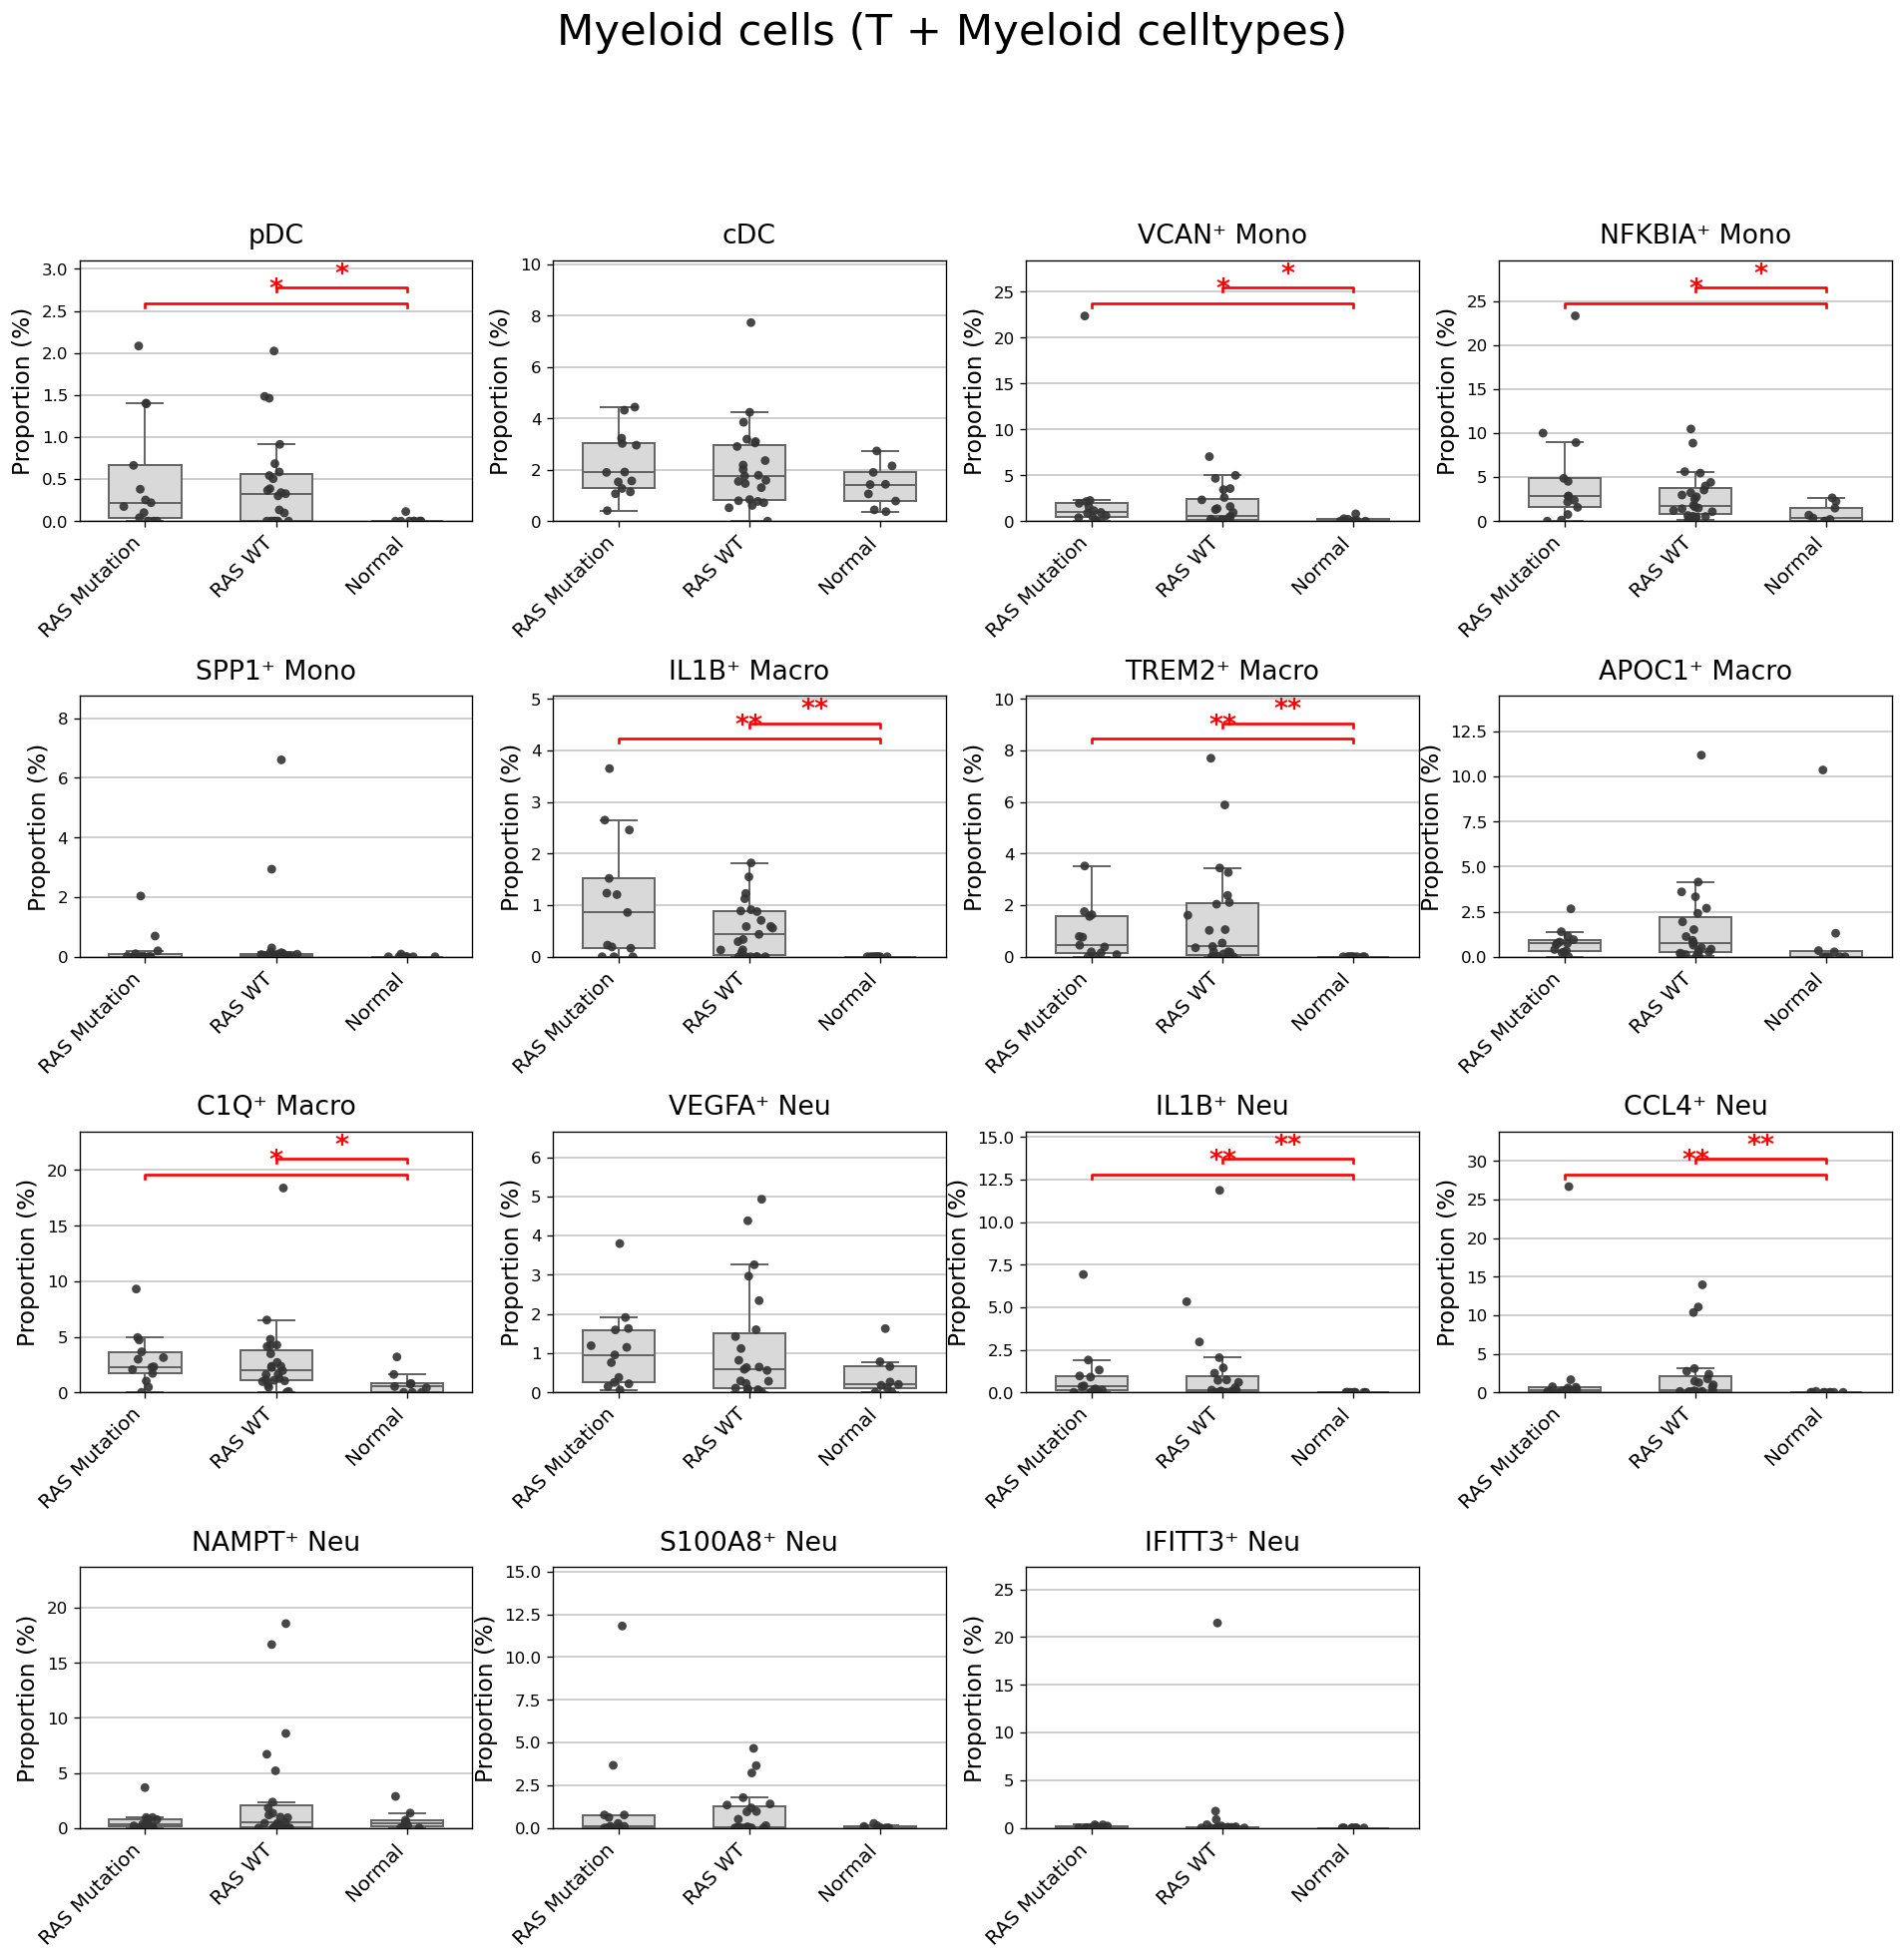

In [183]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

sample_col  = "sample"
group_col   = "RAS_mutation"
subtype_col = "Total celltype"

target_subtypes = ['pDC', 'cDC',
 'VCAN⁺ Mono', 'NFKBIA⁺ Mono','SPP1⁺ Mono', 
 'IL1B⁺ Macro', 'TREM2⁺ Macro','APOC1⁺ Macro', 'C1Q⁺ Macro',
 'VEGFA⁺ Neu', 'IL1B⁺ Neu','CCL4⁺ Neu','NAMPT⁺ Neu','S100A8⁺ Neu','IFITT3⁺ Neu']

group_order = ["RAS Mutation", "RAS WT", "Normal"]
show_only_sig = True

SUBPLOT_W = 4
SUBPLOT_H = 4
DPI = 120

FS_SUPTITLE = 26
FS_TITLE    = 16
FS_LABEL    = 14
FS_TICK     = 12
FS_STAR     = 16

def bh_adjust(pvals):
    pvals = np.array(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adj, 0, 1)
    return out.tolist()

def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, y, h, text, color="red", lw=1.6, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=color)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom",
            color=color, fontsize=fs, fontweight="bold")

obs = adata.obs[[sample_col, group_col, subtype_col]].copy()
ct = (
    obs.groupby([sample_col, group_col, subtype_col], observed=True)
       .size()
       .unstack(fill_value=0)
)

ct_target = ct.reindex(columns=target_subtypes, fill_value=0)
denom_all = obs.groupby([sample_col, group_col], observed=True).size()
prop = ct_target.div(denom_all, axis=0) * 100
prop = prop.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

df = (
    prop.reset_index()
        .melt(
            id_vars=[sample_col, group_col],
            var_name="CD8_target_subtype",
            value_name="percent"
        )
)

df["percent"] = df["percent"].astype(float)
group_order = [g for g in group_order if g in df[group_col].unique()]

subtypes = target_subtypes
n_sub = len(subtypes)

ncols = min(4, n_sub)
nrows = math.ceil(n_sub / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(SUBPLOT_W * ncols, SUBPLOT_H * nrows),
    dpi=DPI,
    squeeze=False
)

rng = np.random.default_rng(0)

_global_pvals = []
_global_keys = []
_stats_cache = {}

for idx, subtype in enumerate(subtypes):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]

    d = df[df["CD8_target_subtype"] == subtype].copy()
    groups = [d.loc[d[group_col] == g, "percent"].dropna().values for g in group_order]
    positions = np.arange(1, len(group_order) + 1)

    bp = ax.boxplot(
        groups, positions=positions, widths=0.55,
        showfliers=False, patch_artist=True
    )
    for box in bp["boxes"]:
        box.set_facecolor("#d9d9d9")
        box.set_edgecolor("#666666")
        box.set_linewidth(1.2)
    for k in ["whiskers", "caps", "medians"]:
        for item in bp[k]:
            item.set_color("#666666")
            item.set_linewidth(1.2)

    for i, vals in enumerate(groups, start=1):
        x = rng.normal(loc=i, scale=0.07, size=len(vals))
        ax.scatter(x, vals, s=28, alpha=0.9, color="0.2",
                   edgecolors="none", zorder=3)

    ax.set_title(subtype, fontsize=FS_TITLE, pad=10, loc="center")
    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, rotation=45, ha="right", fontsize=FS_TICK)
    ax.set_ylabel("Proportion (%)", fontsize=FS_LABEL)

    ax.yaxis.grid(True, color="#c7c7c7", linewidth=1.0)
    ax.xaxis.grid(False)

    all_vals = np.concatenate([v for v in groups if len(v) > 0]) if any(len(v)>0 for v in groups) else np.array([0.0])
    y_max = float(np.nanmax(all_vals)) if np.isfinite(np.nanmax(all_vals)) else 0.0
    ax.set_ylim(0, max(1.0, y_max * 1.25 + 0.5))

    pairs = [(a, b) for a in range(len(group_order)) for b in range(a+1, len(group_order))]

    raw_p, ok_mask = [], []
    for a, b in pairs:
        A, B = groups[a], groups[b]
        A = A[np.isfinite(A)]
        B = B[np.isfinite(B)]
        if len(A) < 2 or len(B) < 2:
            raw_p.append(np.nan); ok_mask.append(False)
        else:
            p = stats.mannwhitneyu(A, B, alternative="two-sided").pvalue
            raw_p.append(p); ok_mask.append(True)

    _stats_cache[subtype] = {"ax": ax, "pairs": pairs, "raw_p": raw_p, "ok_mask": ok_mask}
    for pi, p in enumerate(raw_p):
        if np.isfinite(p) and ok_mask[pi]:
            _global_pvals.append(float(p))
            _global_keys.append((subtype, pi))

_global_adj_map = {}
if len(_global_pvals) > 0:
    _global_adj = bh_adjust(_global_pvals)
    _global_adj_map = {k: _global_adj[i] for i, k in enumerate(_global_keys)}

for subtype in subtypes:
    ax = _stats_cache[subtype]["ax"]
    pairs = _stats_cache[subtype]["pairs"]
    raw_p = _stats_cache[subtype]["raw_p"]
    ok_mask = _stats_cache[subtype]["ok_mask"]

    base = ax.get_ylim()[1] * 0.82
    step = ax.get_ylim()[1] * 0.06
    bar_i = 0

    for pi, (a, b) in enumerate(pairs):
        if not ok_mask[pi]:
            continue

        p_adj = _global_adj_map.get((subtype, pi), np.nan)
        star = p_to_star(p_adj)
        if show_only_sig and star == "ns":
            continue

        y = base + bar_i * step
        add_sig_bar(ax, a+1, b+1, y=y, h=step*0.25, text=star, color="red", fs=FS_STAR)
        bar_i += 1

for j in range(n_sub, nrows * ncols):
    rr, cc = divmod(j, ncols)
    fig.delaxes(axes[rr][cc])

fig.suptitle("Myeloid cells (T + Myeloid celltypes)", fontsize=FS_SUPTITLE,
             x=0.5, ha="center", y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [184]:
selected = ['Myeloid','Neutrophil']

adata = adata[adata.obs['cell_type'].isin(selected)].copy()

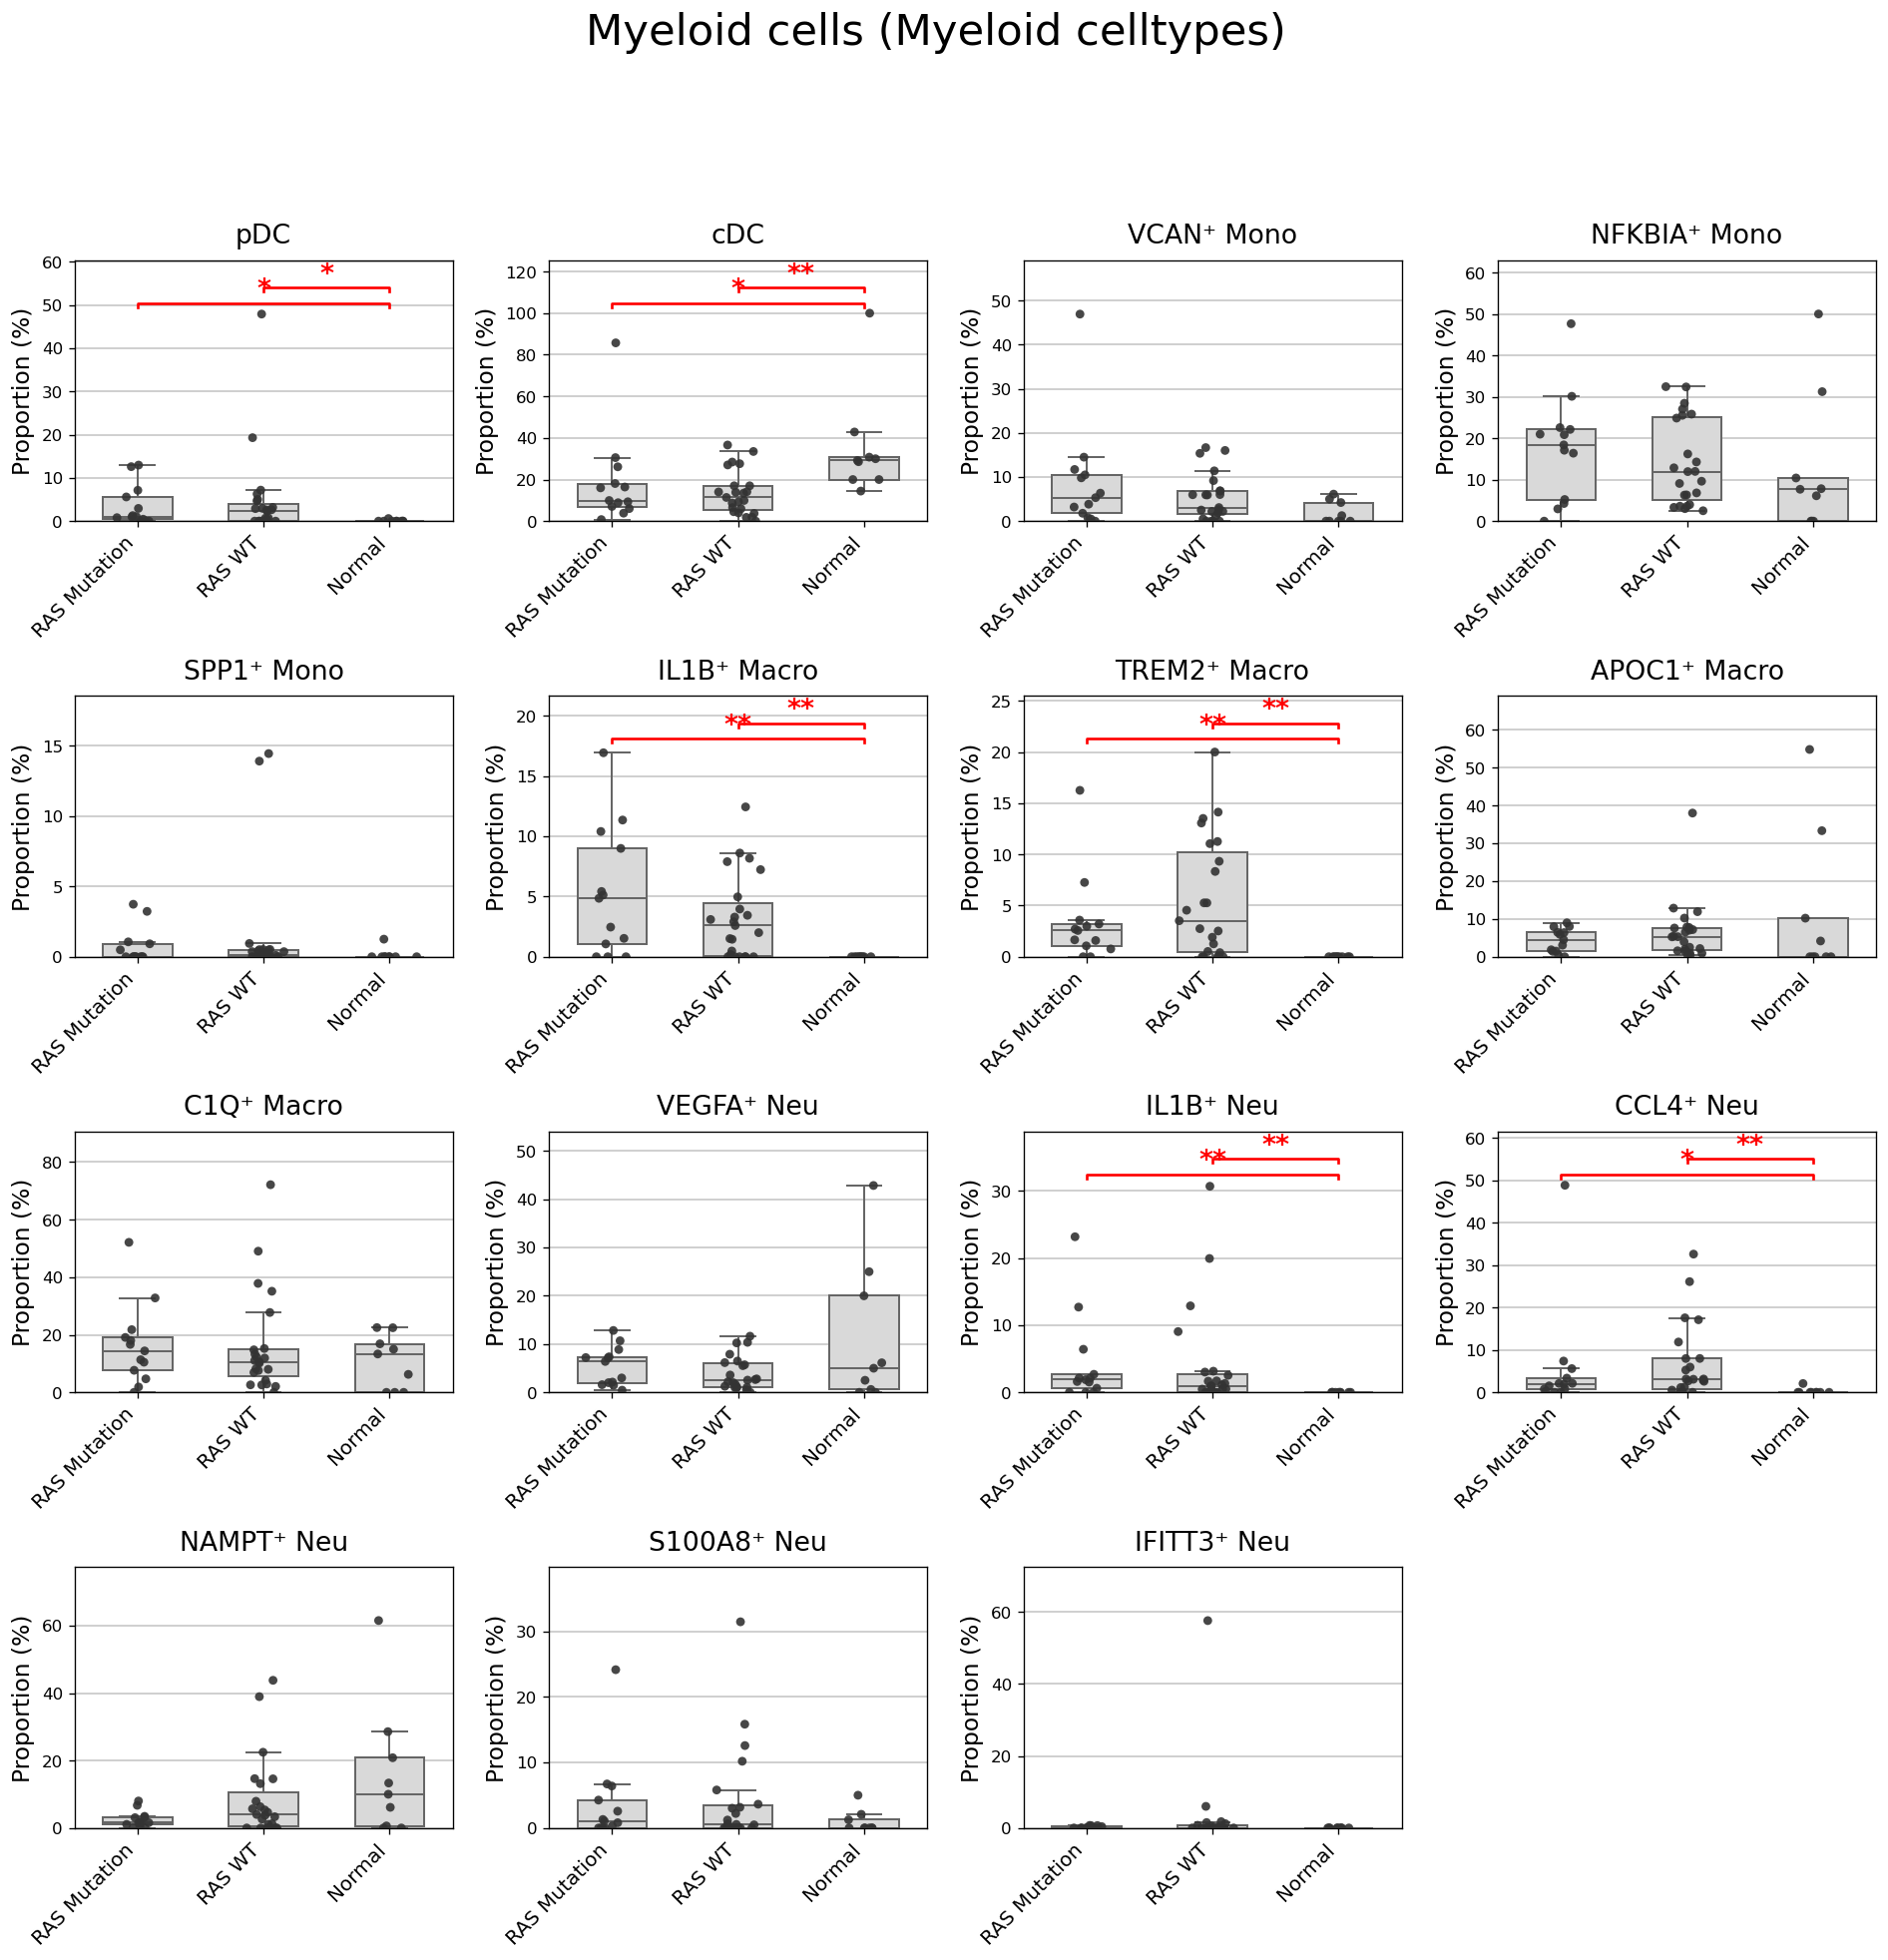

In [185]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

sample_col  = "sample"
group_col   = "RAS_mutation"
subtype_col = "Total celltype"

target_subtypes = ['pDC', 'cDC',
 'VCAN⁺ Mono', 'NFKBIA⁺ Mono','SPP1⁺ Mono', 
 'IL1B⁺ Macro', 'TREM2⁺ Macro','APOC1⁺ Macro', 'C1Q⁺ Macro',
 'VEGFA⁺ Neu', 'IL1B⁺ Neu','CCL4⁺ Neu','NAMPT⁺ Neu','S100A8⁺ Neu','IFITT3⁺ Neu']

group_order = ["RAS Mutation", "RAS WT", "Normal"]
show_only_sig = True

SUBPLOT_W = 4
SUBPLOT_H = 4
DPI = 120

FS_SUPTITLE = 26
FS_TITLE    = 16
FS_LABEL    = 14
FS_TICK     = 12
FS_STAR     = 16

def bh_adjust(pvals):
    pvals = np.array(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adj, 0, 1)
    return out.tolist()

def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, y, h, text, color="red", lw=1.6, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=color)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom",
            color=color, fontsize=fs, fontweight="bold")

obs = adata.obs[[sample_col, group_col, subtype_col]].copy()
ct = (
    obs.groupby([sample_col, group_col, subtype_col], observed=True)
       .size()
       .unstack(fill_value=0)
)

ct_target = ct.reindex(columns=target_subtypes, fill_value=0)
denom_all = obs.groupby([sample_col, group_col], observed=True).size()
prop = ct_target.div(denom_all, axis=0) * 100
prop = prop.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

df = (
    prop.reset_index()
        .melt(
            id_vars=[sample_col, group_col],
            var_name="CD8_target_subtype",
            value_name="percent"
        )
)

df["percent"] = df["percent"].astype(float)
group_order = [g for g in group_order if g in df[group_col].unique()]

subtypes = target_subtypes
n_sub = len(subtypes)

ncols = min(4, n_sub)
nrows = math.ceil(n_sub / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(SUBPLOT_W * ncols, SUBPLOT_H * nrows),
    dpi=DPI,
    squeeze=False
)

rng = np.random.default_rng(0)

_global_pvals = []
_global_keys = []
_stats_cache = {}

for idx, subtype in enumerate(subtypes):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]

    d = df[df["CD8_target_subtype"] == subtype].copy()
    groups = [d.loc[d[group_col] == g, "percent"].dropna().values for g in group_order]
    positions = np.arange(1, len(group_order) + 1)

    bp = ax.boxplot(
        groups, positions=positions, widths=0.55,
        showfliers=False, patch_artist=True
    )
    for box in bp["boxes"]:
        box.set_facecolor("#d9d9d9")
        box.set_edgecolor("#666666")
        box.set_linewidth(1.2)
    for k in ["whiskers", "caps", "medians"]:
        for item in bp[k]:
            item.set_color("#666666")
            item.set_linewidth(1.2)

    for i, vals in enumerate(groups, start=1):
        x = rng.normal(loc=i, scale=0.07, size=len(vals))
        ax.scatter(x, vals, s=28, alpha=0.9, color="0.2",
                   edgecolors="none", zorder=3)

    ax.set_title(subtype, fontsize=FS_TITLE, pad=10, loc="center")
    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, rotation=45, ha="right", fontsize=FS_TICK)
    ax.set_ylabel("Proportion (%)", fontsize=FS_LABEL)

    ax.yaxis.grid(True, color="#c7c7c7", linewidth=1.0)
    ax.xaxis.grid(False)

    all_vals = np.concatenate([v for v in groups if len(v) > 0]) if any(len(v)>0 for v in groups) else np.array([0.0])
    y_max = float(np.nanmax(all_vals)) if np.isfinite(np.nanmax(all_vals)) else 0.0
    ax.set_ylim(0, max(1.0, y_max * 1.25 + 0.5))

    pairs = [(a, b) for a in range(len(group_order)) for b in range(a+1, len(group_order))]

    raw_p, ok_mask = [], []
    for a, b in pairs:
        A, B = groups[a], groups[b]
        A = A[np.isfinite(A)]
        B = B[np.isfinite(B)]
        if len(A) < 2 or len(B) < 2:
            raw_p.append(np.nan); ok_mask.append(False)
        else:
            p = stats.mannwhitneyu(A, B, alternative="two-sided").pvalue
            raw_p.append(p); ok_mask.append(True)

    _stats_cache[subtype] = {"ax": ax, "pairs": pairs, "raw_p": raw_p, "ok_mask": ok_mask}
    for pi, p in enumerate(raw_p):
        if np.isfinite(p) and ok_mask[pi]:
            _global_pvals.append(float(p))
            _global_keys.append((subtype, pi))

_global_adj_map = {}
if len(_global_pvals) > 0:
    _global_adj = bh_adjust(_global_pvals)
    _global_adj_map = {k: _global_adj[i] for i, k in enumerate(_global_keys)}

for subtype in subtypes:
    ax = _stats_cache[subtype]["ax"]
    pairs = _stats_cache[subtype]["pairs"]
    raw_p = _stats_cache[subtype]["raw_p"]
    ok_mask = _stats_cache[subtype]["ok_mask"]

    base = ax.get_ylim()[1] * 0.82
    step = ax.get_ylim()[1] * 0.06
    bar_i = 0

    for pi, (a, b) in enumerate(pairs):
        if not ok_mask[pi]:
            continue

        p_adj = _global_adj_map.get((subtype, pi), np.nan)
        star = p_to_star(p_adj)
        if show_only_sig and star == "ns":
            continue

        y = base + bar_i * step
        add_sig_bar(ax, a+1, b+1, y=y, h=step*0.25, text=star, color="red", fs=FS_STAR)
        bar_i += 1

for j in range(n_sub, nrows * ncols):
    rr, cc = divmod(j, ncols)
    fig.delaxes(axes[rr][cc])

fig.suptitle("Myeloid cells (Myeloid celltypes)", fontsize=FS_SUPTITLE,
             x=0.5, ha="center", y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [186]:
selected1 = ['Myeloid']
selected2 = ['Neutrophil']
selected3 = ['pDC','cDC']

adata1 = adata[adata.obs['cell_type'].isin(selected1)].copy()
adata2 = adata[adata.obs['cell_type'].isin(selected2)].copy()
adata3 = adata[adata.obs['Total celltype'].isin(selected3)].copy()

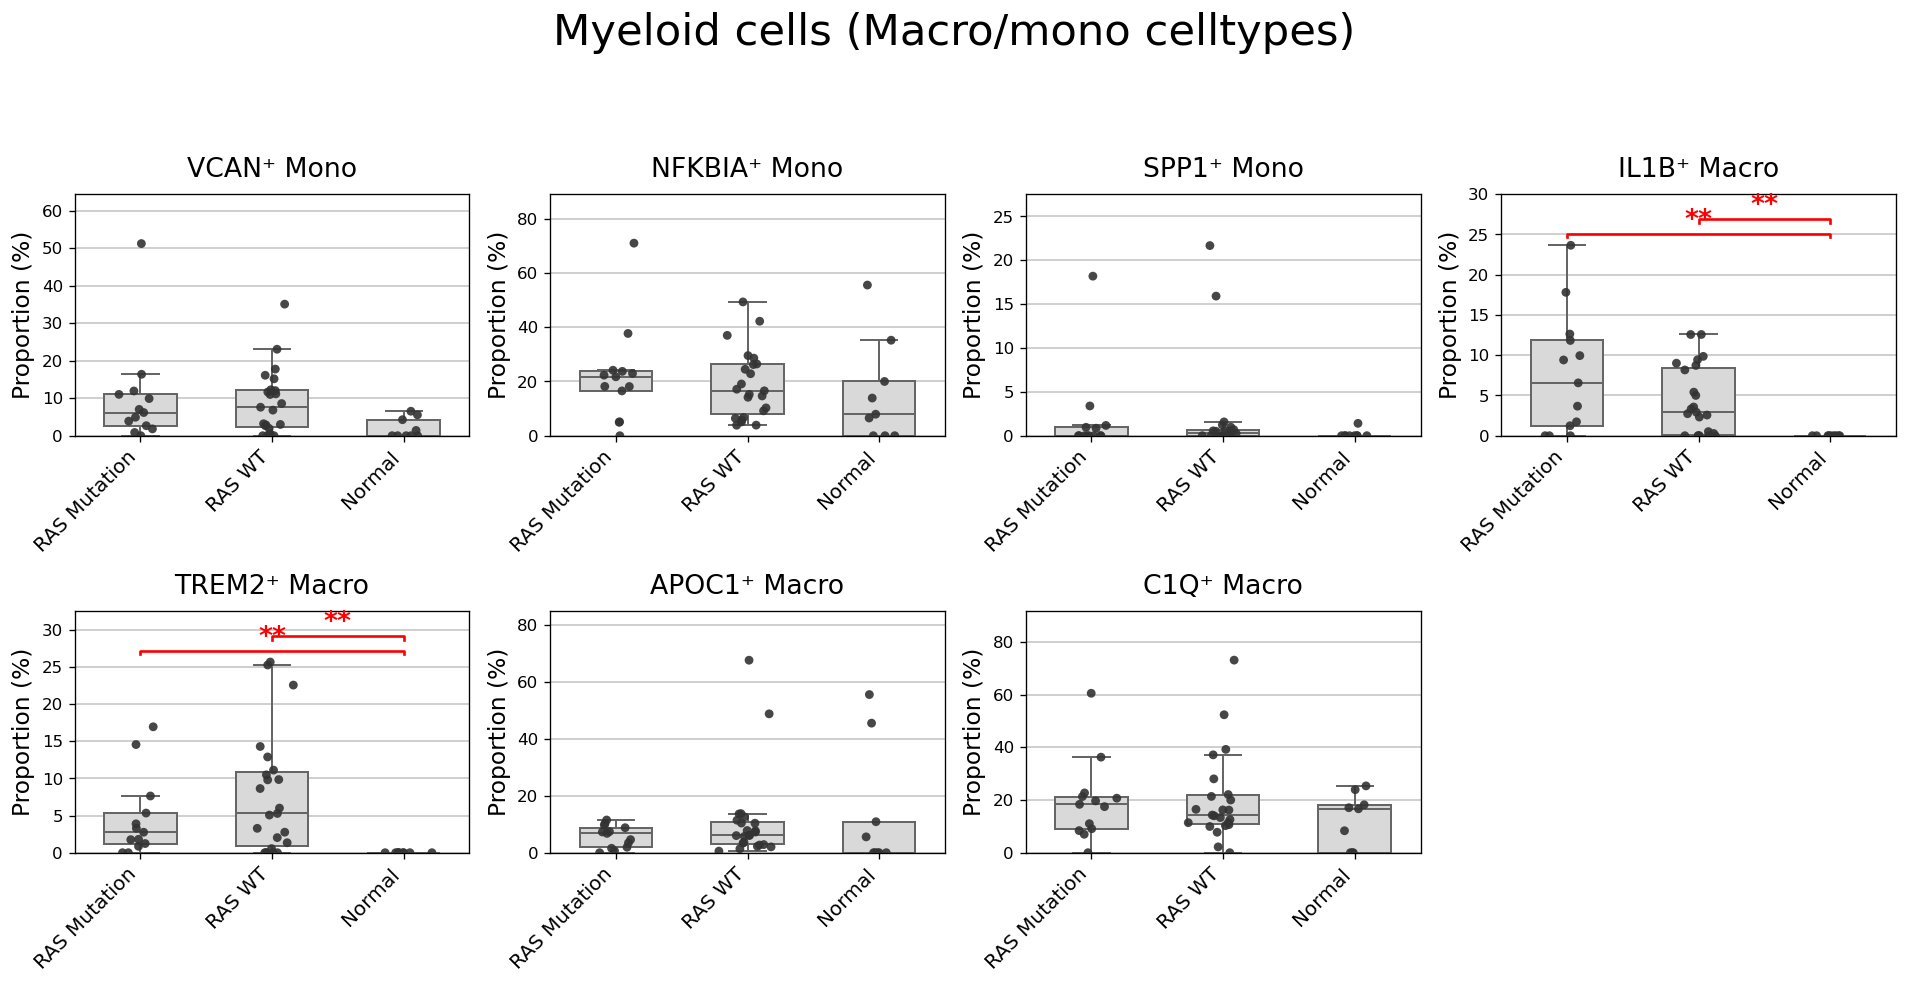

In [187]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

sample_col  = "sample"
group_col   = "RAS_mutation"
subtype_col = "Total celltype"

target_subtypes = [
 'VCAN⁺ Mono', 'NFKBIA⁺ Mono','SPP1⁺ Mono', 
 'IL1B⁺ Macro', 'TREM2⁺ Macro','APOC1⁺ Macro', 'C1Q⁺ Macro']

group_order = ["RAS Mutation", "RAS WT", "Normal"]
show_only_sig = True

SUBPLOT_W = 4
SUBPLOT_H = 4
DPI = 120

FS_SUPTITLE = 26
FS_TITLE    = 16
FS_LABEL    = 14
FS_TICK     = 12
FS_STAR     = 16

def bh_adjust(pvals):
    pvals = np.array(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adj, 0, 1)
    return out.tolist()

def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, y, h, text, color="red", lw=1.6, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=color)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom",
            color=color, fontsize=fs, fontweight="bold")

obs = adata1.obs[[sample_col, group_col, subtype_col]].copy()
ct = (
    obs.groupby([sample_col, group_col, subtype_col], observed=True)
       .size()
       .unstack(fill_value=0)
)

ct_target = ct.reindex(columns=target_subtypes, fill_value=0)
denom_all = obs.groupby([sample_col, group_col], observed=True).size()
prop = ct_target.div(denom_all, axis=0) * 100
prop = prop.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

df = (
    prop.reset_index()
        .melt(
            id_vars=[sample_col, group_col],
            var_name="CD8_target_subtype",
            value_name="percent"
        )
)

df["percent"] = df["percent"].astype(float)
group_order = [g for g in group_order if g in df[group_col].unique()]

subtypes = target_subtypes
n_sub = len(subtypes)

ncols = min(4, n_sub)
nrows = math.ceil(n_sub / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(SUBPLOT_W * ncols, SUBPLOT_H * nrows),
    dpi=DPI,
    squeeze=False
)

rng = np.random.default_rng(0)

_global_pvals = []
_global_keys = []
_stats_cache = {}

for idx, subtype in enumerate(subtypes):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]

    d = df[df["CD8_target_subtype"] == subtype].copy()
    groups = [d.loc[d[group_col] == g, "percent"].dropna().values for g in group_order]
    positions = np.arange(1, len(group_order) + 1)

    bp = ax.boxplot(
        groups, positions=positions, widths=0.55,
        showfliers=False, patch_artist=True
    )
    for box in bp["boxes"]:
        box.set_facecolor("#d9d9d9")
        box.set_edgecolor("#666666")
        box.set_linewidth(1.2)
    for k in ["whiskers", "caps", "medians"]:
        for item in bp[k]:
            item.set_color("#666666")
            item.set_linewidth(1.2)

    for i, vals in enumerate(groups, start=1):
        x = rng.normal(loc=i, scale=0.07, size=len(vals))
        ax.scatter(x, vals, s=28, alpha=0.9, color="0.2",
                   edgecolors="none", zorder=3)

    ax.set_title(subtype, fontsize=FS_TITLE, pad=10, loc="center")
    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, rotation=45, ha="right", fontsize=FS_TICK)
    ax.set_ylabel("Proportion (%)", fontsize=FS_LABEL)

    ax.yaxis.grid(True, color="#c7c7c7", linewidth=1.0)
    ax.xaxis.grid(False)

    all_vals = np.concatenate([v for v in groups if len(v) > 0]) if any(len(v)>0 for v in groups) else np.array([0.0])
    y_max = float(np.nanmax(all_vals)) if np.isfinite(np.nanmax(all_vals)) else 0.0
    ax.set_ylim(0, max(1.0, y_max * 1.25 + 0.5))

    pairs = [(a, b) for a in range(len(group_order)) for b in range(a+1, len(group_order))]

    raw_p, ok_mask = [], []
    for a, b in pairs:
        A, B = groups[a], groups[b]
        A = A[np.isfinite(A)]
        B = B[np.isfinite(B)]
        if len(A) < 2 or len(B) < 2:
            raw_p.append(np.nan); ok_mask.append(False)
        else:
            p = stats.mannwhitneyu(A, B, alternative="two-sided").pvalue
            raw_p.append(p); ok_mask.append(True)

    _stats_cache[subtype] = {"ax": ax, "pairs": pairs, "raw_p": raw_p, "ok_mask": ok_mask}
    for pi, p in enumerate(raw_p):
        if np.isfinite(p) and ok_mask[pi]:
            _global_pvals.append(float(p))
            _global_keys.append((subtype, pi))

_global_adj_map = {}
if len(_global_pvals) > 0:
    _global_adj = bh_adjust(_global_pvals)
    _global_adj_map = {k: _global_adj[i] for i, k in enumerate(_global_keys)}

for subtype in subtypes:
    ax = _stats_cache[subtype]["ax"]
    pairs = _stats_cache[subtype]["pairs"]
    raw_p = _stats_cache[subtype]["raw_p"]
    ok_mask = _stats_cache[subtype]["ok_mask"]

    base = ax.get_ylim()[1] * 0.82
    step = ax.get_ylim()[1] * 0.06
    bar_i = 0

    for pi, (a, b) in enumerate(pairs):
        if not ok_mask[pi]:
            continue

        p_adj = _global_adj_map.get((subtype, pi), np.nan)
        star = p_to_star(p_adj)
        if show_only_sig and star == "ns":
            continue

        y = base + bar_i * step
        add_sig_bar(ax, a+1, b+1, y=y, h=step*0.25, text=star, color="red", fs=FS_STAR)
        bar_i += 1

for j in range(n_sub, nrows * ncols):
    rr, cc = divmod(j, ncols)
    fig.delaxes(axes[rr][cc])

fig.suptitle("Myeloid cells (Macro/mono celltypes)", fontsize=FS_SUPTITLE,
             x=0.5, ha="center", y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


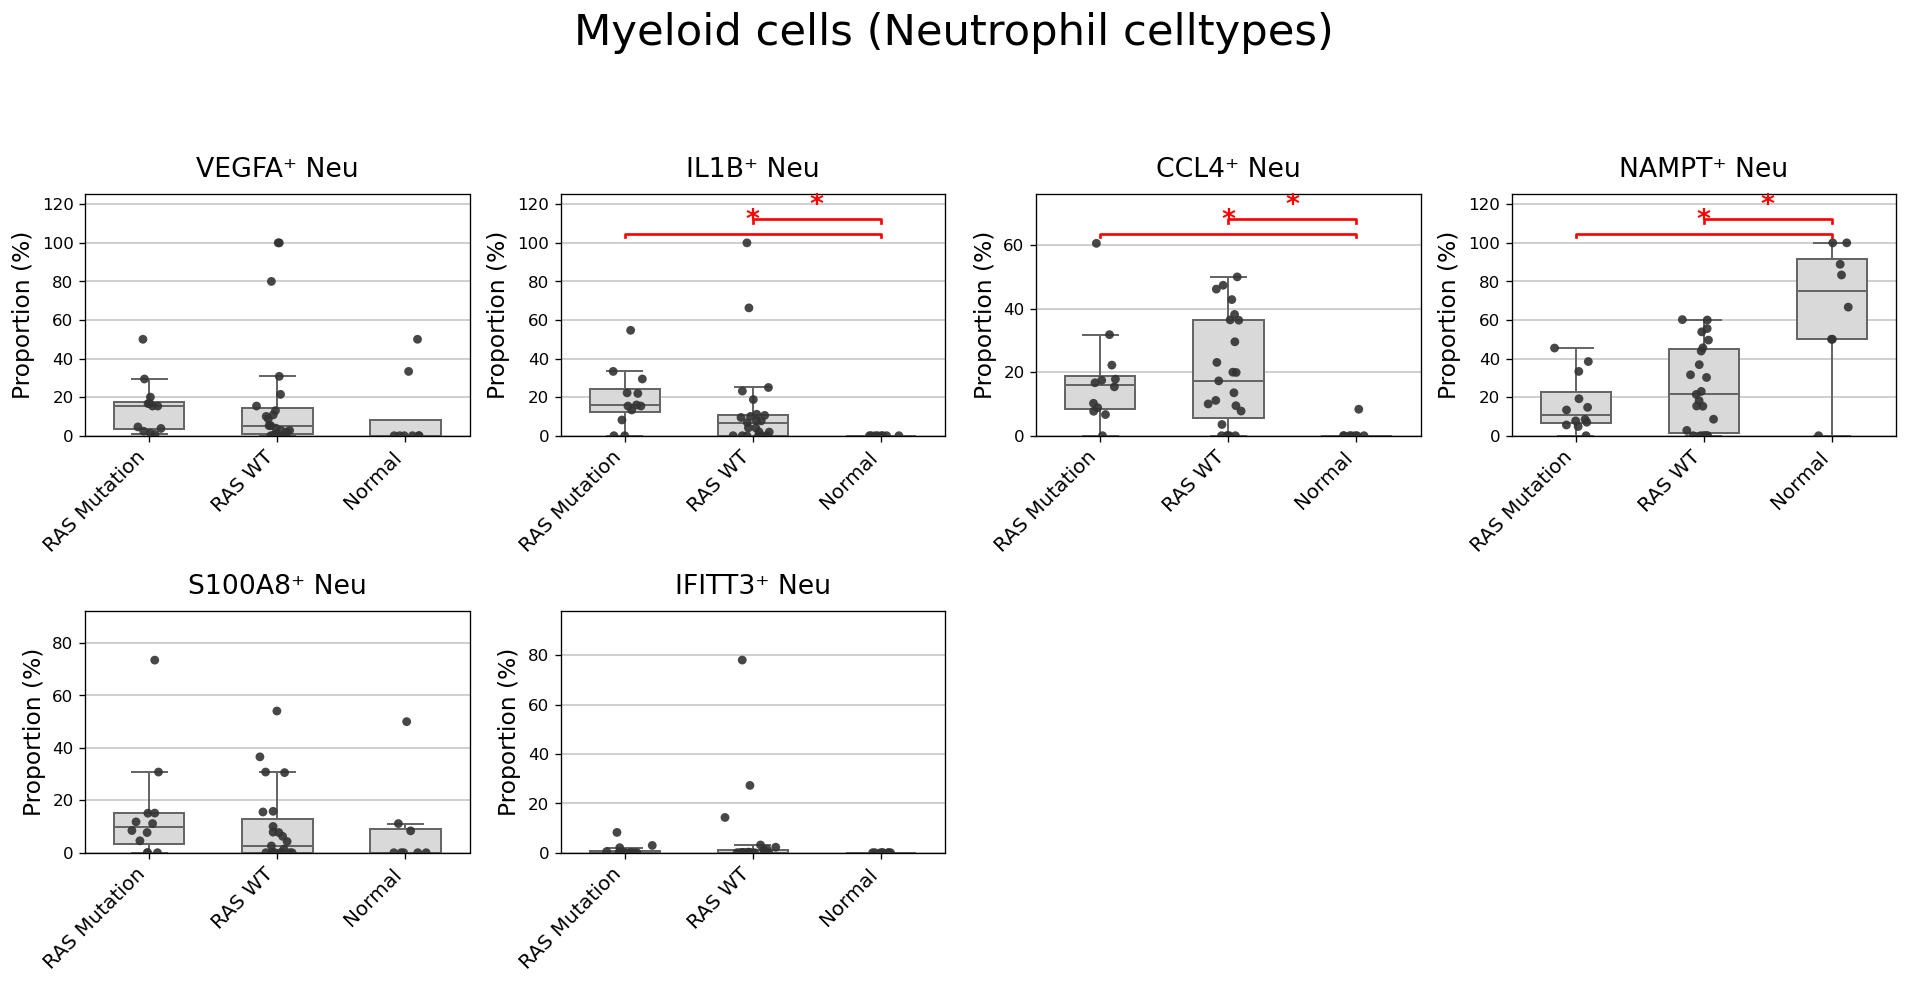

In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

sample_col  = "sample"
group_col   = "RAS_mutation"
subtype_col = "Total celltype"

target_subtypes = [ 'VEGFA⁺ Neu', 'IL1B⁺ Neu','CCL4⁺ Neu','NAMPT⁺ Neu','S100A8⁺ Neu','IFITT3⁺ Neu']

group_order = ["RAS Mutation", "RAS WT", "Normal"]
show_only_sig = True

SUBPLOT_W = 4
SUBPLOT_H = 4
DPI = 120

FS_SUPTITLE = 26
FS_TITLE    = 16
FS_LABEL    = 14
FS_TICK     = 12
FS_STAR     = 16

def bh_adjust(pvals):
    pvals = np.array(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adj, 0, 1)
    return out.tolist()

def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, y, h, text, color="red", lw=1.6, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=color)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom",
            color=color, fontsize=fs, fontweight="bold")

obs = adata2.obs[[sample_col, group_col, subtype_col]].copy()
ct = (
    obs.groupby([sample_col, group_col, subtype_col], observed=True)
       .size()
       .unstack(fill_value=0)
)

ct_target = ct.reindex(columns=target_subtypes, fill_value=0)
denom_all = obs.groupby([sample_col, group_col], observed=True).size()
prop = ct_target.div(denom_all, axis=0) * 100
prop = prop.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

df = (
    prop.reset_index()
        .melt(
            id_vars=[sample_col, group_col],
            var_name="CD8_target_subtype",
            value_name="percent"
        )
)

df["percent"] = df["percent"].astype(float)
group_order = [g for g in group_order if g in df[group_col].unique()]

subtypes = target_subtypes
n_sub = len(subtypes)

ncols = min(4, n_sub)
nrows = math.ceil(n_sub / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(SUBPLOT_W * ncols, SUBPLOT_H * nrows),
    dpi=DPI,
    squeeze=False
)

rng = np.random.default_rng(0)

_global_pvals = []
_global_keys = []
_stats_cache = {}

for idx, subtype in enumerate(subtypes):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]

    d = df[df["CD8_target_subtype"] == subtype].copy()
    groups = [d.loc[d[group_col] == g, "percent"].dropna().values for g in group_order]
    positions = np.arange(1, len(group_order) + 1)

    bp = ax.boxplot(
        groups, positions=positions, widths=0.55,
        showfliers=False, patch_artist=True
    )
    for box in bp["boxes"]:
        box.set_facecolor("#d9d9d9")
        box.set_edgecolor("#666666")
        box.set_linewidth(1.2)
    for k in ["whiskers", "caps", "medians"]:
        for item in bp[k]:
            item.set_color("#666666")
            item.set_linewidth(1.2)

    for i, vals in enumerate(groups, start=1):
        x = rng.normal(loc=i, scale=0.07, size=len(vals))
        ax.scatter(x, vals, s=28, alpha=0.9, color="0.2",
                   edgecolors="none", zorder=3)

    ax.set_title(subtype, fontsize=FS_TITLE, pad=10, loc="center")
    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, rotation=45, ha="right", fontsize=FS_TICK)
    ax.set_ylabel("Proportion (%)", fontsize=FS_LABEL)

    ax.yaxis.grid(True, color="#c7c7c7", linewidth=1.0)
    ax.xaxis.grid(False)

    all_vals = np.concatenate([v for v in groups if len(v) > 0]) if any(len(v)>0 for v in groups) else np.array([0.0])
    y_max = float(np.nanmax(all_vals)) if np.isfinite(np.nanmax(all_vals)) else 0.0
    ax.set_ylim(0, max(1.0, y_max * 1.25 + 0.5))

    pairs = [(a, b) for a in range(len(group_order)) for b in range(a+1, len(group_order))]

    raw_p, ok_mask = [], []
    for a, b in pairs:
        A, B = groups[a], groups[b]
        A = A[np.isfinite(A)]
        B = B[np.isfinite(B)]
        if len(A) < 2 or len(B) < 2:
            raw_p.append(np.nan); ok_mask.append(False)
        else:
            p = stats.mannwhitneyu(A, B, alternative="two-sided").pvalue
            raw_p.append(p); ok_mask.append(True)

    _stats_cache[subtype] = {"ax": ax, "pairs": pairs, "raw_p": raw_p, "ok_mask": ok_mask}
    for pi, p in enumerate(raw_p):
        if np.isfinite(p) and ok_mask[pi]:
            _global_pvals.append(float(p))
            _global_keys.append((subtype, pi))

_global_adj_map = {}
if len(_global_pvals) > 0:
    _global_adj = bh_adjust(_global_pvals)
    _global_adj_map = {k: _global_adj[i] for i, k in enumerate(_global_keys)}

for subtype in subtypes:
    ax = _stats_cache[subtype]["ax"]
    pairs = _stats_cache[subtype]["pairs"]
    raw_p = _stats_cache[subtype]["raw_p"]
    ok_mask = _stats_cache[subtype]["ok_mask"]

    base = ax.get_ylim()[1] * 0.82
    step = ax.get_ylim()[1] * 0.06
    bar_i = 0

    for pi, (a, b) in enumerate(pairs):
        if not ok_mask[pi]:
            continue

        p_adj = _global_adj_map.get((subtype, pi), np.nan)
        star = p_to_star(p_adj)
        if show_only_sig and star == "ns":
            continue

        y = base + bar_i * step
        add_sig_bar(ax, a+1, b+1, y=y, h=step*0.25, text=star, color="red", fs=FS_STAR)
        bar_i += 1

for j in range(n_sub, nrows * ncols):
    rr, cc = divmod(j, ncols)
    fig.delaxes(axes[rr][cc])

fig.suptitle("Myeloid cells (Neutrophil celltypes)", fontsize=FS_SUPTITLE,
             x=0.5, ha="center", y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

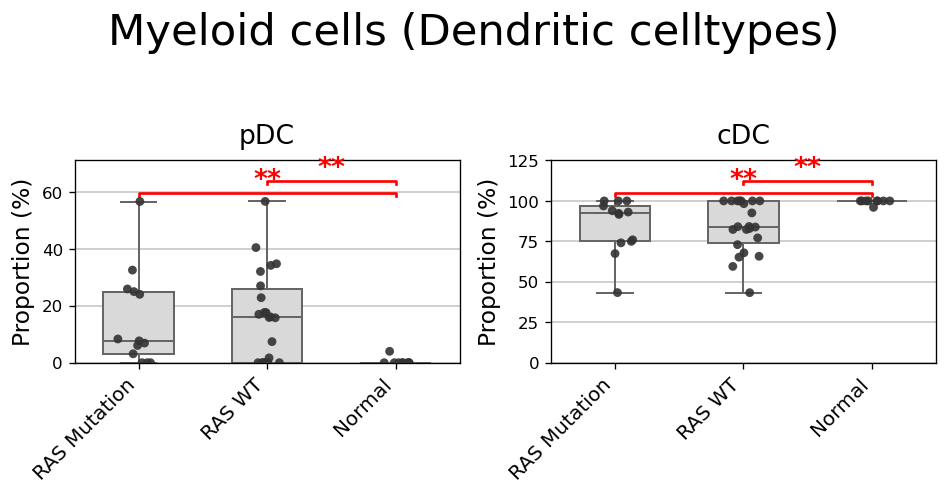

In [189]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

sample_col  = "sample"
group_col   = "RAS_mutation"
subtype_col = "Total celltype"

target_subtypes = ['pDC','cDC']

group_order = ["RAS Mutation", "RAS WT", "Normal"]
show_only_sig = True

SUBPLOT_W = 4
SUBPLOT_H = 4
DPI = 120

FS_SUPTITLE = 26
FS_TITLE    = 16
FS_LABEL    = 14
FS_TICK     = 12
FS_STAR     = 16

def bh_adjust(pvals):
    pvals = np.array(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adj, 0, 1)
    return out.tolist()

def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, y, h, text, color="red", lw=1.6, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=color)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom",
            color=color, fontsize=fs, fontweight="bold")

obs = adata3.obs[[sample_col, group_col, subtype_col]].copy()
ct = (
    obs.groupby([sample_col, group_col, subtype_col], observed=True)
       .size()
       .unstack(fill_value=0)
)

ct_target = ct.reindex(columns=target_subtypes, fill_value=0)
denom_all = obs.groupby([sample_col, group_col], observed=True).size()
prop = ct_target.div(denom_all, axis=0) * 100
prop = prop.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

df = (
    prop.reset_index()
        .melt(
            id_vars=[sample_col, group_col],
            var_name="CD8_target_subtype",
            value_name="percent"
        )
)

df["percent"] = df["percent"].astype(float)
group_order = [g for g in group_order if g in df[group_col].unique()]

subtypes = target_subtypes
n_sub = len(subtypes)

ncols = min(4, n_sub)
nrows = math.ceil(n_sub / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(SUBPLOT_W * ncols, SUBPLOT_H * nrows),
    dpi=DPI,
    squeeze=False
)

rng = np.random.default_rng(0)

_global_pvals = []
_global_keys = []
_stats_cache = {}

for idx, subtype in enumerate(subtypes):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]

    d = df[df["CD8_target_subtype"] == subtype].copy()
    groups = [d.loc[d[group_col] == g, "percent"].dropna().values for g in group_order]
    positions = np.arange(1, len(group_order) + 1)

    bp = ax.boxplot(
        groups, positions=positions, widths=0.55,
        showfliers=False, patch_artist=True
    )
    for box in bp["boxes"]:
        box.set_facecolor("#d9d9d9")
        box.set_edgecolor("#666666")
        box.set_linewidth(1.2)
    for k in ["whiskers", "caps", "medians"]:
        for item in bp[k]:
            item.set_color("#666666")
            item.set_linewidth(1.2)

    for i, vals in enumerate(groups, start=1):
        x = rng.normal(loc=i, scale=0.07, size=len(vals))
        ax.scatter(x, vals, s=28, alpha=0.9, color="0.2",
                   edgecolors="none", zorder=3)

    ax.set_title(subtype, fontsize=FS_TITLE, pad=10, loc="center")
    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, rotation=45, ha="right", fontsize=FS_TICK)
    ax.set_ylabel("Proportion (%)", fontsize=FS_LABEL)

    ax.yaxis.grid(True, color="#c7c7c7", linewidth=1.0)
    ax.xaxis.grid(False)

    all_vals = np.concatenate([v for v in groups if len(v) > 0]) if any(len(v)>0 for v in groups) else np.array([0.0])
    y_max = float(np.nanmax(all_vals)) if np.isfinite(np.nanmax(all_vals)) else 0.0
    ax.set_ylim(0, max(1.0, y_max * 1.25 + 0.5))

    pairs = [(a, b) for a in range(len(group_order)) for b in range(a+1, len(group_order))]

    raw_p, ok_mask = [], []
    for a, b in pairs:
        A, B = groups[a], groups[b]
        A = A[np.isfinite(A)]
        B = B[np.isfinite(B)]
        if len(A) < 2 or len(B) < 2:
            raw_p.append(np.nan); ok_mask.append(False)
        else:
            p = stats.mannwhitneyu(A, B, alternative="two-sided").pvalue
            raw_p.append(p); ok_mask.append(True)

    _stats_cache[subtype] = {"ax": ax, "pairs": pairs, "raw_p": raw_p, "ok_mask": ok_mask}
    for pi, p in enumerate(raw_p):
        if np.isfinite(p) and ok_mask[pi]:
            _global_pvals.append(float(p))
            _global_keys.append((subtype, pi))

_global_adj_map = {}
if len(_global_pvals) > 0:
    _global_adj = bh_adjust(_global_pvals)
    _global_adj_map = {k: _global_adj[i] for i, k in enumerate(_global_keys)}

for subtype in subtypes:
    ax = _stats_cache[subtype]["ax"]
    pairs = _stats_cache[subtype]["pairs"]
    raw_p = _stats_cache[subtype]["raw_p"]
    ok_mask = _stats_cache[subtype]["ok_mask"]

    base = ax.get_ylim()[1] * 0.82
    step = ax.get_ylim()[1] * 0.06
    bar_i = 0

    for pi, (a, b) in enumerate(pairs):
        if not ok_mask[pi]:
            continue

        p_adj = _global_adj_map.get((subtype, pi), np.nan)
        star = p_to_star(p_adj)
        if show_only_sig and star == "ns":
            continue

        y = base + bar_i * step
        add_sig_bar(ax, a+1, b+1, y=y, h=step*0.25, text=star, color="red", fs=FS_STAR)
        bar_i += 1

for j in range(n_sub, nrows * ncols):
    rr, cc = divmod(j, ncols)
    fig.delaxes(axes[rr][cc])

fig.suptitle("Myeloid cells (Dendritic celltypes)", fontsize=FS_SUPTITLE,
             x=0.5, ha="center", y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()